# ComplexHeatmap simple quickstart method

In [1]:
# quick-start guide for plotting a DGE heatmap from a DGE table and a relative expression table via ComplexHeatmap
# full user-guide can be found here: https://jokergoo.github.io/ComplexHeatmap-reference/book/

library(ComplexHeatmap)
library(circlize)

Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [82]:
# import normalized counts table (or whatever relative expression data)
# e.g. where the first column is gene name and the remaining columns are relative expression values for each sample in the experiment

norm.counts <- read.csv("250315_Heatmap.csv")
genes <- norm.counts$Gene # save gene names
norm.counts$Gene <- NULL
Annotations <- norm.counts$Annotation # save annotations
norm.counts$Annotation <- NULL
norm.counts <- as.matrix(norm.counts) # convert to numeric matrix
rownames(norm.counts) <- genes # make gene names the row names
rm(genes)
head(norm.counts)
tail(norm.counts)

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
Il1f6,9.455004,5.321786,1.140681,0.000000,5062.0949,2446.12855,5457.74263,2031.94660
Il1f9,39.592831,4.434822,9.125446,0.000000,456.4710,445.32084,1908.38035,324.16269
Cxcl2,2.954689,9.756608,26.235658,1.280278,348.1694,290.60844,1291.95661,175.52224
Cxcl5,65.003155,24.835001,161.976669,134.429198,1622.9188,728.61180,4857.26897,1288.74434
Il1a,76.821911,77.165897,35.361104,133.148920,536.6944,501.76996,2118.54614,528.14799
Il24,1.181876,8.869643,0.000000,2.560556,56.9586,10.45354,85.37985,22.13794


,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
Foxj1,404.79238,368.9772,204.1819,272.6992,559.15691,577.03545,822.8365633,308.34987
Wnt9a,7386.13127,5655.2846,7523.9303,5701.0783,3833.07279,3605.42623,3276.3344120,3089.82386
Ttr,782.99255,1637.3362,2663.4896,2284.0161,554.34351,268.65600,143.5507345,388.99523
Prss29,813.13038,516.2132,871.4801,1077.9941,204.56960,130.66926,0.9382401,102.78329
Spink1,3144.97085,11830.3303,9427.7265,10612.2250,1162.43668,330.33189,78.8121680,776.40917
Prss28,72.09441,204.0018,302.2804,596.6096,25.67148,19.86173,1.8764802,12.65025


In [83]:
# center and scale the rlog counts table (i.e. produce Z-score expression values across the samples, for each gene)
# note: t() will transpose the matrix
# so, here, we are transposing the matrix, center and scaling with scale(), then transposing back
# the reason for this is that scale() by default wants to scale each column vector (samples here), but we want to scale gene-wise

scaled.norm.counts <- t(scale(t(norm.counts)))

head(scaled.norm.counts)


,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
Il1f6,-0.8084016,-0.8101910,-0.8120011,-0.8124950,1.37904526,0.24651109,1.550334,0.06719869
Il1f9,-0.5589277,-0.6136892,-0.6063832,-0.6205968,0.09039428,0.07302700,2.351862,-0.11568678
Cxcl2,-0.6086525,-0.5930507,-0.5552524,-0.6124931,0.18317423,0.05114528,2.347960,-0.21283047
Cxcl5,-0.6413187,-0.6659588,-0.5818326,-0.5987309,0.31434729,-0.23424388,2.298382,0.10935597
Il1a,-0.6149226,-0.6144239,-0.6750336,-0.5332582,0.05181296,0.00117860,2.345225,0.03942218
Il24,-0.7129975,-0.4667646,-0.7508520,-0.6688395,1.07348495,-0.41603368,1.983794,-0.04179200


In [84]:
# Export normalized counts file if desired

write.csv(scaled.norm.counts,file="scaled.norm.counts.csv") # keeps the rownames

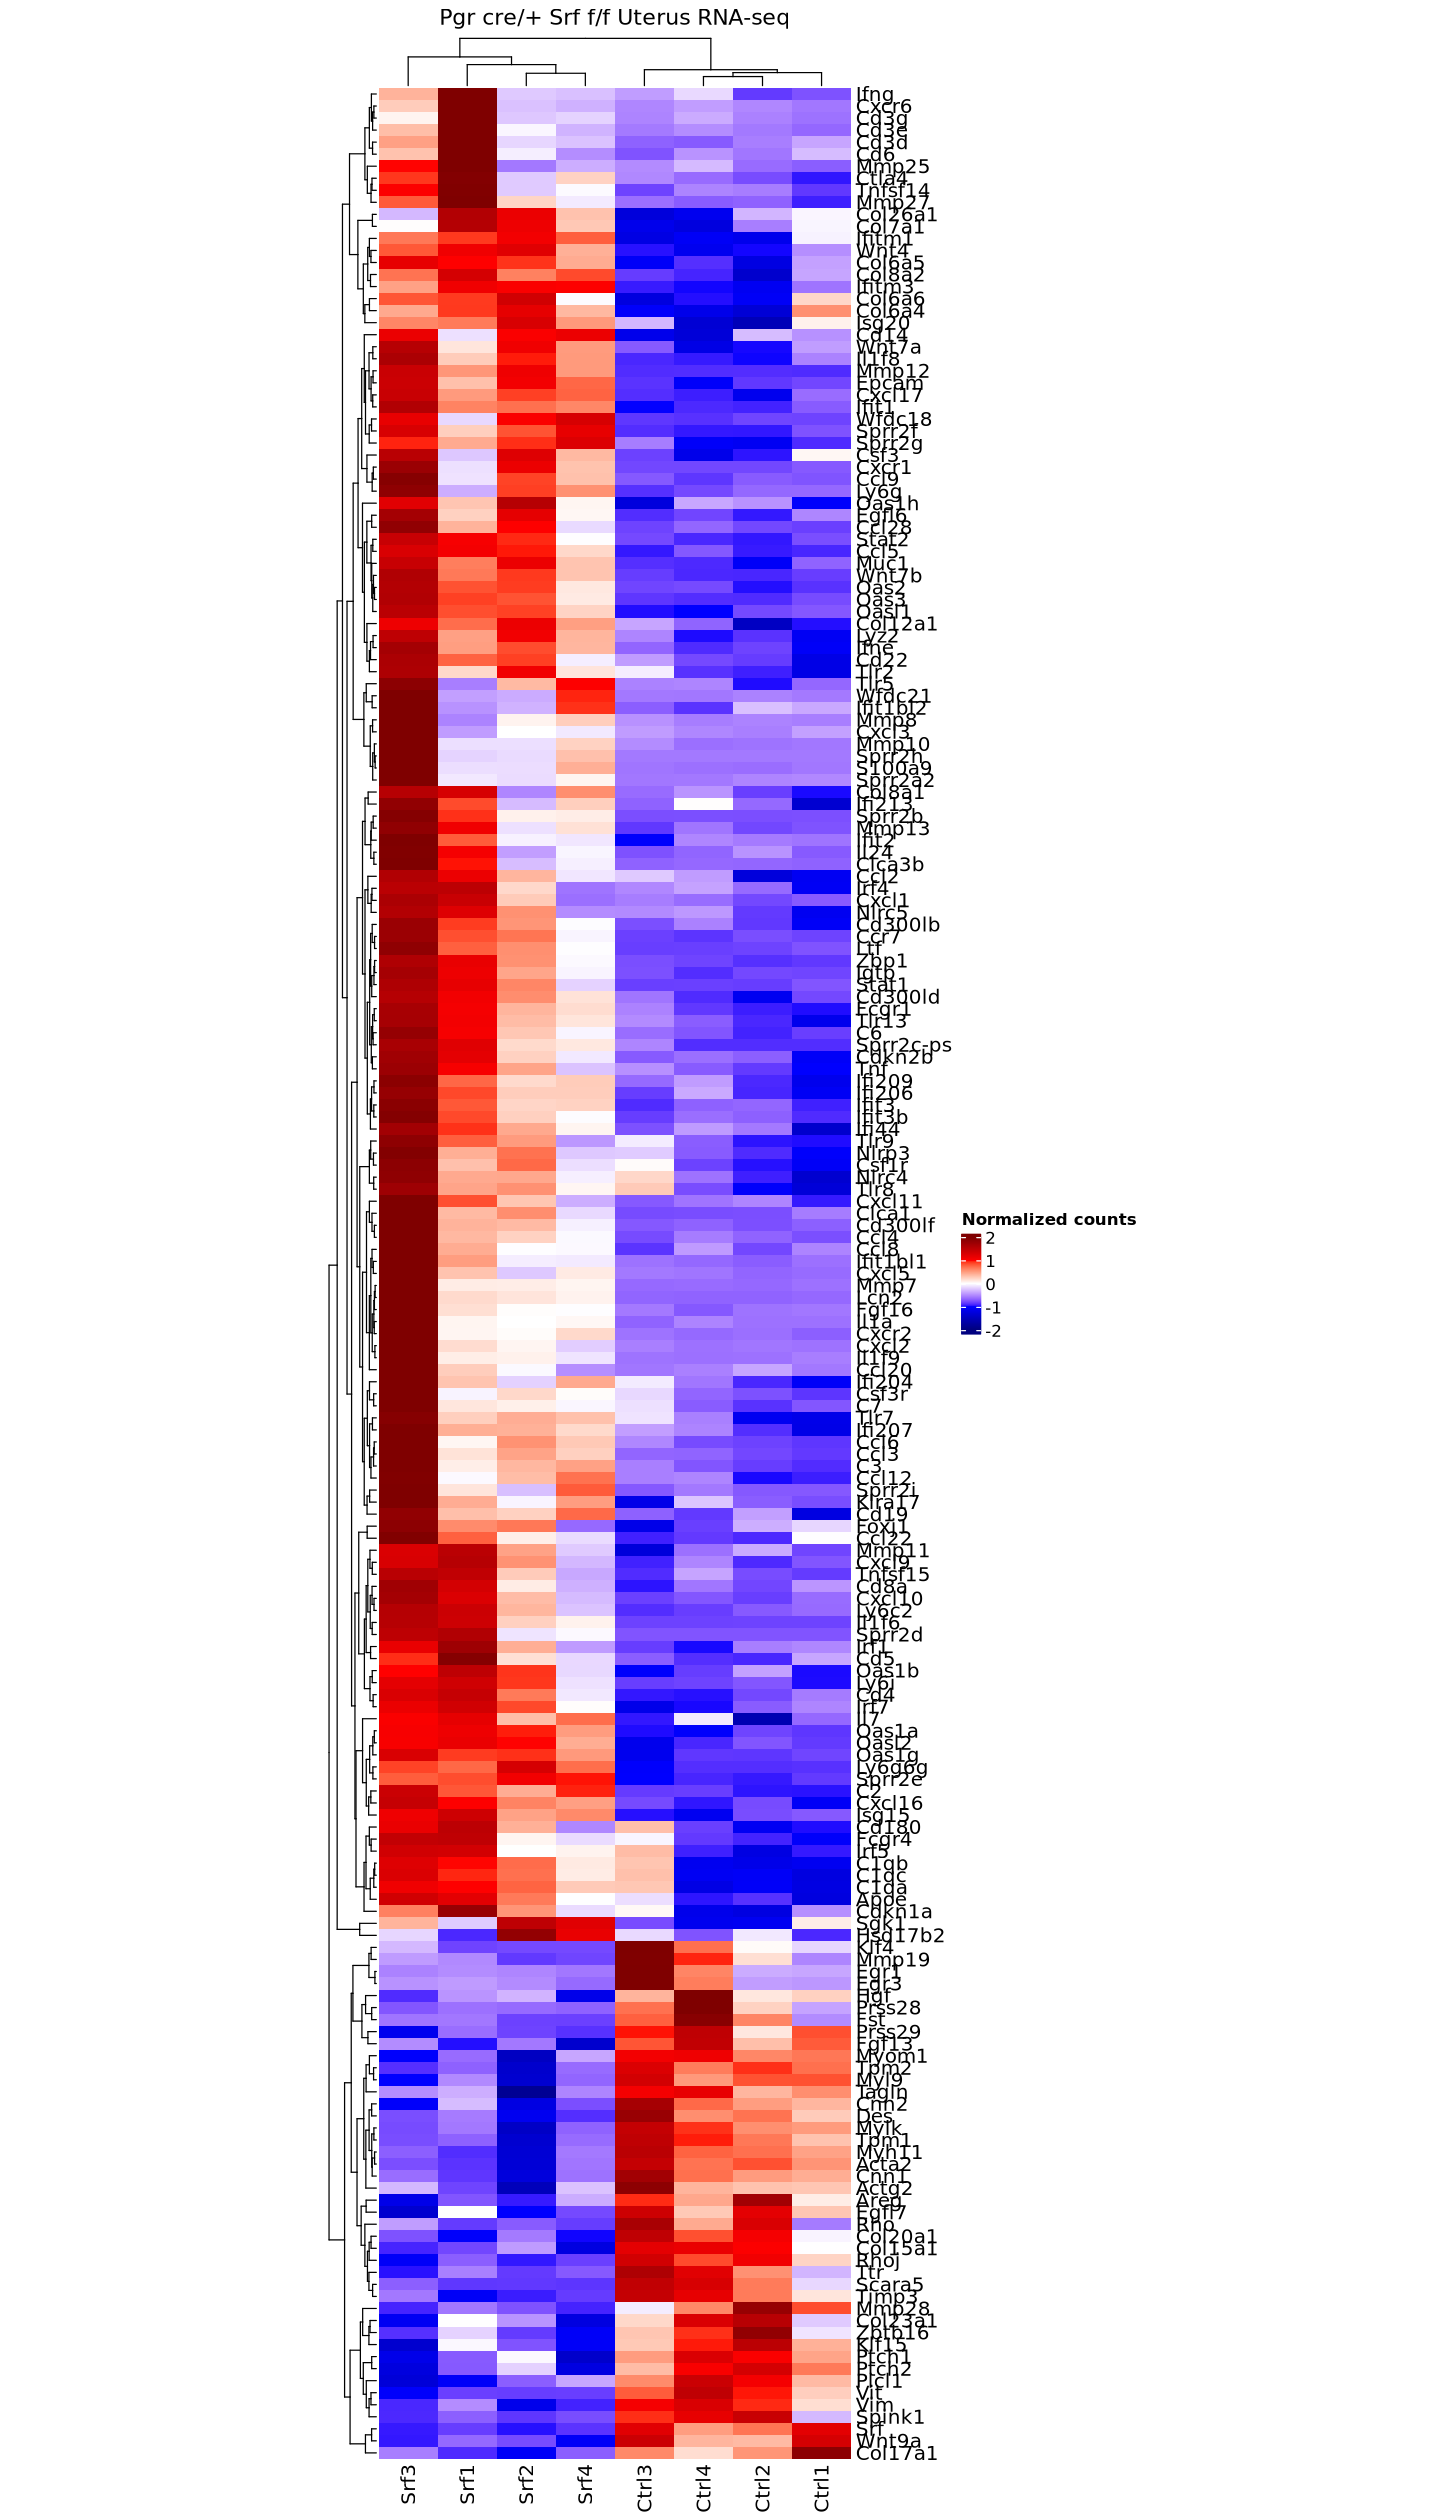

In [85]:
set.seed(1) # set seed for reproducibility
Heatmap(scaled.norm.counts, 
        clustering_distance_rows = "euclidean", # this is the default method
        width = unit(10, "cm"), # width of the heatmap
        name="Normalized counts", # name of the legend i.e. colorbar
        col = colorRamp2(c(-2, -1, 0, 1, 2), 
                         c("#00007F", "blue", "white", "red", "#7F0000")), # this is a custom color scale
        show_row_names=TRUE,
        show_column_names=TRUE,
        column_title="Pgr cre/+ Srf f/f Uterus RNA-seq", # set your own title
        cluster_columns=TRUE)

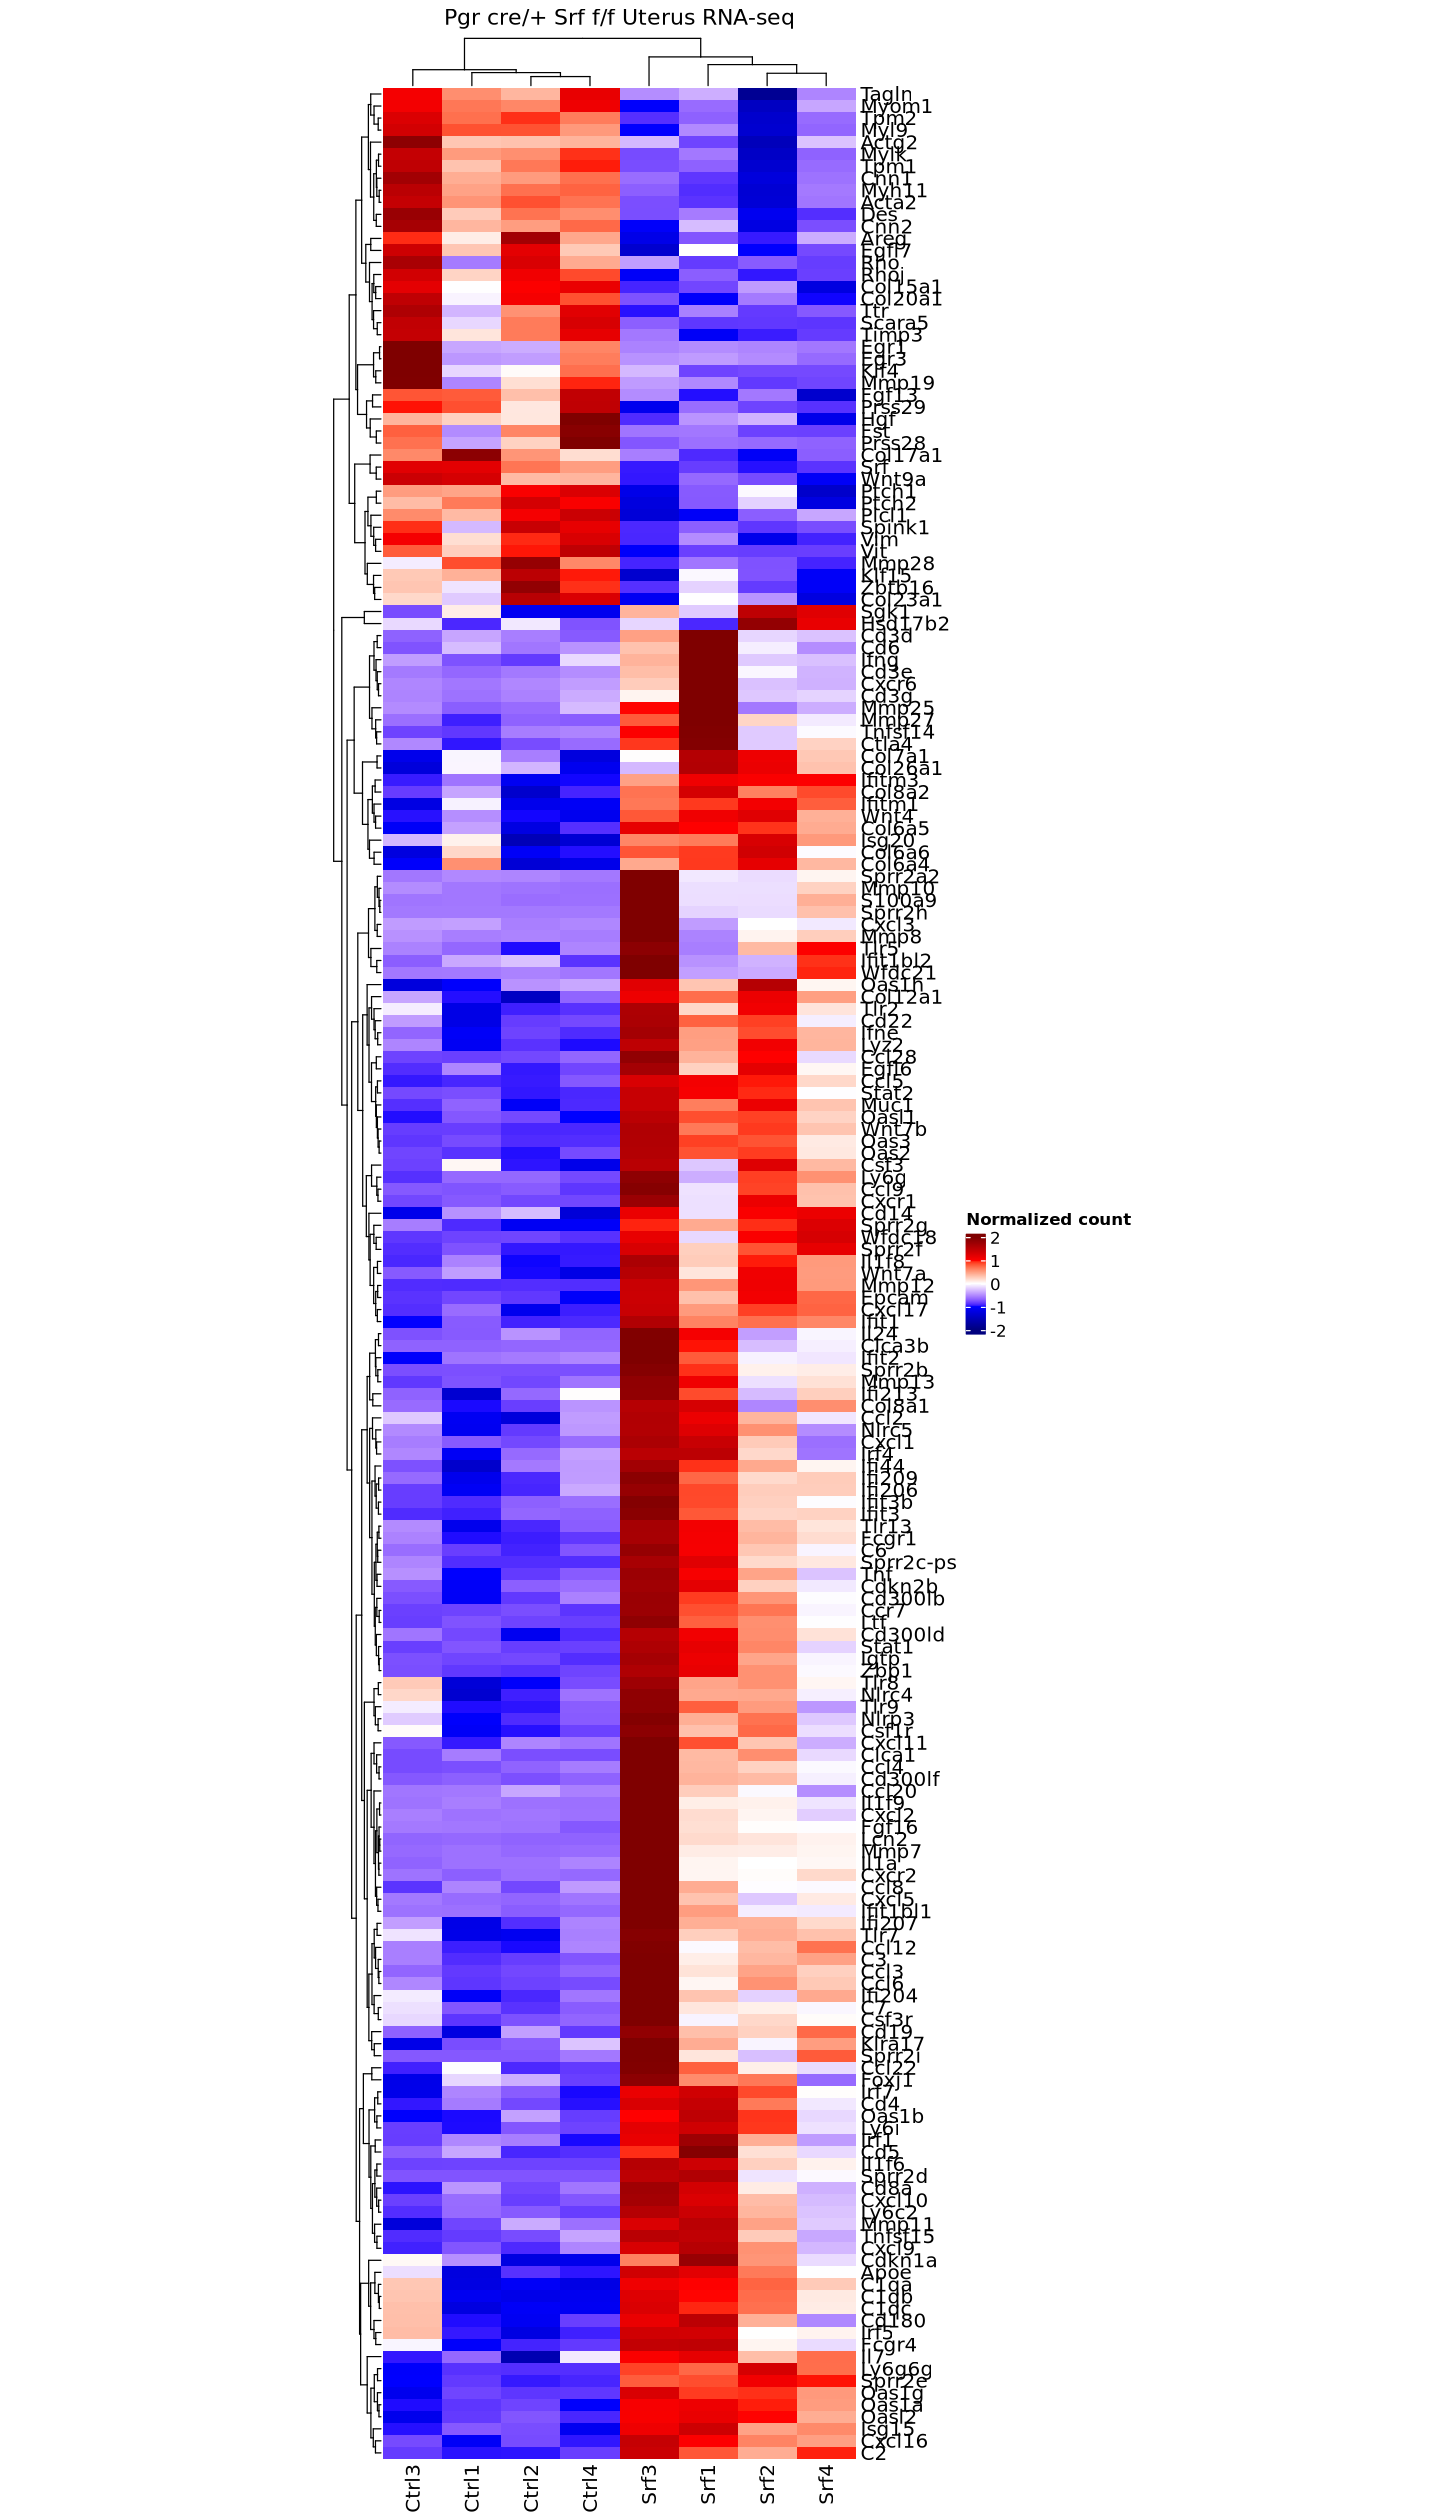

In [86]:
#Cluster but do not reorder dendrograms
set.seed(1) # set seed for reproducibility
Heatmap(scaled.norm.counts, 
        clustering_distance_rows = "euclidean", # this is the default method
        width = unit(10, "cm"), # width of the heatmap
        name="Normalized count", # name of the legend i.e. colorbar
        col = colorRamp2(c(-2, -1, 0, 1, 2), 
                         c("#00007F", "blue", "white", "red", "#7F0000")), # this is a custom color scale
        show_row_names=TRUE,
        show_column_names=TRUE,
        column_title="Pgr cre/+ Srf f/f Uterus RNA-seq", # set your own title
        cluster_columns=TRUE,
        row_dend_reorder = FALSE,
        column_dend_reorder = FALSE)


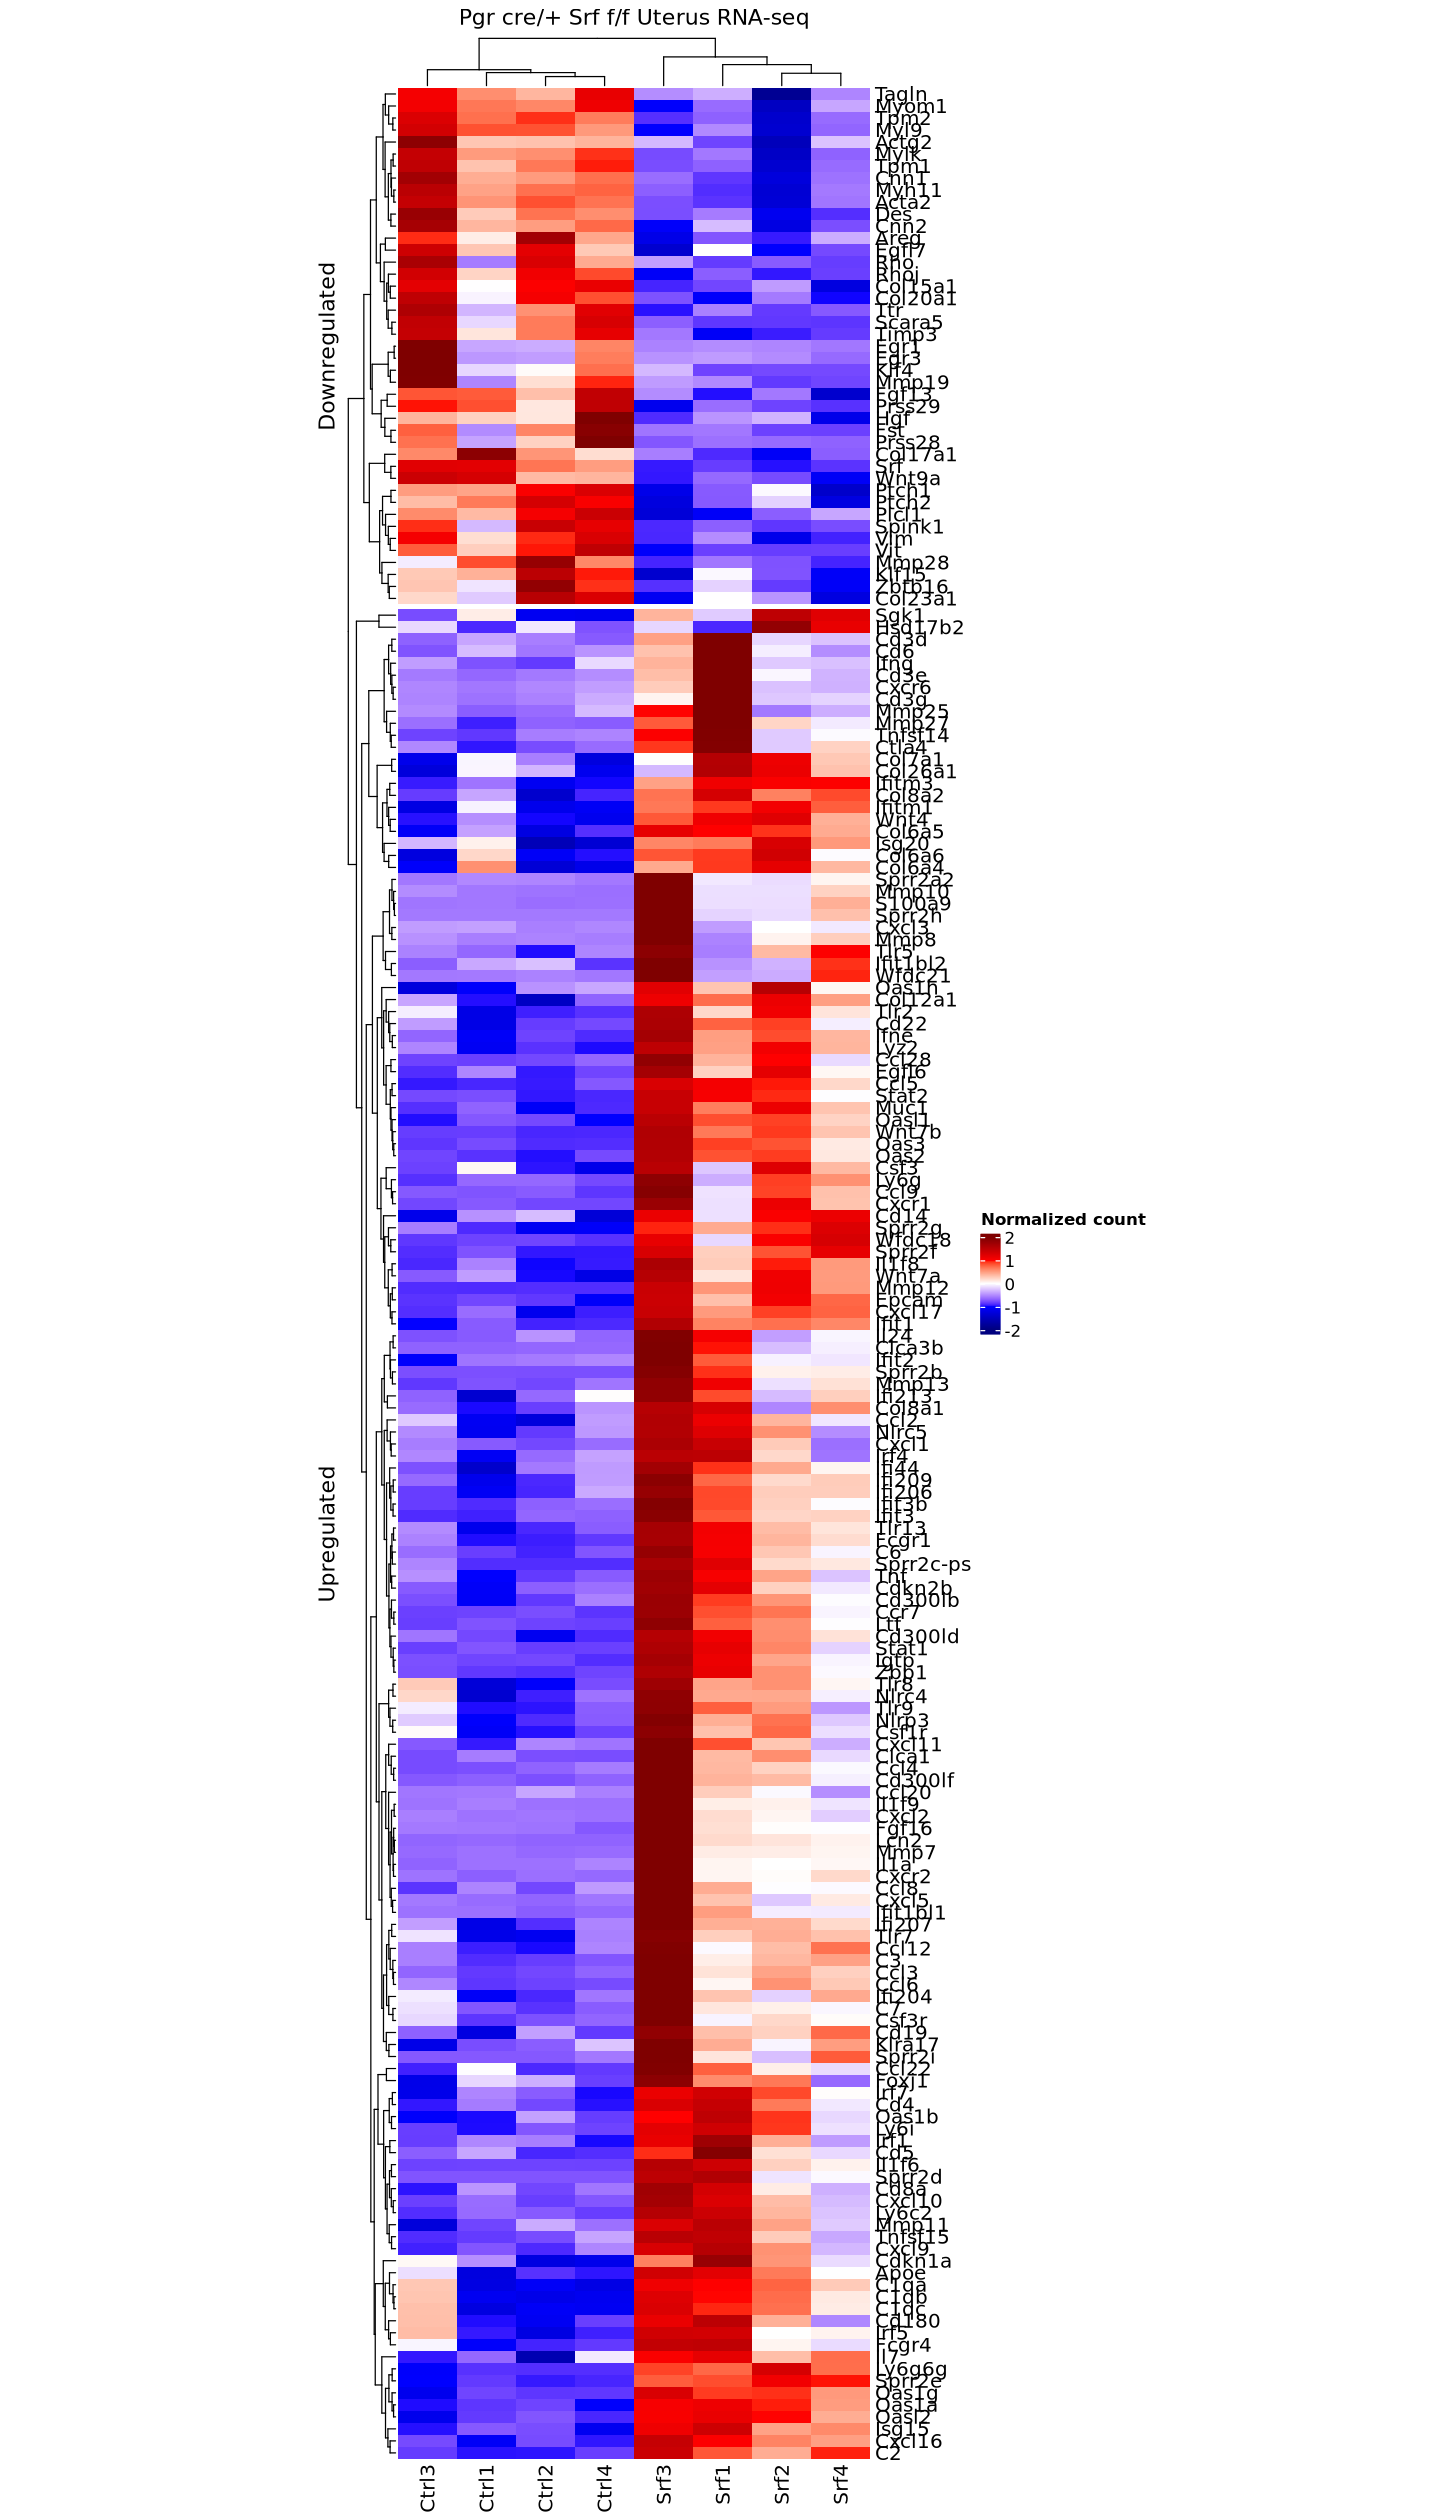

In [87]:
#Cluster but do not reorder dendrograms AND split rows (and name them)
set.seed(1) # set seed for reproducibility
Heatmap(scaled.norm.counts, 
        clustering_distance_rows = "euclidean", # this is the default method
        width = unit(10, "cm"), # width of the heatmap
        name="Normalized count", # name of the legend i.e. colorbar
        col = colorRamp2(c(-2, -1, 0, 1, 2), 
                         c("#00007F", "blue", "white", "red", "#7F0000")), # this is a custom color scale
        show_row_names=TRUE,
        show_column_names=TRUE,
        column_title="Pgr cre/+ Srf f/f Uterus RNA-seq", # set your own title
        row_split = 2, # splits rows into the number indicated based on dendrogram
        row_title = c("Downregulated", "Upregulated"), # name the two sections we split it into
        cluster_columns=TRUE,
        row_dend_reorder = FALSE,
        column_dend_reorder = FALSE)


Warning message in order(as.numeric(gsub("row", "", rownames(scaled.norm.counts)))):
“NAs introduced by coercion”
Warning message in order(as.numeric(gsub("column", "", colnames(scaled.norm.counts)))):
“NAs introduced by coercion”


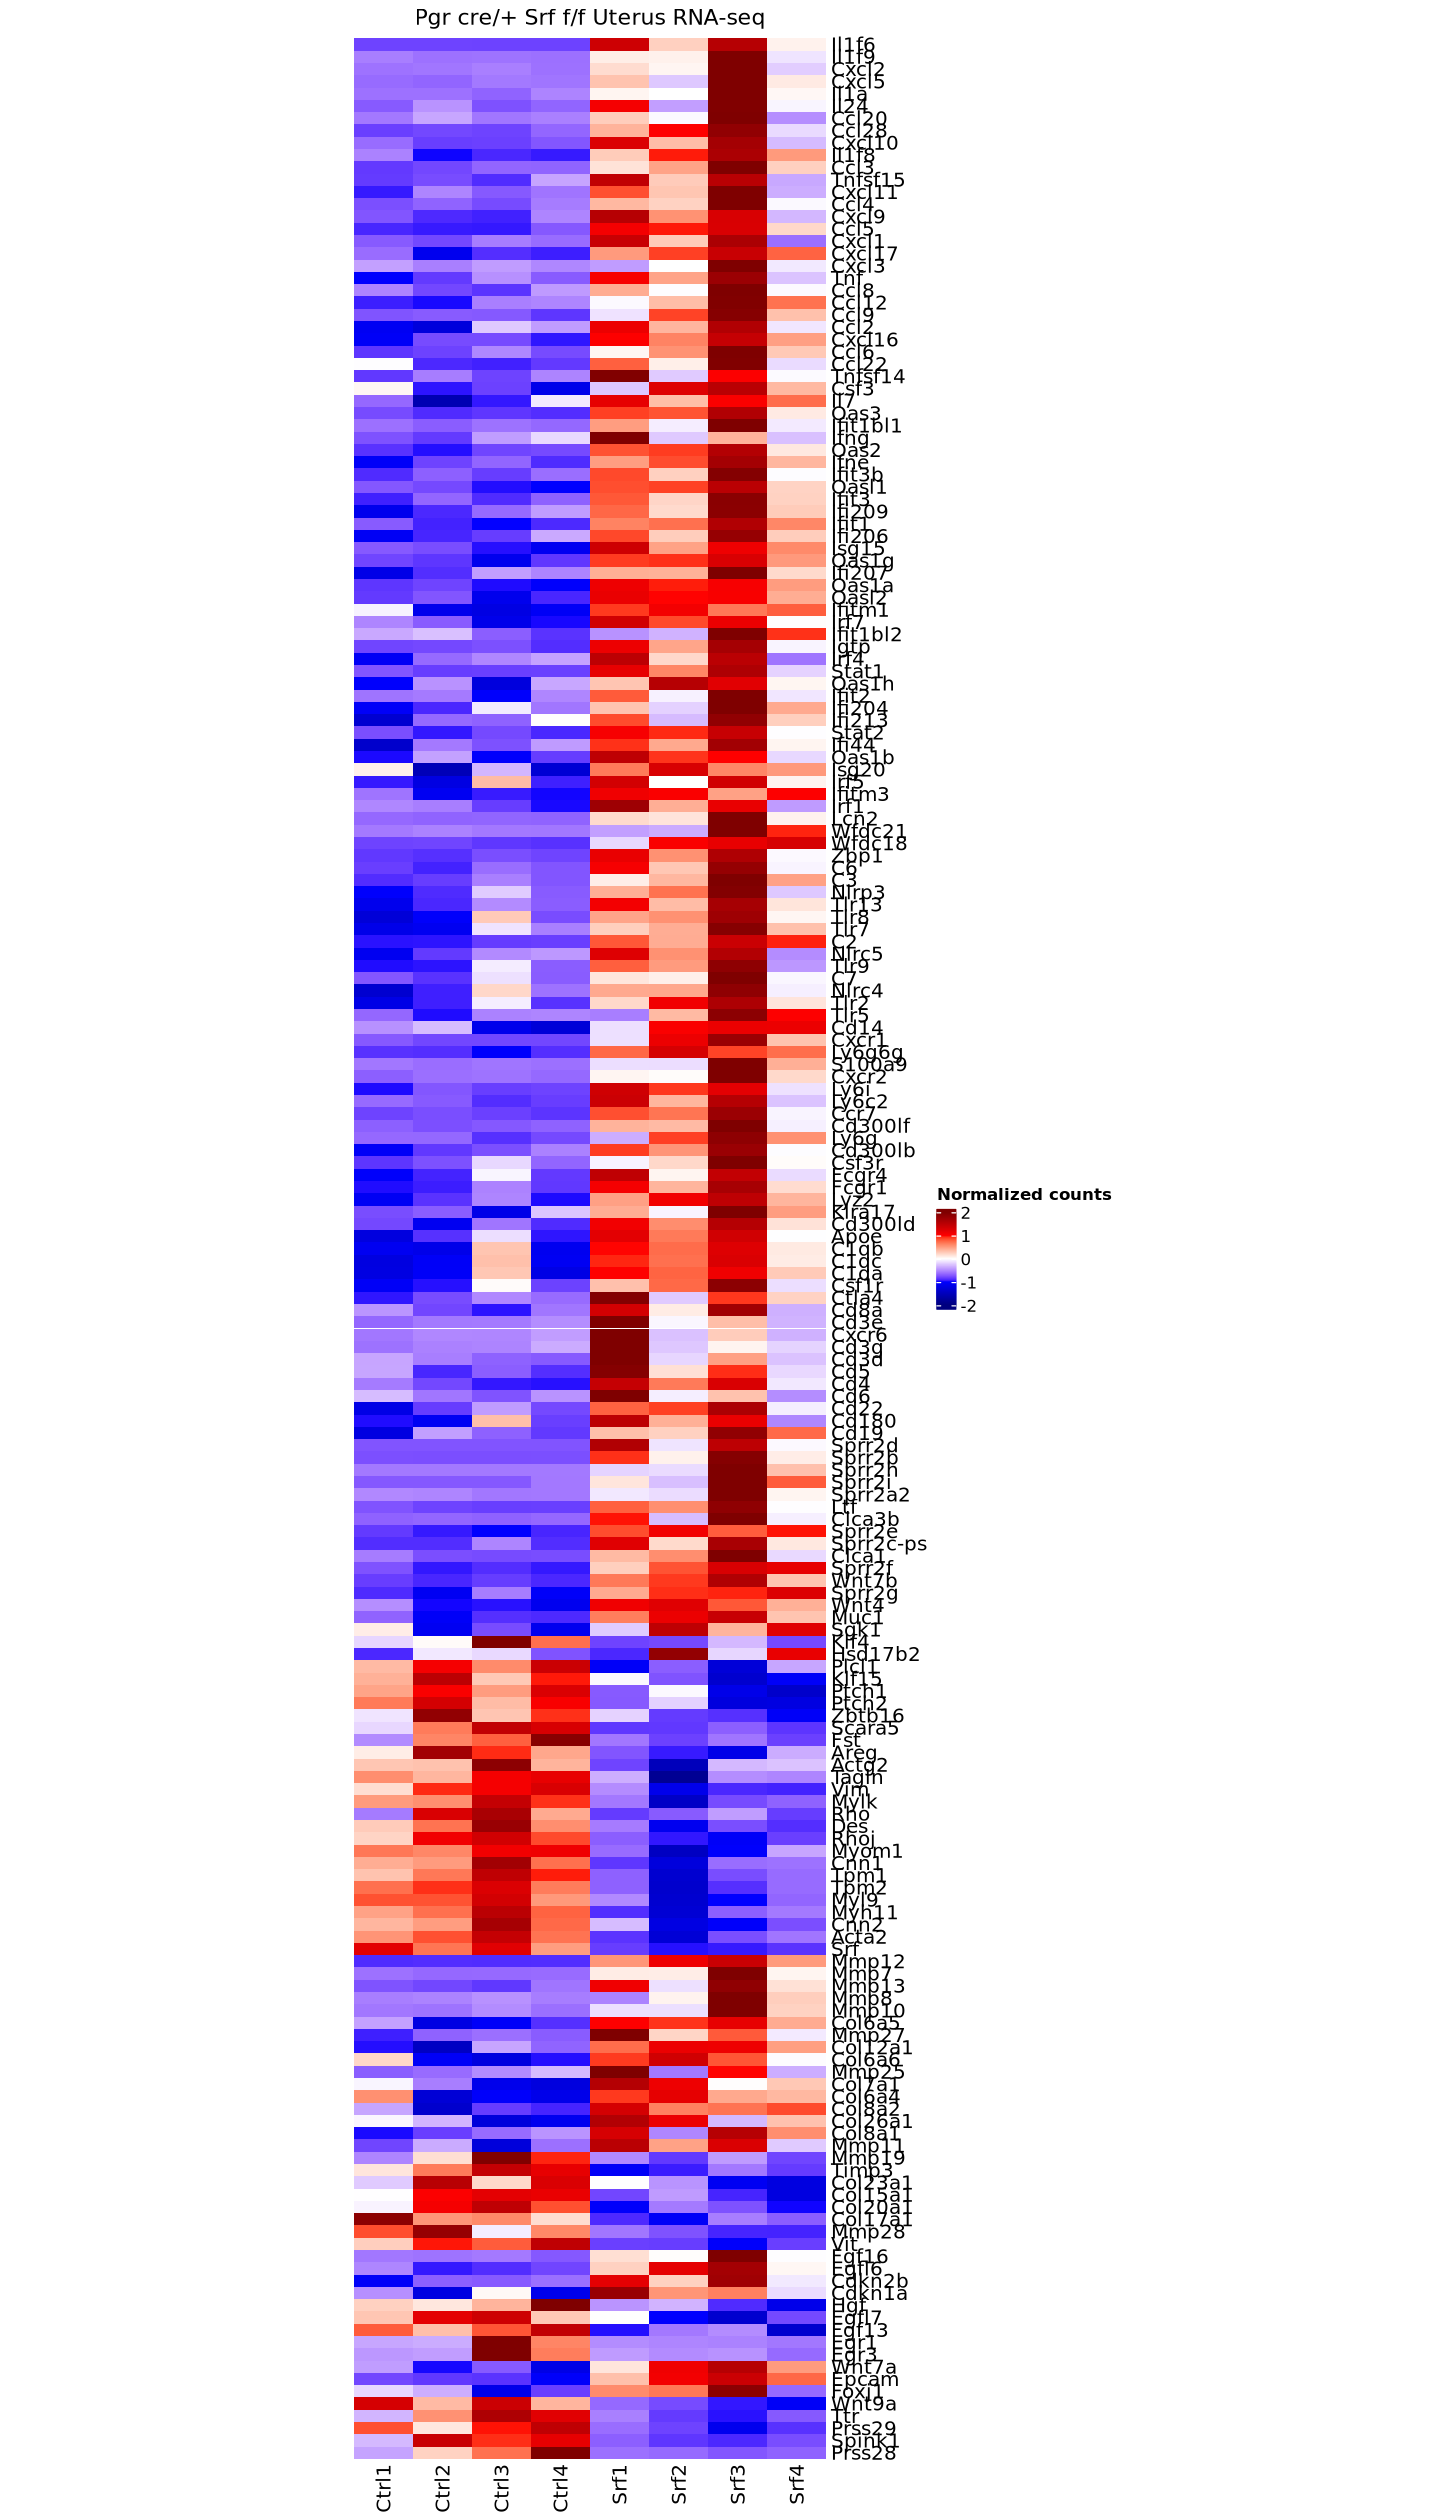

In [88]:
#Stop clustering rows and columns - keep original order 
set.seed(1) # set seed for reproducibility
Heatmap(scaled.norm.counts, 
        width = unit(10, "cm"), # width of the heatmap
        name="Normalized counts", # name of the legend i.e. colorbar
        col = colorRamp2(c(-2, -1, 0, 1, 2), 
                         c("#00007F", "blue", "white", "red", "#7F0000")), # this is a custom color scale
        show_row_names=TRUE,
        show_column_names=TRUE,
        column_title="Pgr cre/+ Srf f/f Uterus RNA-seq", # set your own title
        row_order = order(as.numeric(gsub("row", "", rownames(scaled.norm.counts)))), # orders rows by table order rather than clustering
        column_order = order(as.numeric(gsub("column", "", colnames(scaled.norm.counts))))) #orders columns by table order rather than clustering

Warning message in order(as.numeric(gsub("row", "", rownames(scaled.norm.counts)))):
“NAs introduced by coercion”
Warning message in order(as.numeric(gsub("column", "", colnames(scaled.norm.counts)))):
“NAs introduced by coercion”


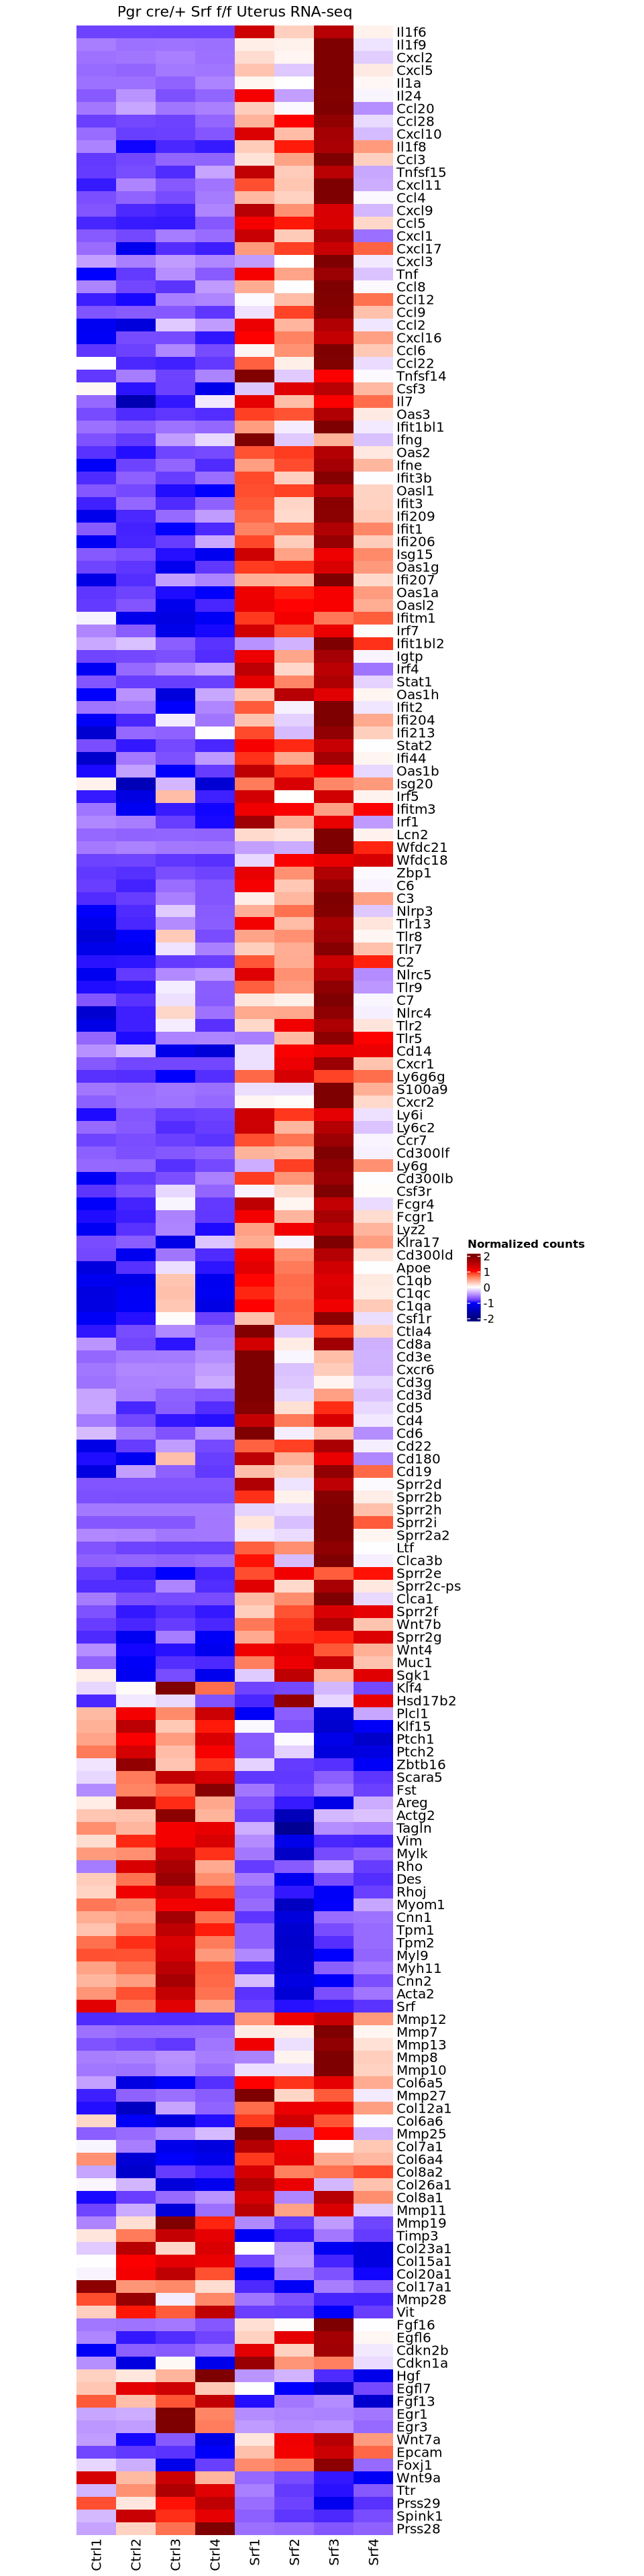

In [89]:
# Adjust plot size
saved <- options(repr.plot.width = 8, repr.plot.height = 32) # Make the plots bigger from here on out, save old options

#Stop clustering rows and columns
set.seed(1) # set seed for reproducibility
Heatmap(scaled.norm.counts, 
        width = unit(10, "cm"), # width of the heatmap
        name="Normalized counts", # name of the legend i.e. colorbar
        col = colorRamp2(c(-2, -1, 0, 1, 2), 
                         c("#00007F", "blue", "white", "red", "#7F0000")), # this is a custom color scale
        show_row_names=TRUE,
        show_column_names=TRUE,
        column_title="Pgr cre/+ Srf f/f Uterus RNA-seq", # set your own title
        row_order = order(as.numeric(gsub("row", "", rownames(scaled.norm.counts)))), # orders rows by table order rather than clustering
        column_order = order(as.numeric(gsub("column", "", colnames(scaled.norm.counts))))) #orders columns by table order rather than clustering

options(saved) # restore old settings

Warning message in order(as.numeric(gsub("row", "", rownames(scaled.norm.counts)))):
“NAs introduced by coercion”
Warning message in order(as.numeric(gsub("column", "", colnames(scaled.norm.counts)))):
“NAs introduced by coercion”


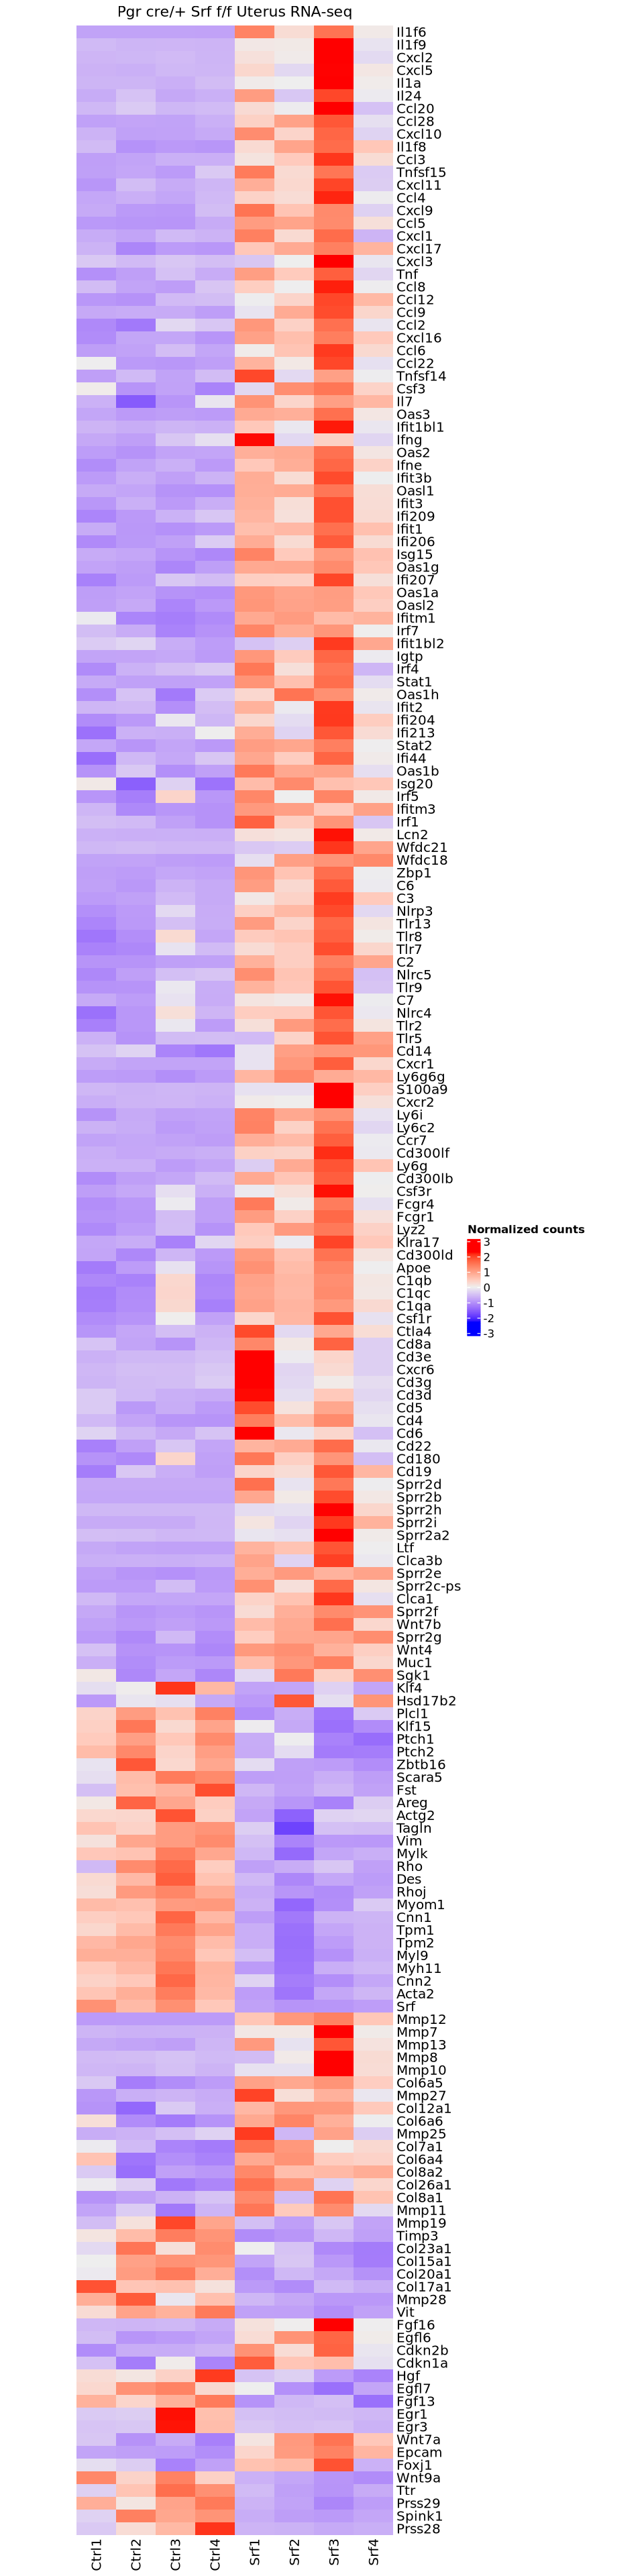

In [90]:
saved <- options(repr.plot.width = 8, repr.plot.height = 32) # Make the plots bigger from here on out, save old options

# Change to default color scheme

# Stop clustering rows and columns
set.seed(1) # set seed for reproducibility
Heatmap(scaled.norm.counts, 
        width = unit(10, "cm"), # width of the heatmap
        name="Normalized counts", # name of the legend i.e. colorbar
        show_row_names=TRUE,
        show_column_names=TRUE,
        column_title="Pgr cre/+ Srf f/f Uterus RNA-seq", # set your own title
        row_order = order(as.numeric(gsub("row", "", rownames(scaled.norm.counts)))), # orders rows by table order rather than clustering
        column_order = order(as.numeric(gsub("column", "", colnames(scaled.norm.counts))))) #orders columns by table order rather than clustering

options(saved) # restore old settings

In [91]:
# FYI: to add back annotations
scaled.norm.counts.annotated <- cbind(scaled.norm.counts, Annotations)
head(scaled.norm.counts.annotated)

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4,Annotations
Il1f6,-0.80840158958881,-0.810190989955401,-0.812001122018152,-0.812494958628231,1.379045256897,0.246511091413274,1.5503336245639,0.0671986873164281,Proinflammatory cytokines
Il1f9,-0.558927722584562,-0.613689211697005,-0.606383178568868,-0.62059681090811,0.0903942807345168,0.0730269957584917,2.35186243039889,-0.115686783133355,Proinflammatory cytokines
Cxcl2,-0.608652459030258,-0.593050748065934,-0.555252387946937,-0.612493091990742,0.183174226845717,0.0511452779818371,2.34795965573806,-0.212830473531744,Proinflammatory cytokines
Cxcl5,-0.641318657848422,-0.665958846729809,-0.581832586410288,-0.598730920190344,0.314347285810394,-0.234243884477741,2.29838164352103,0.109355966325176,Proinflammatory cytokines
Il1a,-0.614922631331865,-0.614423911282897,-0.675033636482045,-0.533258202330807,0.0518129581111455,0.00117859986772408,2.34522464035727,0.0394221830914739,Proinflammatory cytokines
Il24,-0.712997490513881,-0.466764614432783,-0.750851992085824,-0.668839485085519,1.0734849507028,-0.416033680257365,1.9837943110859,-0.0417919994133228,Proinflammatory cytokines


# Alternative ComplexHeatmap method using draw function to add annotations

In [16]:
# Following: https://www.biostars.org/p/286187/#286507
# Load one more package
library(cluster)

In [92]:
# Load and view data
df <- read.csv("250315_Heatmap.csv")
head(df)

,Annotation,Gene,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Proinflammatory cytokines,Il1f6,9.455004,5.321786,1.140681,0.000000,5062.0949,2446.12855,5457.74263,2031.94660
2,Proinflammatory cytokines,Il1f9,39.592831,4.434822,9.125446,0.000000,456.4710,445.32084,1908.38035,324.16269
3,Proinflammatory cytokines,Cxcl2,2.954689,9.756608,26.235658,1.280278,348.1694,290.60844,1291.95661,175.52224
4,Proinflammatory cytokines,Cxcl5,65.003155,24.835001,161.976669,134.429198,1622.9188,728.61180,4857.26897,1288.74434
5,Proinflammatory cytokines,Il1a,76.821911,77.165897,35.361104,133.148920,536.6944,501.76996,2118.54614,528.14799
6,Proinflammatory cytokines,Il24,1.181876,8.869643,0.000000,2.560556,56.9586,10.45354,85.37985,22.13794


In [93]:
# center and scale the rlog counts table (i.e. produce Z-score expression values across the samples, for each gene)
# note: t() will transpose the matrix, and we are specifying that we are only taking the data starting in the 3rd column
# so, here, we are transposing the matrix, center and scaling with scale(), then transposing back
# the reason for this is that scale() by default wants to scale each column vector (samples here), but we want to scale gene-wise

heat <- t(scale(t(df[,3:ncol(df)])))
rownames(heat) <- df$Gene # assign row names as gene names
head(heat) # check our work

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
Il1f6,-0.8084016,-0.8101910,-0.8120011,-0.8124950,1.37904526,0.24651109,1.550334,0.06719869
Il1f9,-0.5589277,-0.6136892,-0.6063832,-0.6205968,0.09039428,0.07302700,2.351862,-0.11568678
Cxcl2,-0.6086525,-0.5930507,-0.5552524,-0.6124931,0.18317423,0.05114528,2.347960,-0.21283047
Cxcl5,-0.6413187,-0.6659588,-0.5818326,-0.5987309,0.31434729,-0.23424388,2.298382,0.10935597
Il1a,-0.6149226,-0.6144239,-0.6750336,-0.5332582,0.05181296,0.00117860,2.345225,0.03942218
Il24,-0.7129975,-0.4667646,-0.7508520,-0.6688395,1.07348495,-0.41603368,1.983794,-0.04179200


In [94]:
# Export normalized counts file if desired

write.csv(heat,file="heat_scaled.norm.counts.csv") # keeps the rownames

In [95]:
# Set annotations
  ColAnn <- data.frame(colnames(heat))
  colnames(ColAnn) <- c("Sample")
  ColAnn <- HeatmapAnnotation(df=ColAnn, which="col")

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c("Proinflammatory cytokines"="red","Interferon response"="coral", "Innate inflammatory response"="deeppink", "Myeloid immune cell markers"="darkred", "T cell markers"="darkmagenta", "B cell markers"="slateblue", "Estrogen signaling"="limegreen", "Progesterone signaling"="deepskyblue", "Cytoskeleton and contractility"="darkcyan", "Extracellular matrix"="darkseagreen", "Growth response and proliferation"="midnightblue", "Epithelial identity"="dimgrey"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, col=colours, which="row")

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)


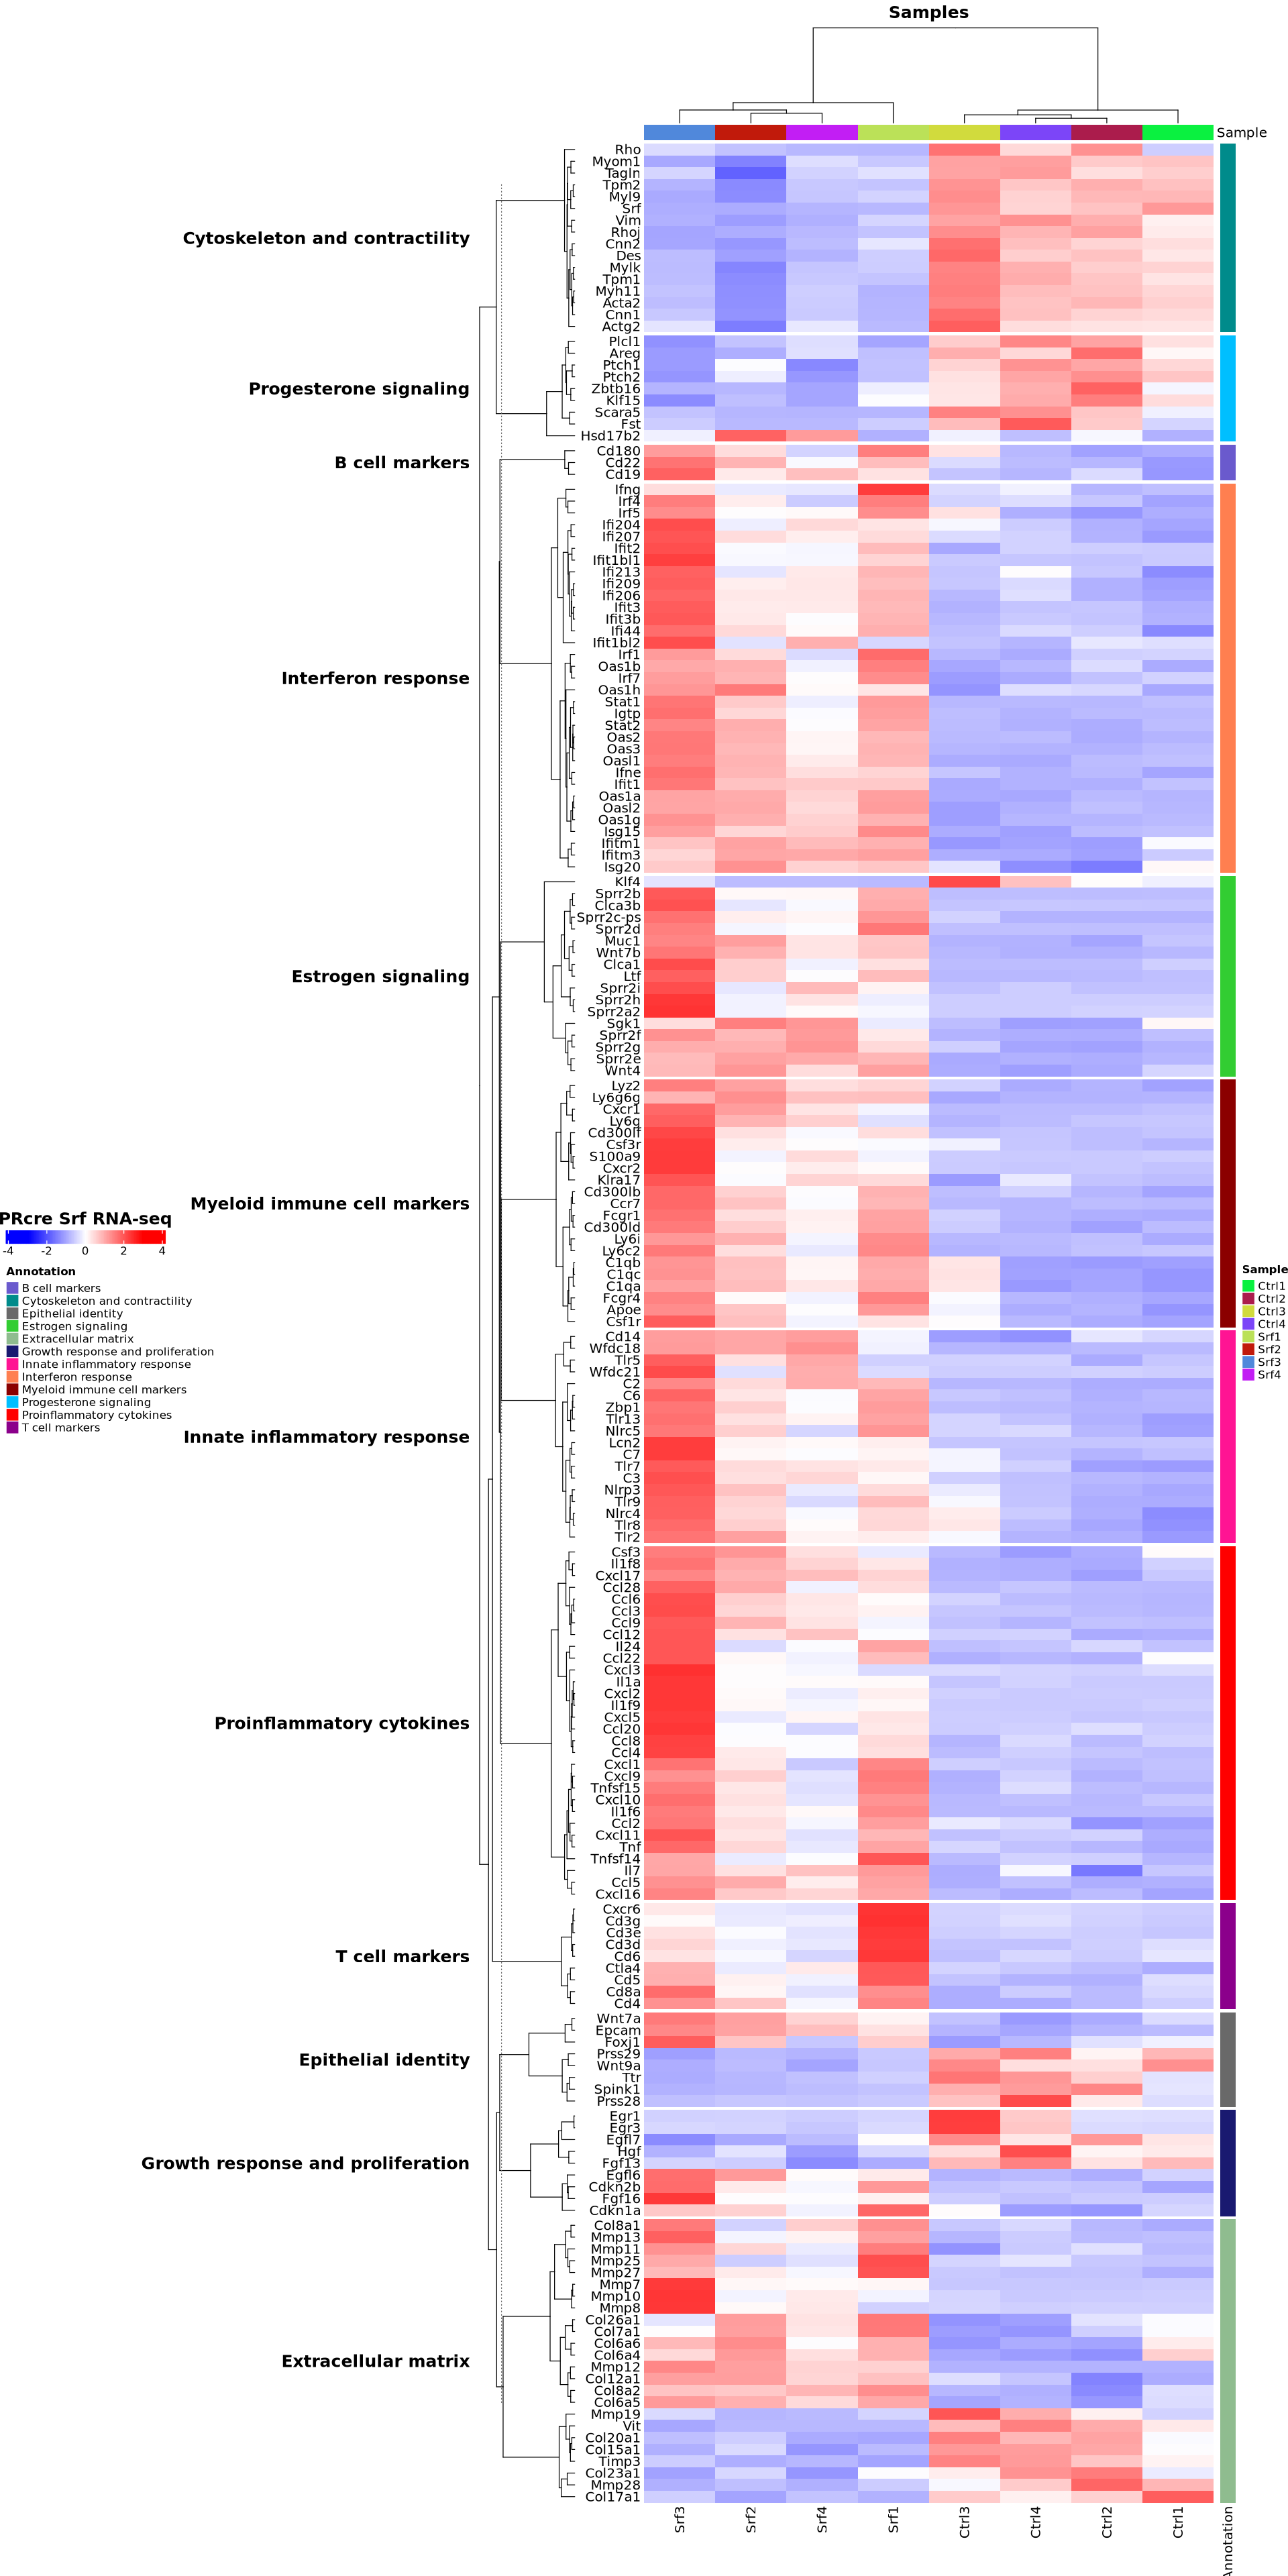

In [96]:
# Set heatmap parameters and draw

saved <- options(repr.plot.width = 16, repr.plot.height = 32) # Make the plots bigger from here on out, save old options

hmap <- Heatmap(heat,
        name="PRcre Srf RNA-seq",
        col=colorRamp2(myBreaks, myCol),
        heatmap_legend_param=list(color_bar="continuous", legend_direction="horizontal", legend_width=unit(5,"cm"), title_position="topcenter", title_gp=gpar(fontsize=15, fontface="bold")),

       #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=TRUE,
        show_row_dend=TRUE,
        #row_title="Transcript", #overridden by 'split' it seems
        row_title_side="left",
        row_title_gp=gpar(fontsize=15, fontface="bold"),
        show_row_names=TRUE,
        row_names_side="left",
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=TRUE,
        show_column_dend=TRUE,
        column_title="Samples",
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        #Dendrogram configurations: columns
        clustering_distance_columns=function(x) as.dist(1-cor(t(x))),
        clustering_method_columns="ward.D2",
        column_dend_height=unit(30,"mm"),

        #Dendrogram configurations: rows
        clustering_distance_rows="euclidean",
        clustering_method_rows="ward.D2",
        row_dend_width=unit(30,"mm"),

        #Annotations (row annotation must be added with 'draw' function, below)
        
        top_annotation=ColAnn)


draw(hmap + RowAnn, heatmap_legend_side="left", annotation_legend_side="right")

options(saved) # restore old settings

Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


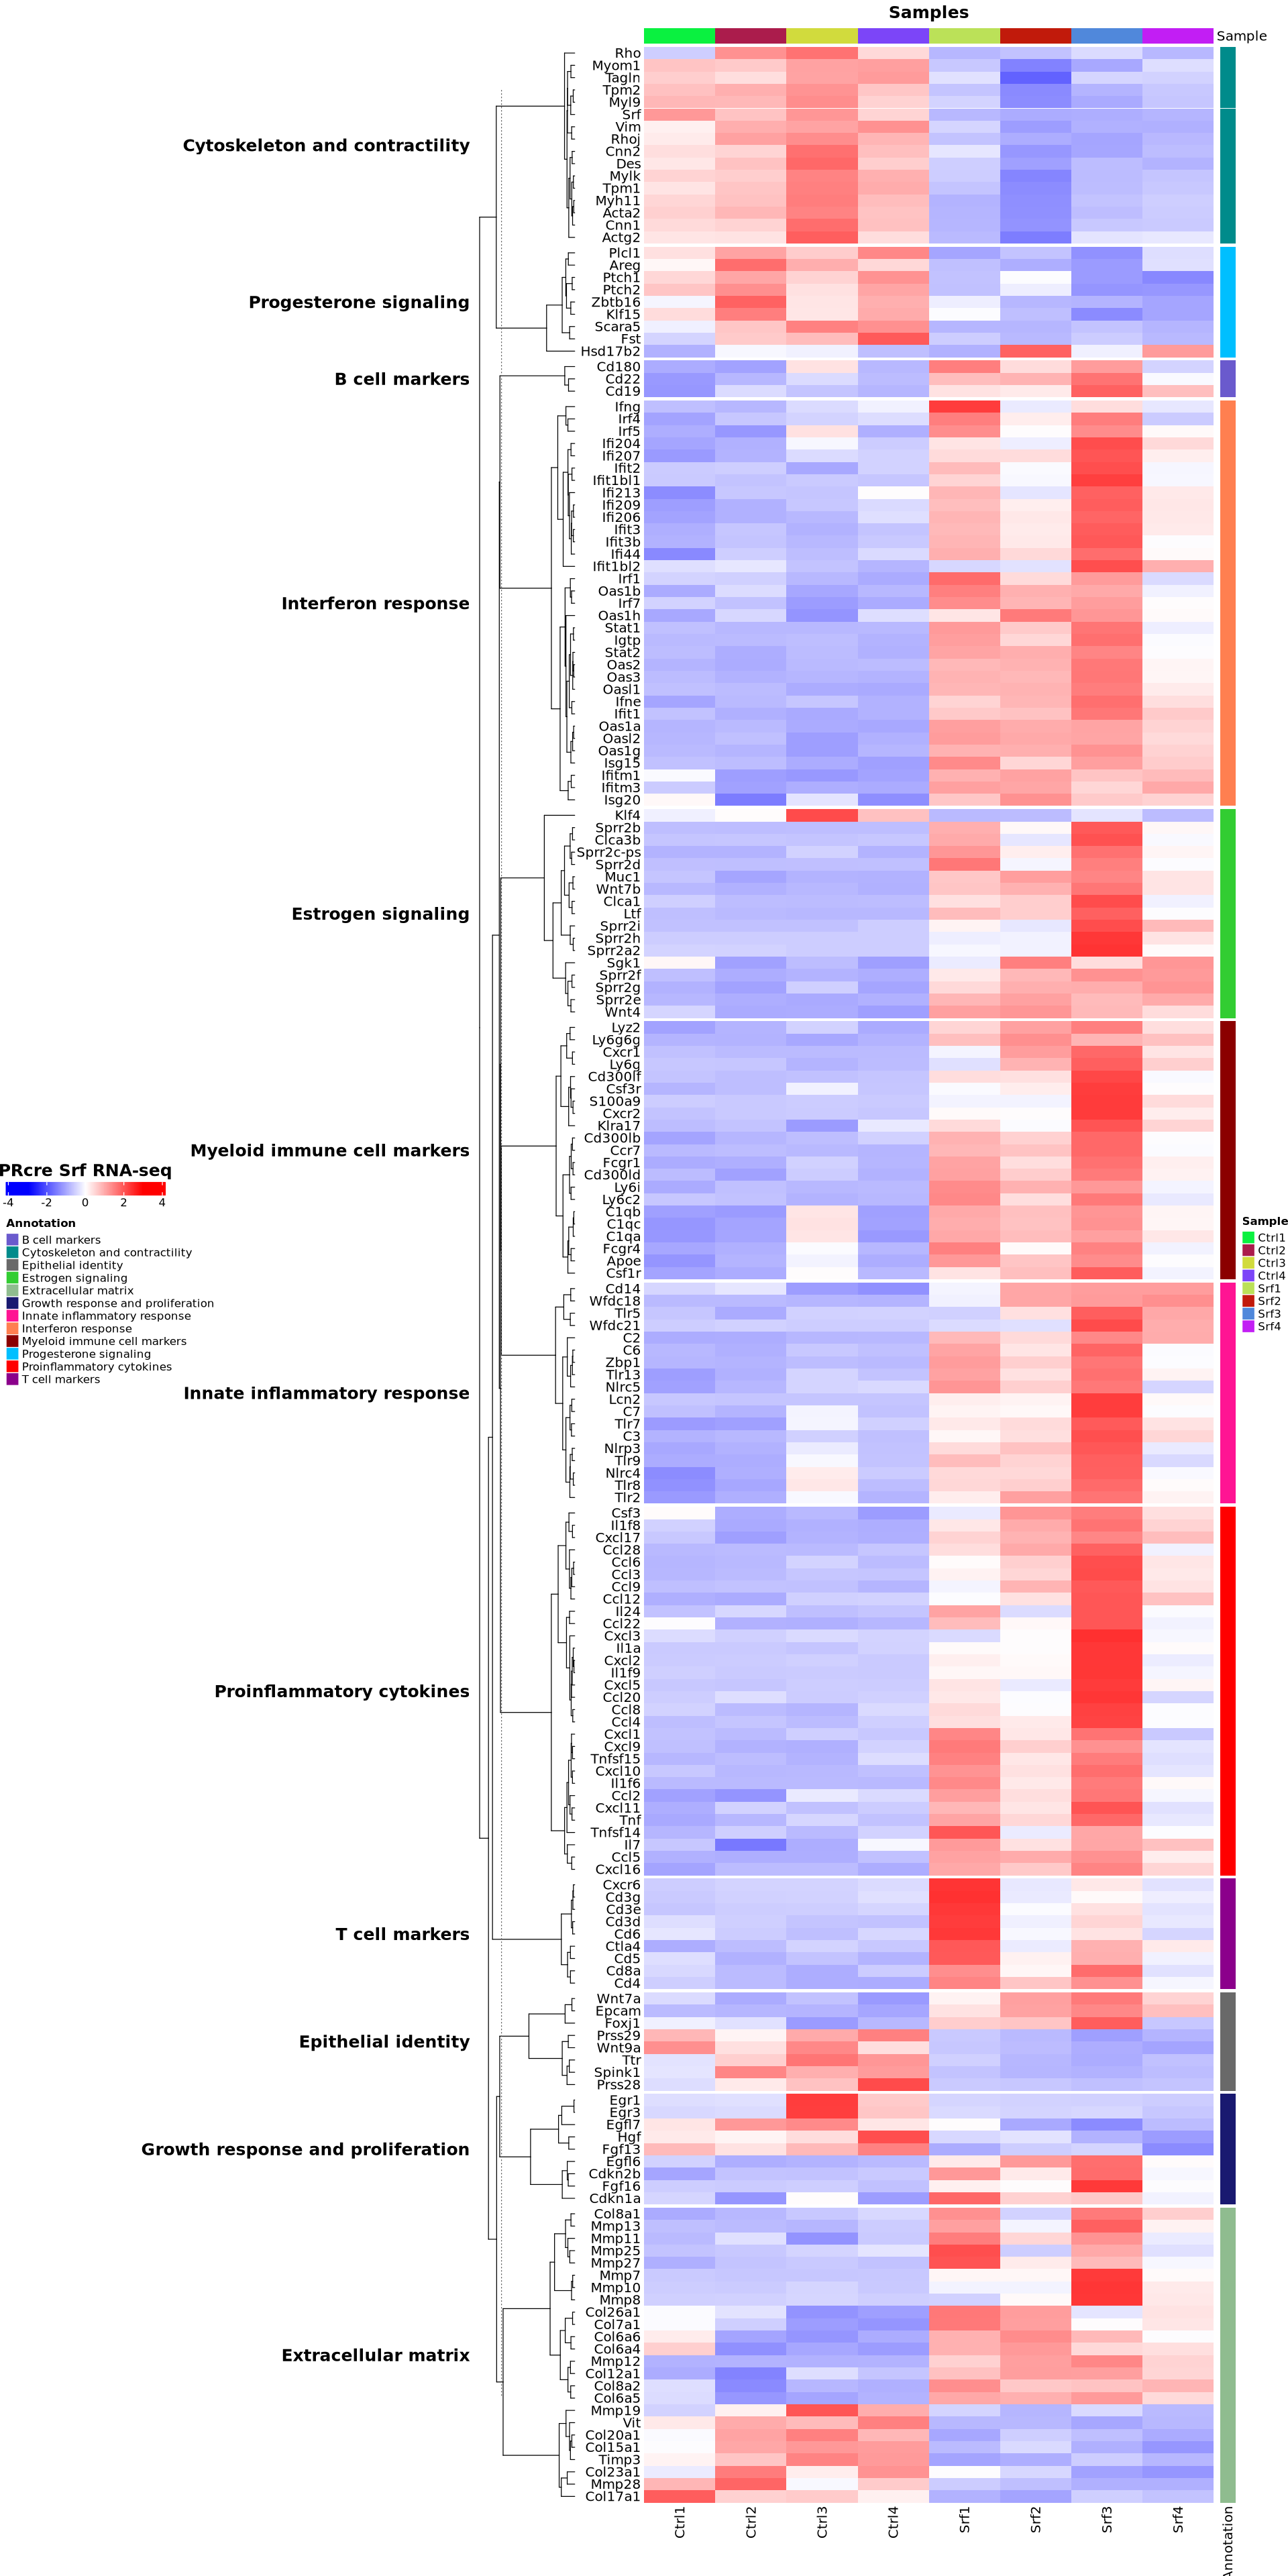

In [97]:
# Stop clustering samples

saved <- options(repr.plot.width = 16, repr.plot.height = 32) # Make the plots bigger from here on out, save old options

hmap <- Heatmap(heat,
        name="PRcre Srf RNA-seq",
        col=colorRamp2(myBreaks, myCol),
        heatmap_legend_param=list(color_bar="continuous", legend_direction="horizontal", legend_width=unit(5,"cm"), title_position="topcenter", title_gp=gpar(fontsize=15, fontface="bold")),

       #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=TRUE,
        show_row_dend=TRUE,
        #row_title="Transcript", #overridden by 'split' it seems
        row_title_side="left",
        row_title_gp=gpar(fontsize=15, fontface="bold"),
        show_row_names=TRUE,
        row_names_side="left",
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=FALSE,
        show_column_dend=FALSE,
        column_title="Samples",
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        #Keep column order instead of clustering
        column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
                
        #Dendrogram configurations: rows
        clustering_distance_rows="euclidean",
        clustering_method_rows="ward.D2",
        row_dend_width=unit(30,"mm"),

        #Annotations (row annotation must be added with 'draw' function, below)
        
        top_annotation=ColAnn)


draw(hmap + RowAnn, heatmap_legend_side="left", annotation_legend_side="right")

options(saved) # restore old settings

In [98]:
# If you want to adjust the sample order but keep clustering turned off, change column order in the matrix
new_order <- c(1, 2, 4, 3, 8, 6, 7, 5)
heat <- heat[, new_order]
head(heat) # check our work

,Ctrl1,Ctrl2,Ctrl4,Ctrl3,Srf4,Srf2,Srf3,Srf1
Il1f6,-0.8084016,-0.8101910,-0.8124950,-0.8120011,0.06719869,0.24651109,1.550334,1.37904526
Il1f9,-0.5589277,-0.6136892,-0.6205968,-0.6063832,-0.11568678,0.07302700,2.351862,0.09039428
Cxcl2,-0.6086525,-0.5930507,-0.6124931,-0.5552524,-0.21283047,0.05114528,2.347960,0.18317423
Cxcl5,-0.6413187,-0.6659588,-0.5987309,-0.5818326,0.10935597,-0.23424388,2.298382,0.31434729
Il1a,-0.6149226,-0.6144239,-0.5332582,-0.6750336,0.03942218,0.00117860,2.345225,0.05181296
Il24,-0.7129975,-0.4667646,-0.6688395,-0.7508520,-0.04179200,-0.41603368,1.983794,1.07348495


Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


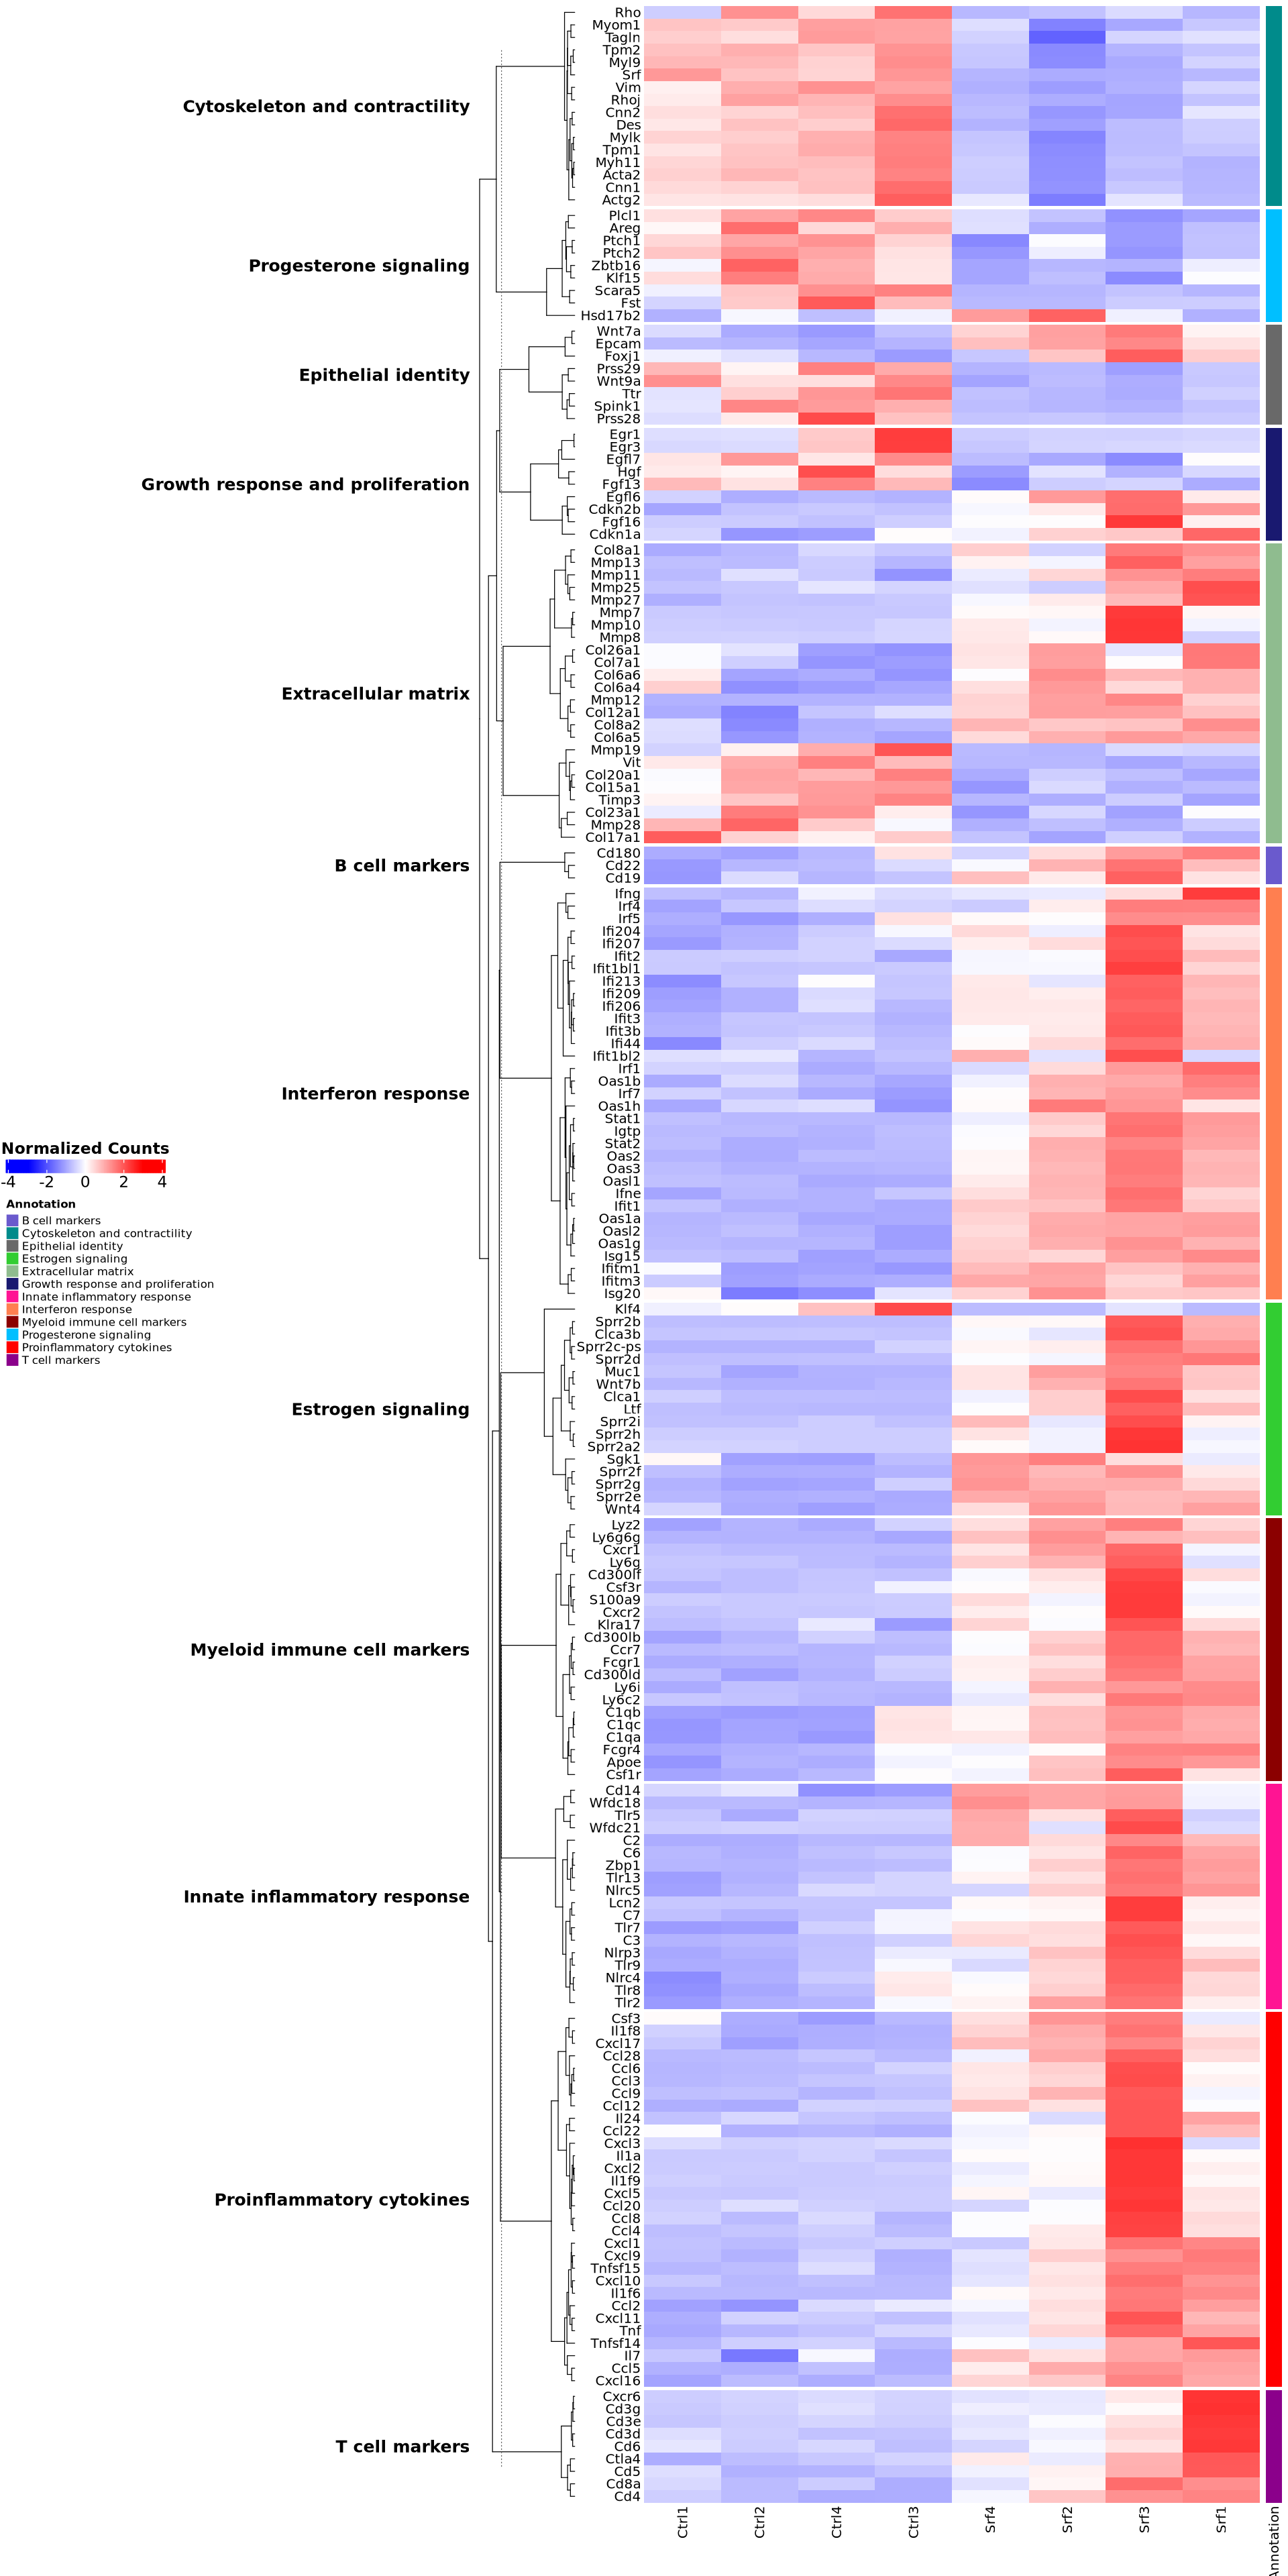

In [99]:
# Now plot again without sample annotation at the top

saved <- options(repr.plot.width = 16, repr.plot.height = 32) # Make the plots bigger from here on out, save old options

#Set annotation parameters

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c("Proinflammatory cytokines"="red","Interferon response"="coral", "Innate inflammatory response"="deeppink", "Myeloid immune cell markers"="darkred", "T cell markers"="darkmagenta", "B cell markers"="slateblue", "Estrogen signaling"="limegreen", "Progesterone signaling"="deepskyblue", "Cytoskeleton and contractility"="darkcyan", "Extracellular matrix"="darkseagreen", "Growth response and proliferation"="midnightblue", "Epithelial identity"="dimgrey"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, col=colours, which="row")

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

#Set heatmap parameters
hmap <- Heatmap(heat,
        name="Normalized Counts",
        col=colorRamp2(myBreaks, myCol),
        heatmap_legend_param=list(color_bar="continuous", 
            legend_direction="horizontal", 
            legend_width=unit(5,"cm"), 
            title_position="topcenter", 
            title_gp=gpar(fontsize=14, fontface="bold"),
            labels_gp=gpar(fontsize=14)),

       #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=TRUE,
        show_row_dend=TRUE,
        #row_title="Transcript", #overridden by 'split' it seems
        row_title_side="left",
        row_title_gp=gpar(fontsize=15, fontface="bold"),
        show_row_names=TRUE,
        row_names_side="left",
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=FALSE,
        show_column_dend=FALSE,
        column_title="", # blank the title and it won't show up
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        #Keep column order instead of clustering
        column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
                
        #Dendrogram configurations: rows
        clustering_distance_rows="euclidean",
        clustering_method_rows="ward.D2",
        row_dend_width=unit(30,"mm"))

        #Annotations (row annotation must be added with 'draw' function, below)
        
        # top_annotation=ColAnn) comment out the top annotation


draw(hmap + RowAnn, heatmap_legend_side="left", annotation_legend_side="right")

options(saved) # restore old settings

Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


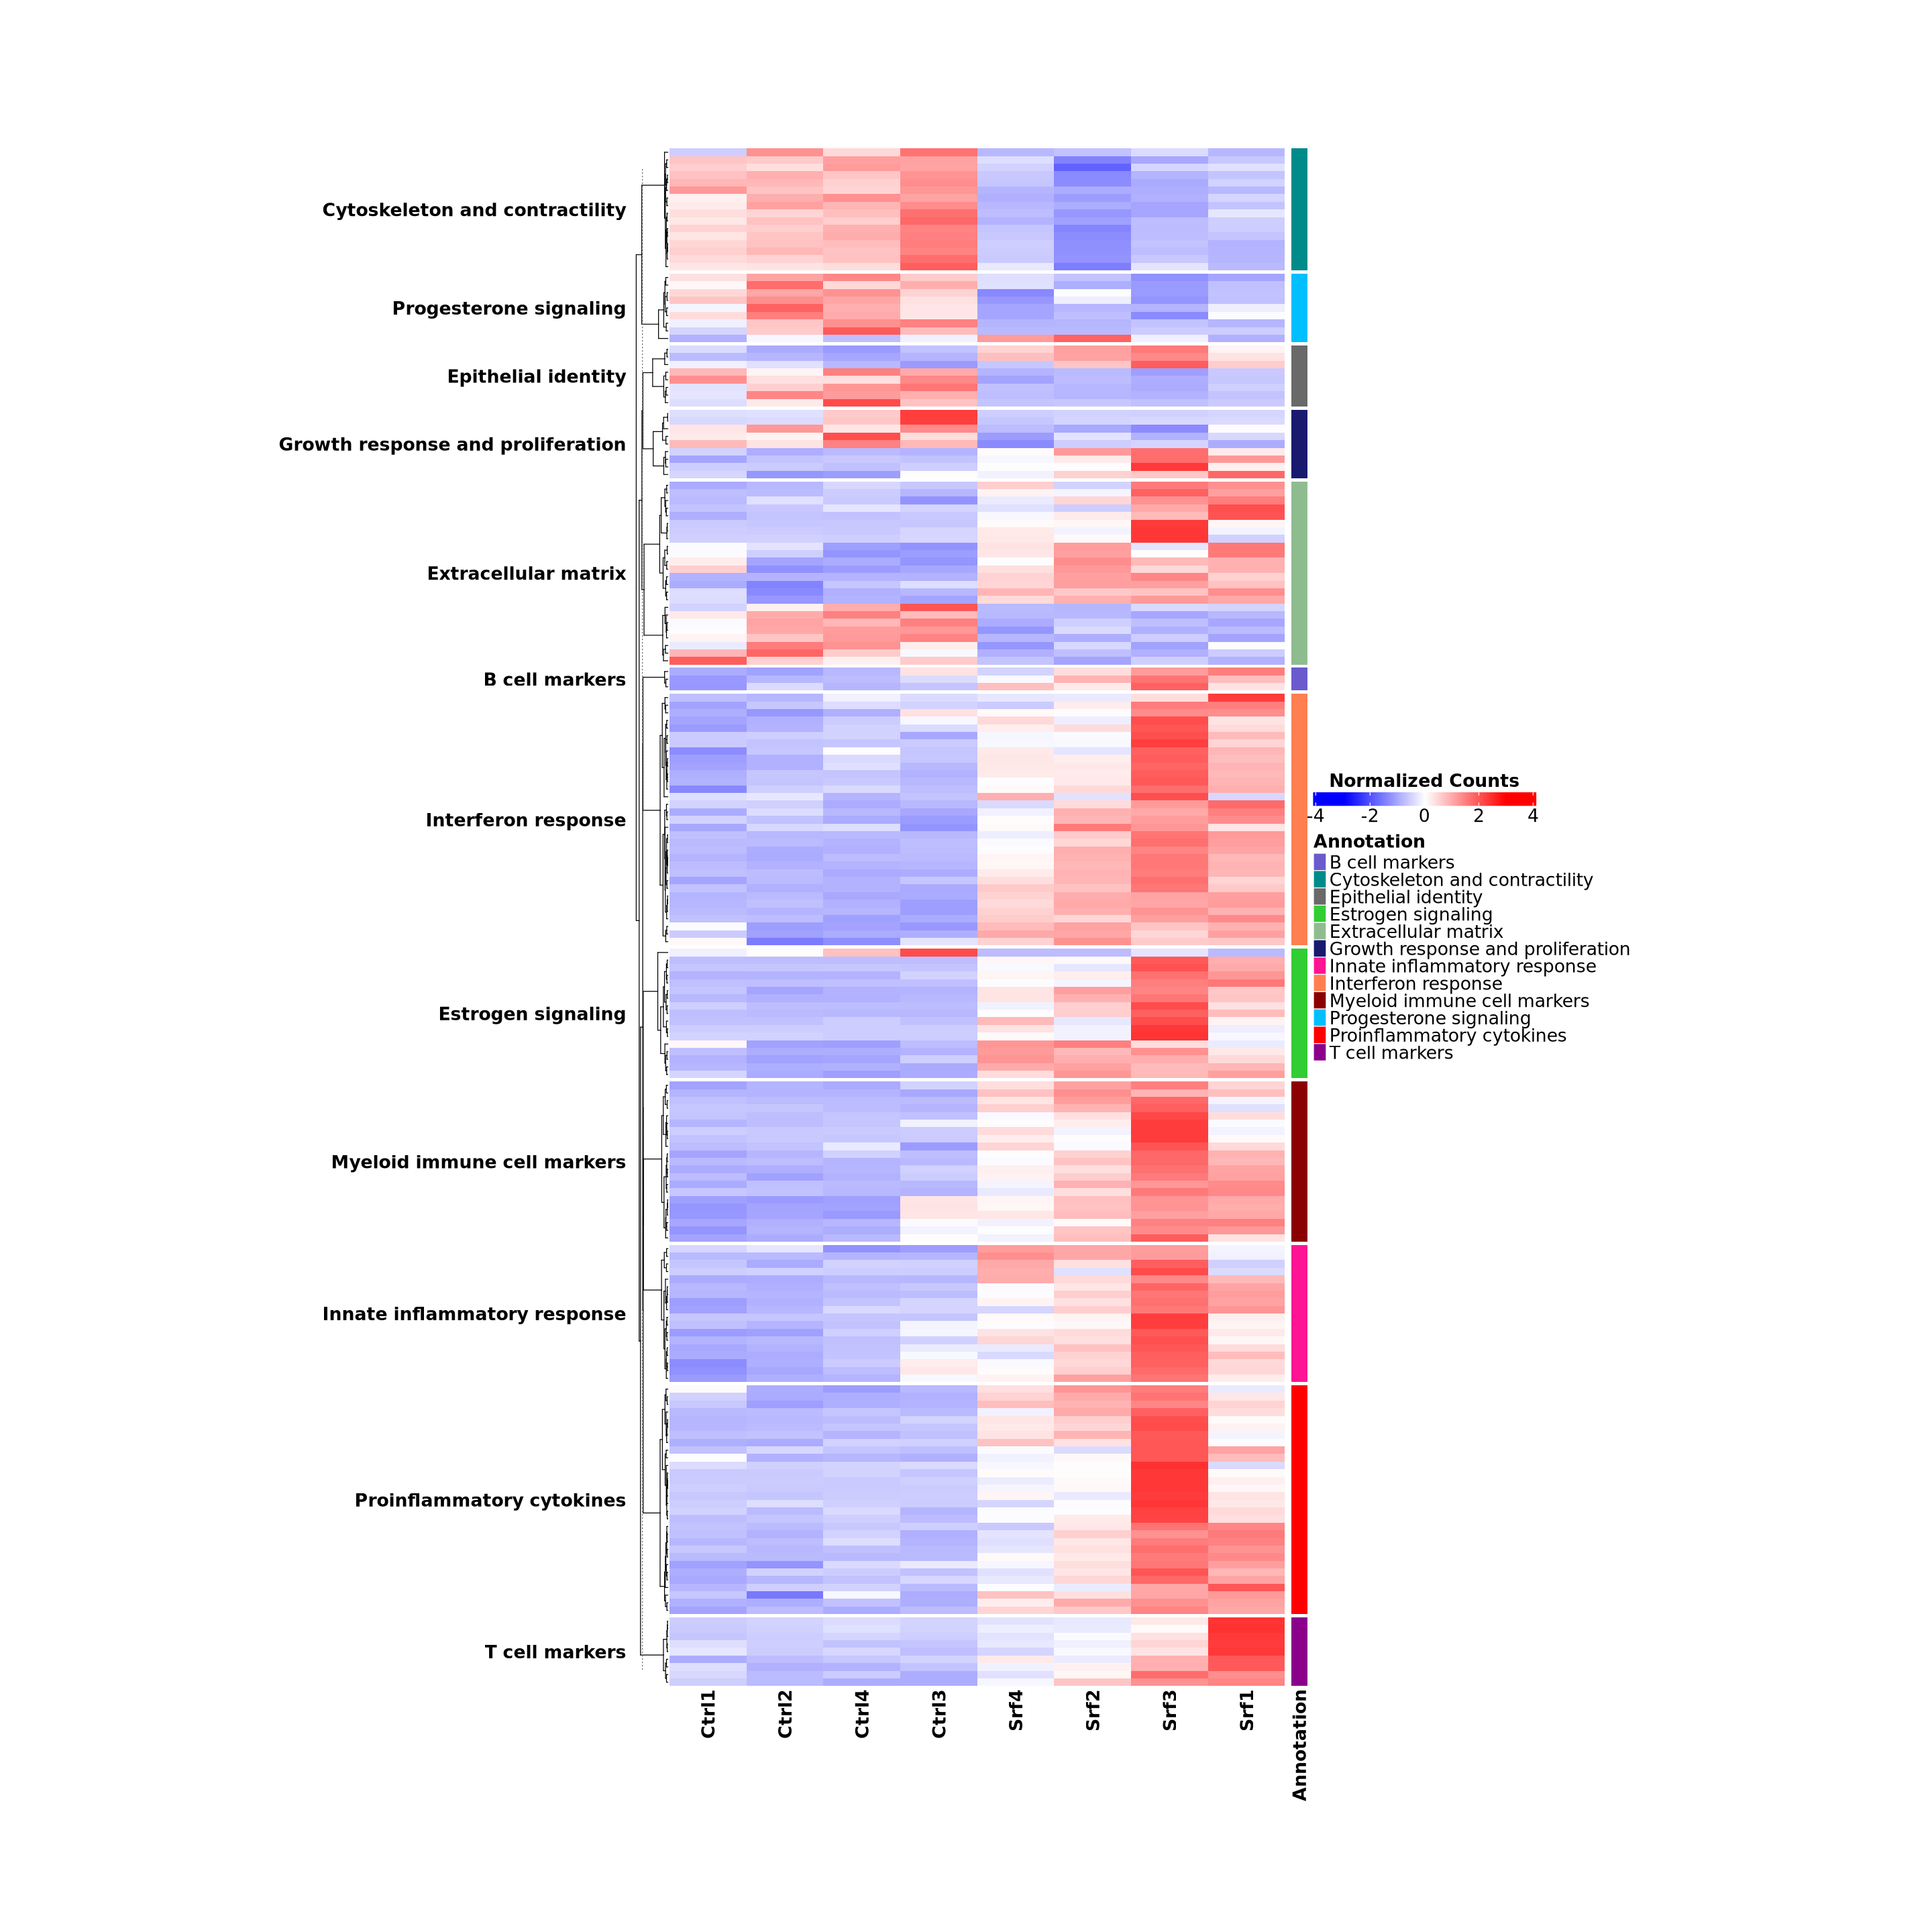

In [100]:
# Move legend to the right side

saved <- options(repr.plot.width = 24, repr.plot.height = 24) # Make the plots bigger from here on out, save old options

set.seed(123)
#Set annotation parameters

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c("Proinflammatory cytokines"="red","Interferon response"="coral", "Innate inflammatory response"="deeppink", "Myeloid immune cell markers"="darkred", "T cell markers"="darkmagenta", "B cell markers"="slateblue", "Estrogen signaling"="limegreen", "Progesterone signaling"="deepskyblue", "Cytoskeleton and contractility"="darkcyan", "Extracellular matrix"="darkseagreen", "Growth response and proliferation"="midnightblue", "Epithelial identity"="dimgrey"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, 
                              col=colours,
                              annotation_name_gp = gpar(fontsize = 16, fontface = "bold"),
                              which="row",
                              annotation_legend_param = list(
                                                title_gp = gpar(fontsize = 16, fontface = "bold"), 
                                                labels_gp = gpar(fontsize = 16)))

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

#Set heatmap parameters
hmap <- Heatmap(heat,
        name="Normalized Counts",
        col=colorRamp2(myBreaks, myCol),
        heatmap_width = unit(30,"cm"),
        heatmap_height = unit(50,"cm"),
        column_names_gp = gpar(fontsize = 16, fontface="bold"),
        heatmap_legend_param=list(color_bar="continuous", 
            legend_direction="horizontal", 
            legend_width=unit(7,"cm"), 
            title_position="topcenter", 
            title_gp=gpar(fontsize=16, fontface="bold"),
            labels_gp=gpar(fontsize=16)),

        #Keep column order instead of clustering
        column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
                
        #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=TRUE,
        show_row_dend=TRUE,
        row_title_side="left",
        row_title_gp=gpar(fontsize=16, fontface="bold"),
        show_row_names=FALSE,
        row_names_side="left",
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=FALSE,
        show_column_dend=FALSE,
        column_title="",
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        
                
        #Dendrogram configurations: rows
        clustering_distance_rows="euclidean",
        clustering_method_rows="ward.D2",
        row_dend_width=unit(10,"mm"))

        #Annotations (row annotation must be added with 'draw' function, below)
        


draw(hmap + RowAnn, heatmap_legend_side="right", annotation_legend_side="right")

options(saved) # restore old settings

Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


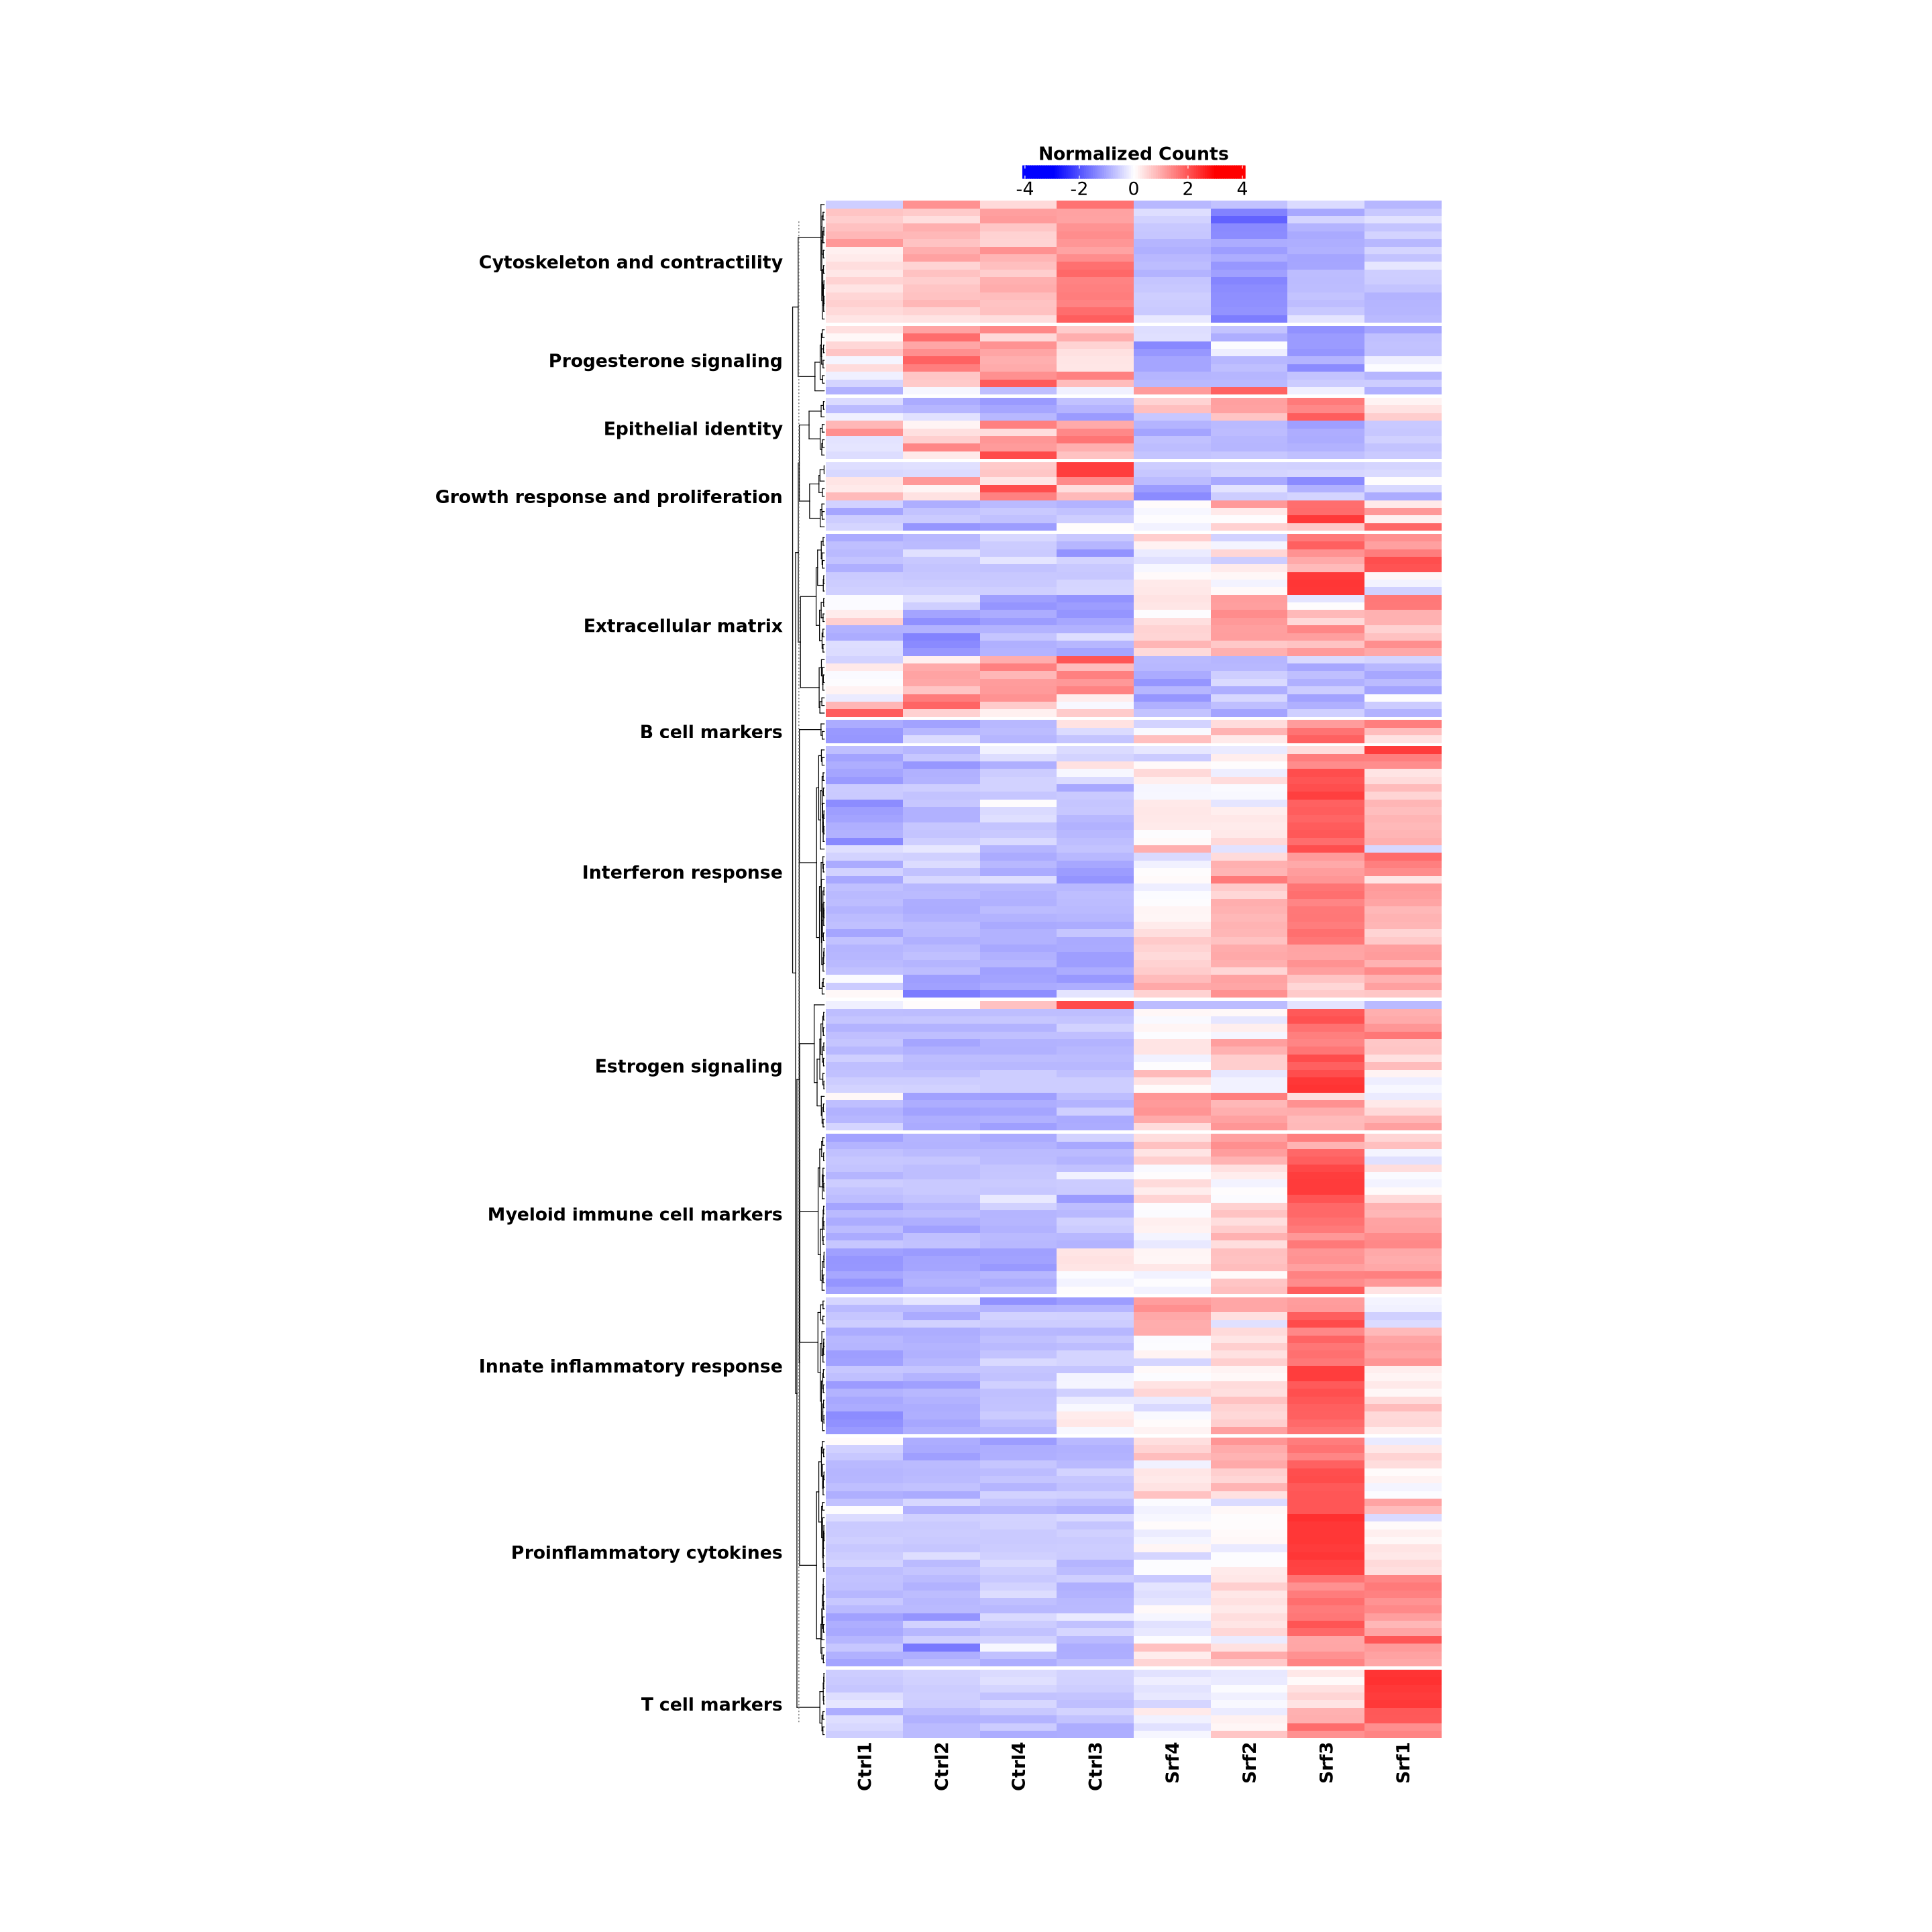

In [101]:
# draw again without right side annotation (just left off the final draw function)

saved <- options(repr.plot.width = 24, repr.plot.height = 24) # Make the plots bigger from here on out, save old options

set.seed(123)
#Set annotation parameters

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c("Proinflammatory cytokines"="red","Interferon response"="coral", "Innate inflammatory response"="deeppink", "Myeloid immune cell markers"="darkred", "T cell markers"="darkmagenta", "B cell markers"="slateblue", "Estrogen signaling"="limegreen", "Progesterone signaling"="deepskyblue", "Cytoskeleton and contractility"="darkcyan", "Extracellular matrix"="darkseagreen", "Growth response and proliferation"="midnightblue", "Epithelial identity"="dimgrey"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, 
                              col=colours,
                              annotation_name_gp = gpar(fontsize = 16, fontface = "bold"),
                              which="row",
                              annotation_legend_param = list(
                                                title_gp = gpar(fontsize = 16, fontface = "bold"), 
                                                labels_gp = gpar(fontsize = 16)))

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

#Set heatmap parameters
hmap <- Heatmap(heat,
        name="Normalized Counts",
        col=colorRamp2(myBreaks, myCol),
        heatmap_width = unit(30,"cm"),
        heatmap_height = unit(50,"cm"),
        column_names_gp = gpar(fontsize = 16, fontface="bold"),
        heatmap_legend_param=list(color_bar="continuous", 
            legend_direction="horizontal", 
            legend_width=unit(7,"cm"), 
            title_position="topcenter", 
            title_gp=gpar(fontsize=16, fontface="bold"),
            labels_gp=gpar(fontsize=16)),

        #Keep column order instead of clustering
        column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
                
        #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=TRUE,
        show_row_dend=TRUE,
        row_title_side="left",
        row_title_gp=gpar(fontsize=16, fontface="bold"),
        show_row_names=FALSE,
        row_names_side="left",
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=FALSE,
        show_column_dend=FALSE,
        column_title="",
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        
                
        #Dendrogram configurations: rows
        clustering_distance_rows="euclidean",
        clustering_method_rows="ward.D2",
        row_dend_width=unit(10,"mm"))

        #Annotations (row annotation must be added with 'draw' function, below)
        


draw(hmap, heatmap_legend_side="top")

options(saved) # restore old settings

Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


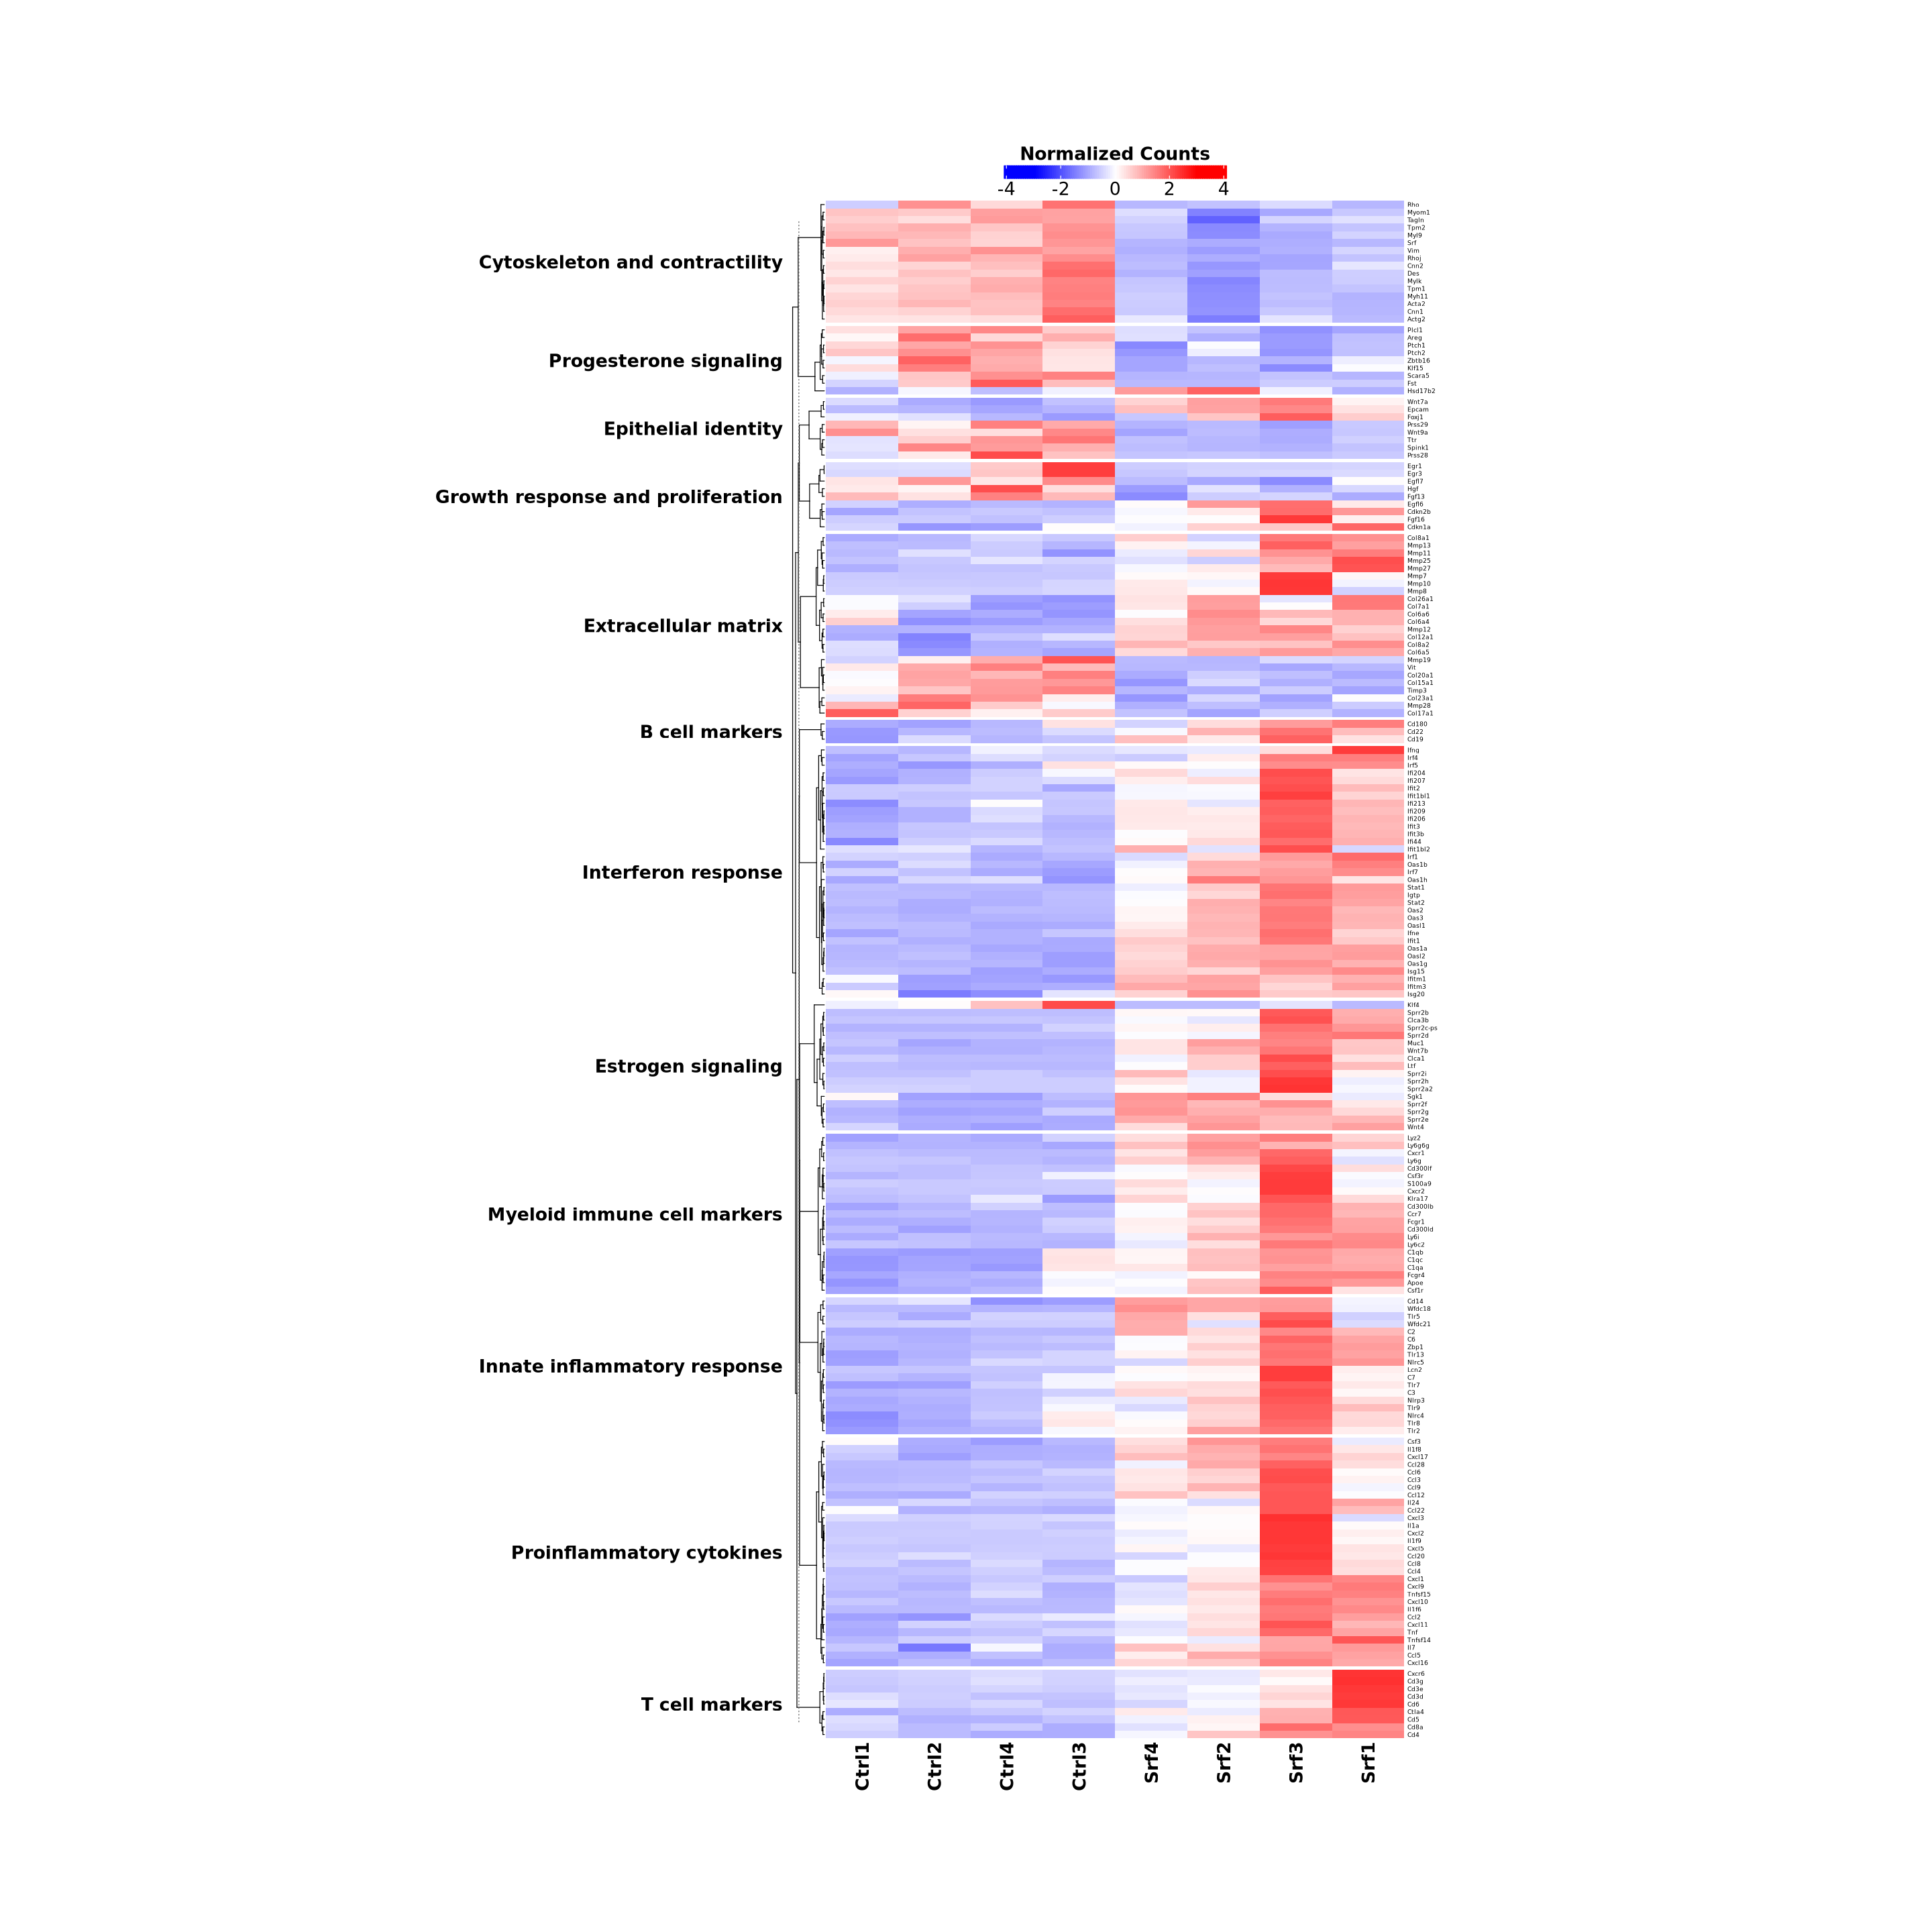

In [102]:
# draw again without right side annotation, adding row titles

saved <- options(repr.plot.width = 24, repr.plot.height = 24) # Make the plots bigger from here on out, save old options

set.seed(123)
#Set annotation parameters

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c("Proinflammatory cytokines"="red","Interferon response"="coral", "Innate inflammatory response"="deeppink", "Myeloid immune cell markers"="darkred", "T cell markers"="darkmagenta", "B cell markers"="slateblue", "Estrogen signaling"="limegreen", "Progesterone signaling"="deepskyblue", "Cytoskeleton and contractility"="darkcyan", "Extracellular matrix"="darkseagreen", "Growth response and proliferation"="midnightblue", "Epithelial identity"="dimgrey"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, 
                              col=colours,
                              annotation_name_gp = gpar(fontsize = 16, fontface = "bold"),
                              which="row",
                              annotation_legend_param = list(
                                                title_gp = gpar(fontsize = 16, fontface = "bold"), 
                                                labels_gp = gpar(fontsize = 16)))

myBreaks <- seq(-3, 3, length.out=100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

#Set heatmap parameters
hmap <- Heatmap(heat,
        name="Normalized Counts",
        col=colorRamp2(myBreaks, myCol),
        heatmap_width = unit(30,"cm"),
        heatmap_height = unit(50,"cm"),
        column_names_gp = gpar(fontsize = 16, fontface="bold"),
        heatmap_legend_param=list(color_bar="continuous", 
            legend_direction="horizontal", 
            legend_width=unit(7,"cm"), 
            title_position="topcenter", 
            title_gp=gpar(fontsize=16, fontface="bold"),
            labels_gp=gpar(fontsize=16)),

        #Keep column order instead of clustering
        column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
                
        #Split heatmap rows by annotation
        split=df$Annotation,

        #Row annotation configurations
        cluster_rows=TRUE,
        show_row_dend=TRUE,
        row_title_side="left",
        row_title_gp=gpar(fontsize=16, fontface="bold"),
        show_row_names=TRUE,
        row_names_side="right",
        row_names_gp=gpar(fontsize=5.5),
        row_names_rot=0,
        row_title_rot=0,

        #Column annotation configuratiions
        cluster_columns=FALSE,
        show_column_dend=FALSE,
        column_title="",
        column_title_side="top",
        column_title_gp=gpar(fontsize=15, fontface="bold"),
        column_title_rot=0,
        show_column_names=TRUE,

        
                
        #Dendrogram configurations: rows
        clustering_distance_rows="euclidean",
        clustering_method_rows="ward.D2",
        row_dend_width=unit(10,"mm"))

        #Annotations (row annotation must be added with 'draw' function, below)
        


draw(hmap, heatmap_legend_side="top")

options(saved) # restore old settings

# Annotate selected genes instead of color-coding annotation groups

Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


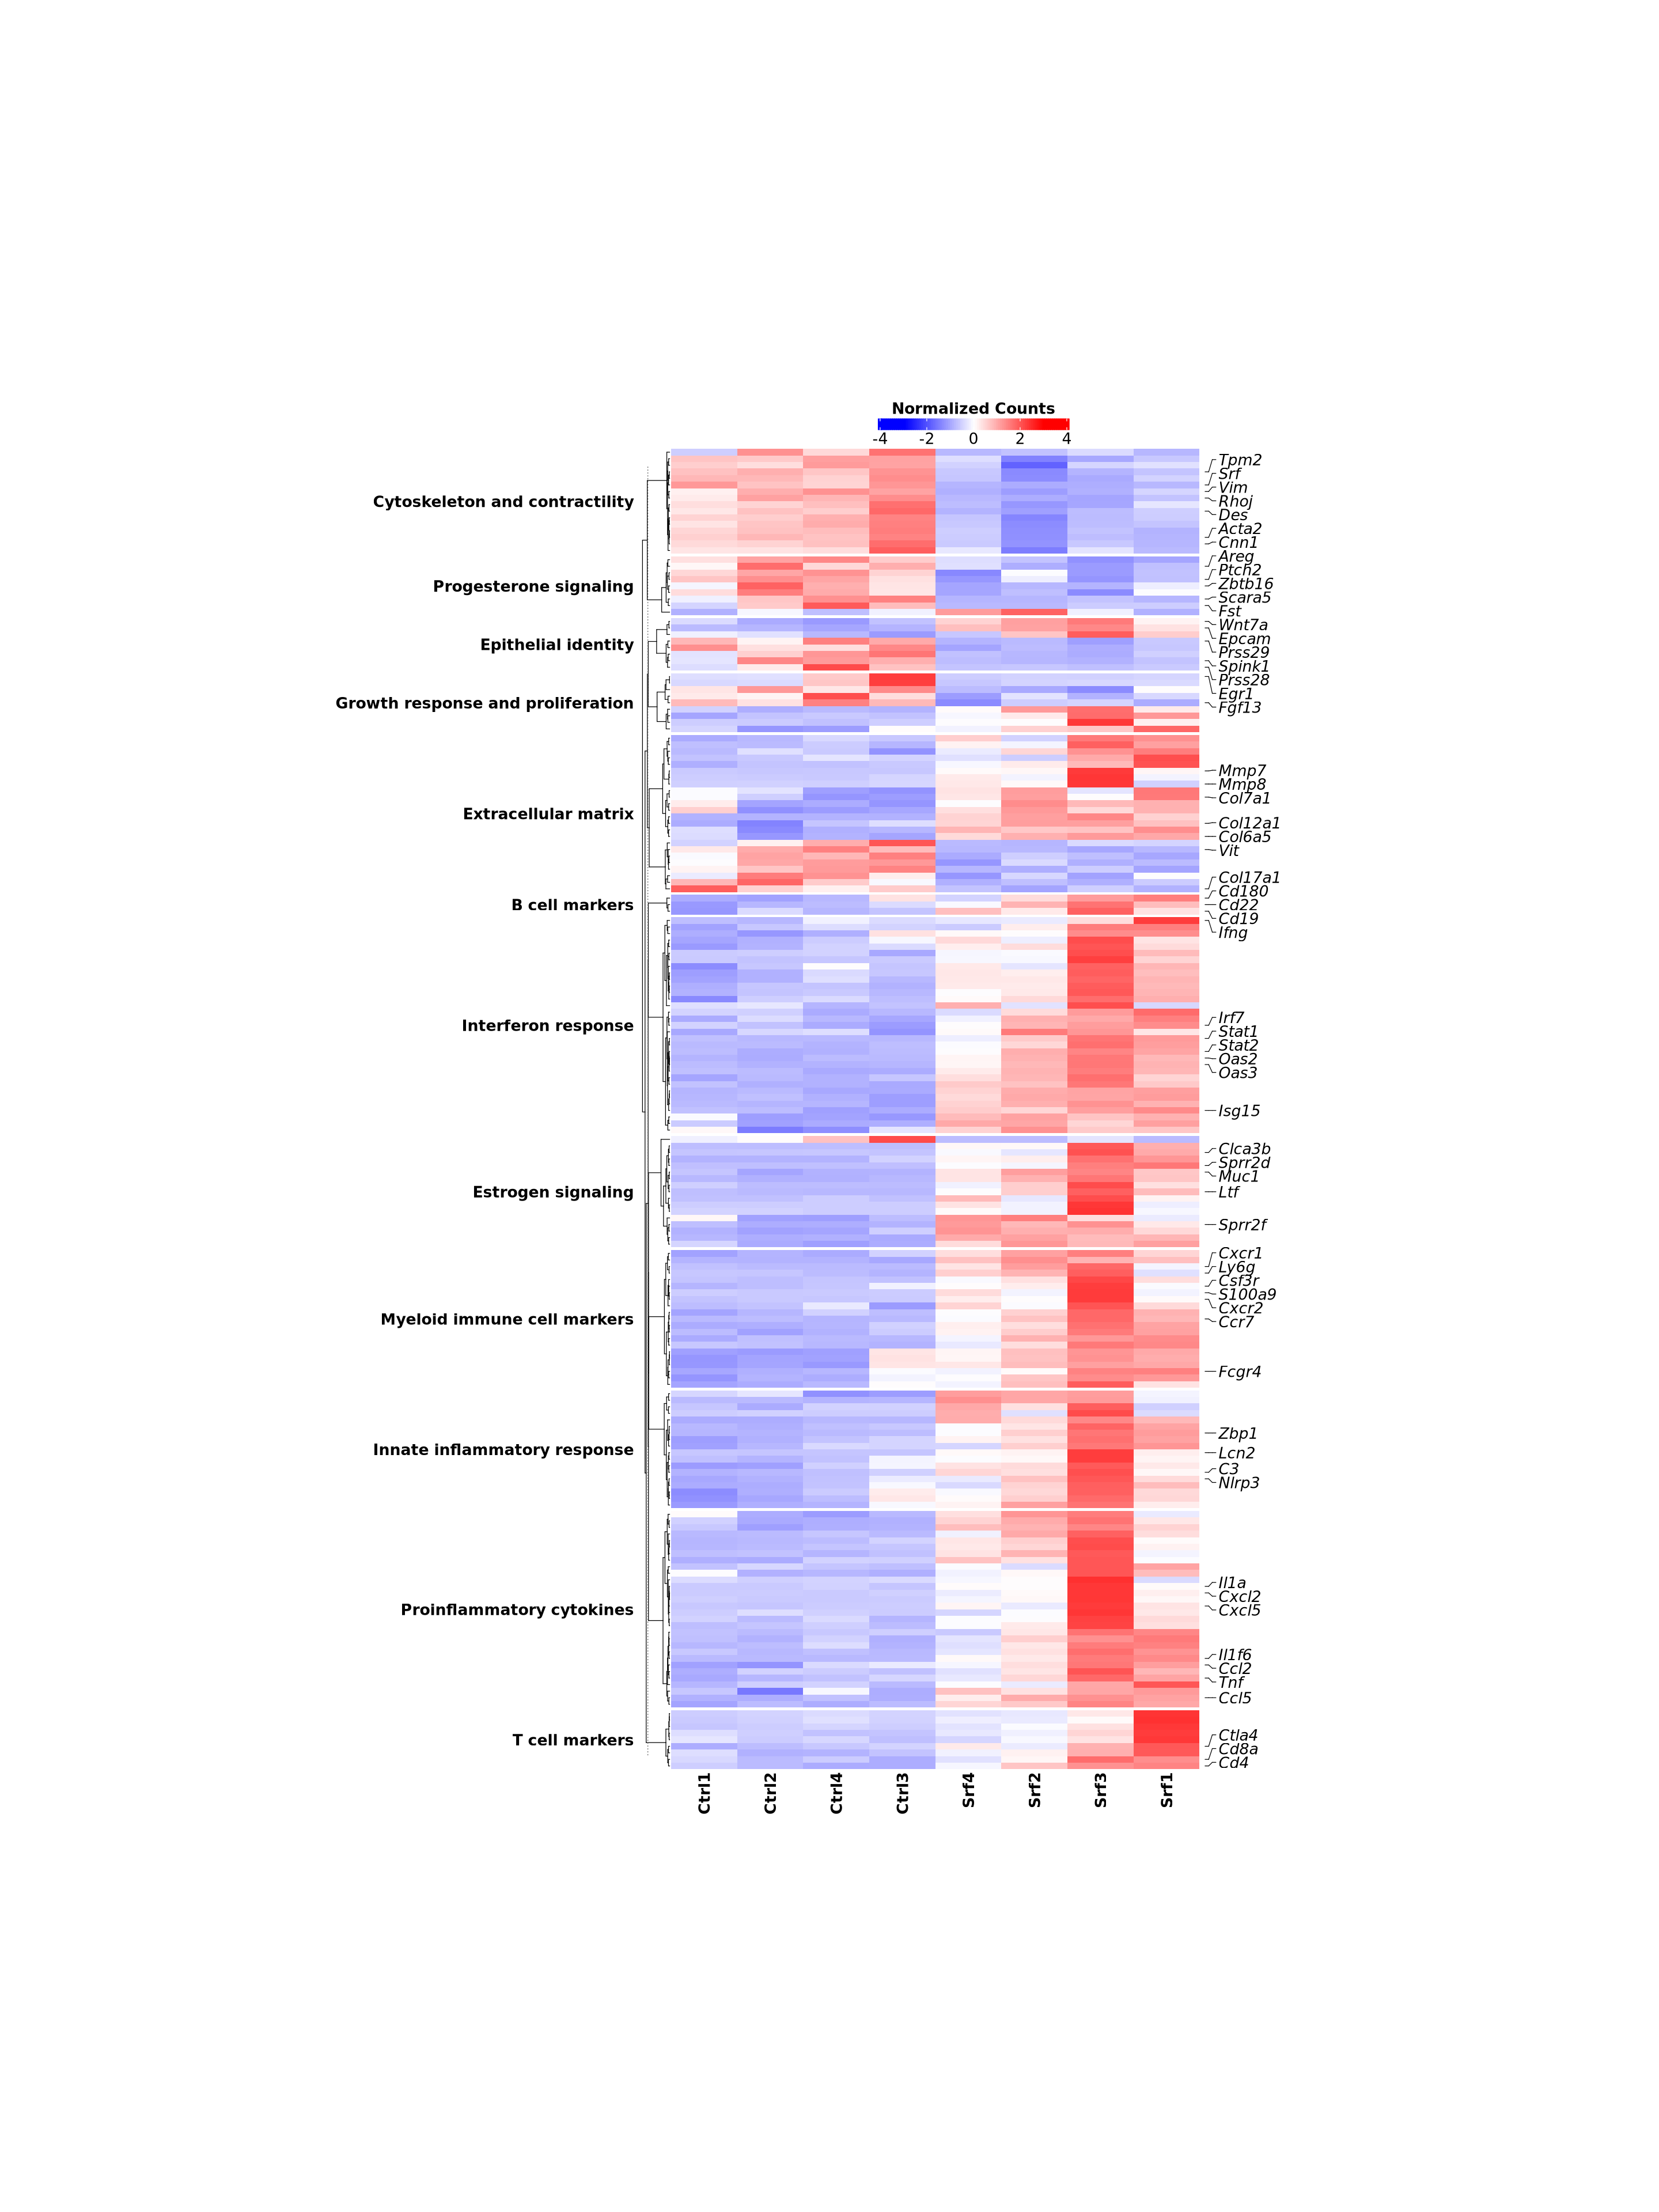

In [103]:
# draw again, now with right side annotation of specific genes
# See https://jokergoo.github.io/ComplexHeatmap-reference/book/heatmap-annotations.html#mark-annotation
# Also got some help from chatGPT to modify the code

saved <- options(repr.plot.width = 24, repr.plot.height = 32) # Make the plots bigger from here on out, save old options

set.seed(123)

# Generate heatmap colors
myBreaks <- seq(-3, 3, length.out = 100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

# Define rows to mark
rows_to_mark <- c("Il1f6", "Cxcl2", "Cxcl5", "Il1a", "Ccl5", "Ccl2", "Tnf",  # List genes to mark (from row names list); here proinflammatory cytokines
                  "Oas3", "Oas2", "Ifng", "Isg15", "Stat1", "Stat2", "Irf7", # interferon response
                  "Lcn2", "C3", "Nlrp3", "Zbp1", # innate inflammatory response
                  "Cxcr1", "Ly6g", "S100a9", "Cxcr2", "Ccr7", "Csf3r", "Fcgr4", # myeloid immune cell markers
                  "Ctla4", "Cd8a", "Cd4", # T cell markers
                  "Cd22", "Cd180", "Cd19", # B cell markers
                  "Sprr2d", "Ltf", "Clca3b", "Sprr2f", "Muc1", # estrogen signaling
                  "Zbtb16", "Scara5", "Fst", "Areg", "Ptch2", # progesterone signaling
                  "Srf", "Acta2", "Cnn1", "Tpm2", "Rhoj", "Des", "Vim", # cytoskeleton
                  "Mmp7", "Mmp8", "Col6a5", "Col12a1", "Col7a1", "Col17a1", "Vit", # extracellular matrix
                  "Egr1", "Fgf13", #growth response
                  "Wnt7a", "Epcam", "Prss28", "Spink1", "Prss29" # epithelial identity
                  )       
mark_indices <- match(rows_to_mark, rownames(heat))  # Get row indices

# Add row annotations using anno_mark
RowAnn <- rowAnnotation(
  mark = anno_mark(
    at = mark_indices,                 # Row indices to mark
    labels = rows_to_mark,             # Labels for the marked rows
    labels_gp = gpar(fontsize = 16, fontface = "italic"),   # Font size for labels
    link_gp = gpar(lwd = 1, col = "black") # Line properties
  )
)

# Set heatmap parameters
hmap <- Heatmap(
  heat,
  name = "Normalized Counts",
  col = colorRamp2(myBreaks, myCol),
  heatmap_width = unit(30, "cm"),
  heatmap_height = unit(50, "cm"),
  column_names_gp = gpar(fontsize = 16, fontface = "bold"),
  heatmap_legend_param = list(
    color_bar = "continuous",
    legend_direction = "horizontal",
    legend_width = unit(7, "cm"),
    title_position = "topcenter",
    title_gp = gpar(fontsize = 16, fontface = "bold"),
    labels_gp = gpar(fontsize = 16)
  ),
  
    # Keep column order instead of clustering
  column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
  
    # Split heatmap rows by annotation
  split = df$Annotation,
  
    # Row annotation configurations
  cluster_rows = TRUE,
  show_row_dend = TRUE,
  row_title_side = "left",
  row_title_gp = gpar(fontsize = 16, fontface = "bold"),
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 5.5),
  row_names_rot = 0,
  row_title_rot = 0,
  # Column annotation configurations
  cluster_columns = FALSE,
  show_column_dend = FALSE,
  column_title = "",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = 15, fontface = "bold"),
  column_title_rot = 0,
  show_column_names = TRUE,
  # Dendrogram configurations: rows
  clustering_distance_rows = "euclidean",
  clustering_method_rows = "ward.D2",
  row_dend_width = unit(10, "mm")
)

# Draw heatmap with row annotations
draw(hmap + RowAnn, heatmap_legend_side = "top")

options(saved) # restore old settings


Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


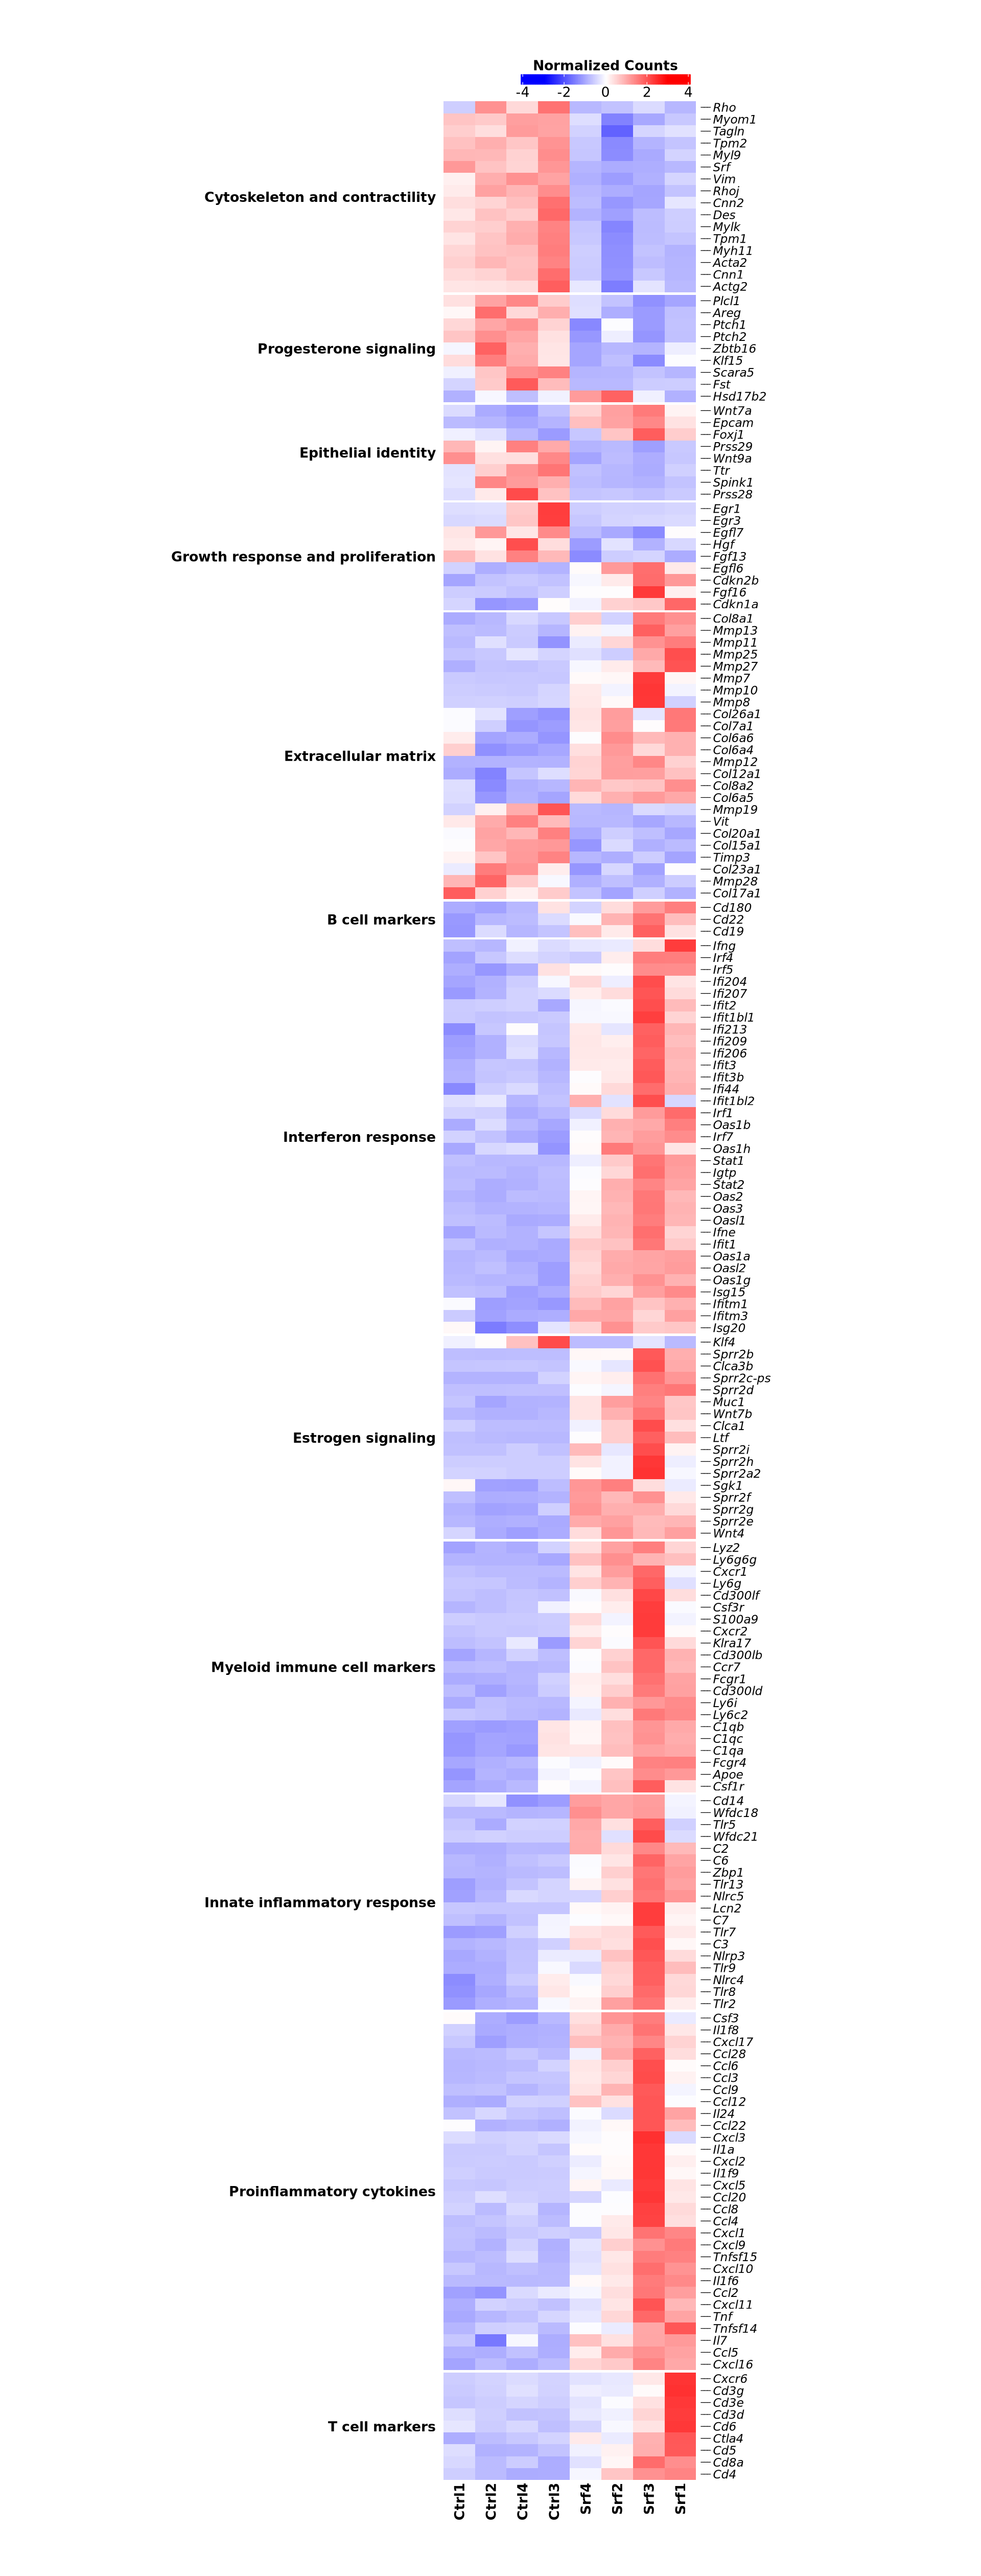

In [105]:
# Mark all genes, remove dendrogram

# draw again, now with right side annotation of specific genes
# See https://jokergoo.github.io/ComplexHeatmap-reference/book/heatmap-annotations.html#mark-annotation
# Also got some help from chatGPT to modify the code

saved <- options(repr.plot.width = 16, repr.plot.height = 42) # Make the plots bigger from here on out, save old options

set.seed(123)

# Generate heatmap colors
myBreaks <- seq(-3, 3, length.out = 100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

# Define rows to mark
rows_to_mark <- c("Il1f6", "Il1f9", "Cxcl2", "Cxcl5", "Il1a", "Il24", "Ccl20", "Ccl28", "Cxcl10", "Il1f8", "Ccl3", "Tnfsf15", "Cxcl11", "Ccl4", "Cxcl9", "Ccl5", "Cxcl1", "Cxcl17", "Cxcl3", "Tnf", "Ccl8", "Ccl12", "Ccl9", "Ccl2", "Cxcl16", "Ccl6", "Ccl22", "Tnfsf14", "Csf3", "Il7", "Oas3", "Ifit1bl1", "Ifng", "Oas2", "Ifne", "Ifit3b", "Oasl1", "Ifit3", "Ifi209", "Ifit1", "Ifi206", "Isg15", "Oas1g", "Ifi207", "Oas1a", "Oasl2", "Ifitm1", "Irf7", "Ifit1bl2", "Igtp", "Irf4", "Stat1", "Oas1h", "Ifit2", "Ifi204", "Ifi213", "Stat2", "Ifi44", "Oas1b", "Isg20", "Irf5", "Ifitm3", "Irf1", "Lcn2", "Wfdc21", "Wfdc18", "Zbp1", "C6", "C3", "Nlrp3", "Tlr13", "Tlr8", "Tlr7", "C2", "Nlrc5", "Tlr9", "C7", "Nlrc4", "Tlr2", "Tlr5", "Cd14", "Cxcr1", "Ly6g6g", "S100a9", "Cxcr2", "Ly6i", "Ly6c2", "Ccr7", "Cd300lf", "Ly6g", "Cd300lb", "Csf3r", "Fcgr4", "Fcgr1", "Lyz2", "Klra17", "Cd300ld", "Apoe", "C1qb", "C1qc", "C1qa", "Csf1r", "Ctla4", "Cd8a", "Cd3e", "Cxcr6", "Cd3g", "Cd3d", "Cd5", "Cd4", "Cd6", "Cd22", "Cd180", "Cd19", "Sprr2d", "Sprr2b", "Sprr2h", "Sprr2i", "Sprr2a2", "Ltf", "Clca3b", "Sprr2e", "Sprr2c-ps", "Clca1", "Sprr2f", "Wnt7b", "Sprr2g", "Wnt4", "Muc1", "Sgk1", "Klf4", "Hsd17b2", "Klf15", "Ptch1", "Ptch2", "Zbtb16", "Scara5", "Fst", "Areg", "Actg2", "Tagln", "Vim", "Mylk", "Rho", "Des", "Rhoj", "Myom1", "Cnn1", "Tpm1", "Tpm2", "Myl9", "Myh11", "Cnn2", "Acta2", "Srf", "Mmp12", "Mmp7", "Mmp13", "Mmp8", "Mmp10", "Col6a5", "Mmp27", "Col12a1", "Col6a6", "Mmp25", "Col7a1", "Col6a4", "Col8a2", "Col26a1", "Col8a1", "Mmp11", "Mmp19", "Timp3", "Col23a1", "Col15a1", "Col20a1", "Col17a1", "Mmp28", "Vit", "Fgf16", "Egfl6", "Egfl7", "Fgf13", "Egr1", "Egr3", "Wnt7a", "Epcam", "Foxj1", "Wnt9a", "Ttr", "Prss29", "Spink1", "Prss28", "Cdkn2b", "Cdkn1a", "Hgf", "Plcl1" 
                  )       
mark_indices <- match(rows_to_mark, rownames(heat))  # Get row indices

# Add row annotations using anno_mark
RowAnn <- rowAnnotation(
  mark = anno_mark(
    at = mark_indices,                 # Row indices to mark
    labels = rows_to_mark,             # Labels for the marked rows
    labels_gp = gpar(fontsize = 14, fontface = "italic"),   # Font size for labels
    link_gp = gpar(lwd = 1, col = "black") # Line properties
  )
)

# Set heatmap parameters
hmap <- Heatmap(
  heat,
  name = "Normalized Counts",
  col = colorRamp2(myBreaks, myCol),
  heatmap_width = unit(20, "cm"),
  heatmap_height = unit(100, "cm"),
  column_names_gp = gpar(fontsize = 16, fontface = "bold"),
  heatmap_legend_param = list(
    color_bar = "continuous",
    legend_direction = "horizontal",
    legend_width = unit(7, "cm"),
    title_position = "topcenter",
    title_gp = gpar(fontsize = 16, fontface = "bold"),
    labels_gp = gpar(fontsize = 16)
  ),
  
    # Keep column order instead of clustering
  column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
  
    # Split heatmap rows by annotation
  split = df$Annotation,
  
    # Row annotation configurations
  cluster_rows = TRUE,
  show_row_dend = FALSE,
  row_title_side = "left",
  row_title_gp = gpar(fontsize = 16, fontface = "bold"),
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 5.5),
  row_names_rot = 0,
  row_title_rot = 0,
  # Column annotation configurations
  cluster_columns = FALSE,
  show_column_dend = FALSE,
  column_title = "",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = 15, fontface = "bold"),
  column_title_rot = 0,
  show_column_names = TRUE,
  # Dendrogram configurations: rows
  clustering_distance_rows = "euclidean",
  clustering_method_rows = "ward.D2",
  row_dend_width = unit(10, "mm")
)

# Draw heatmap with row annotations
draw(hmap + RowAnn, heatmap_legend_side = "top")

options(saved) # restore old settings


Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


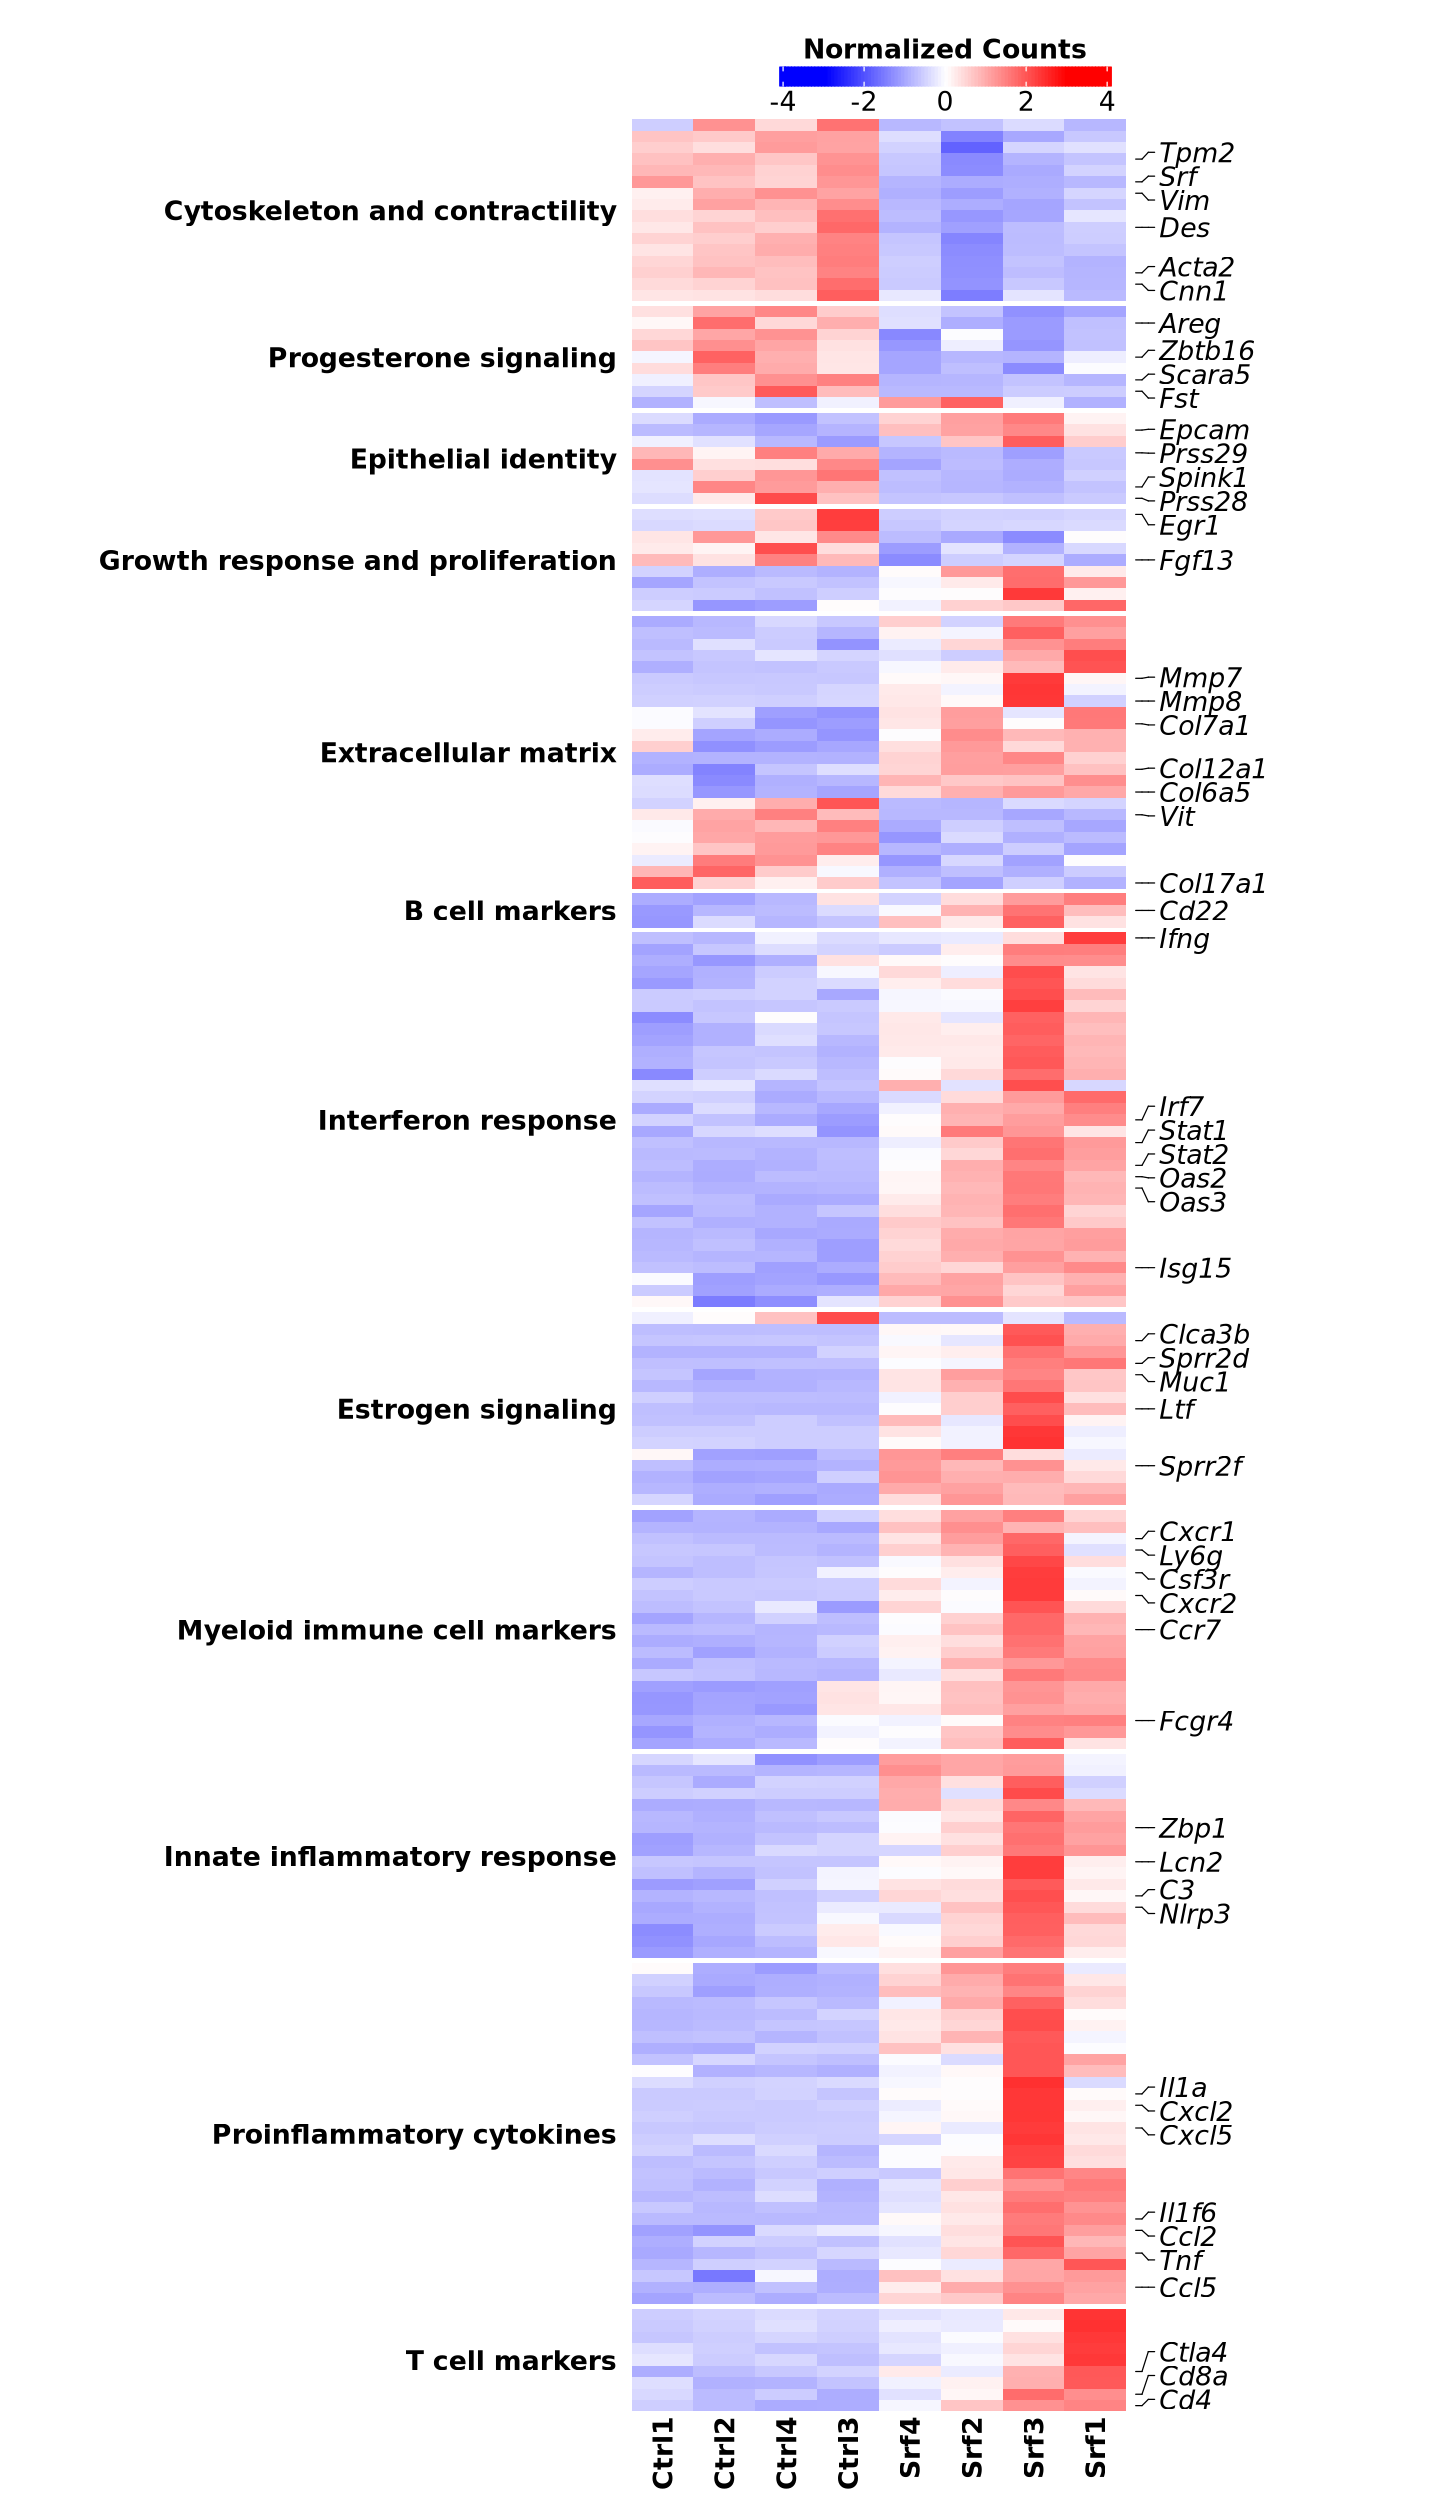

In [106]:
# draw again, now with right side annotation of specific genes
# See https://jokergoo.github.io/ComplexHeatmap-reference/book/heatmap-annotations.html#mark-annotation
# Also got some help from chatGPT to modify the code

saved <- options(repr.plot.width = 12, repr.plot.height = 21) # Make the plots bigger from here on out, save old options

set.seed(123)

# Generate heatmap colors
myBreaks <- seq(-3, 3, length.out = 100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

# Define rows to mark
rows_to_mark <- c("Il1f6", "Cxcl2", "Cxcl5", "Il1a", "Ccl5", "Ccl2", "Tnf",  # List genes to mark (from row names list); here proinflammatory cytokines
                  "Oas3", "Oas2", "Ifng", "Isg15", "Stat1", "Stat2", "Irf7", # interferon response
                  "Lcn2", "C3", "Nlrp3", "Zbp1", # innate inflammatory response
                  "Cxcr1", "Ly6g", "Cxcr2", "Ccr7", "Csf3r", "Fcgr4", # myeloid immune cell markers
                  "Ctla4", "Cd8a", "Cd4", # T cell markers
                  "Cd22", # B cell markers
                  "Sprr2d", "Ltf", "Clca3b", "Sprr2f", "Muc1", # estrogen signaling
                  "Zbtb16", "Scara5", "Fst", "Areg", # progesterone signaling
                  "Srf", "Acta2", "Cnn1", "Tpm2", "Des", "Vim", # cytoskeleton
                  "Mmp7", "Mmp8", "Col6a5", "Col12a1", "Col7a1", "Col17a1", "Vit", # extracellular matrix
                  "Egr1", "Fgf13", #growth response
                  "Epcam", "Prss28", "Spink1", "Prss29" # epithelial identity
                  )       
mark_indices <- match(rows_to_mark, rownames(heat))  # Get row indices

# Add row annotations using anno_mark
RowAnn <- rowAnnotation(
  mark = anno_mark(
    at = mark_indices,                 # Row indices to mark
    labels = rows_to_mark,             # Labels for the marked rows
    labels_gp = gpar(fontsize = 16, fontface = "italic"),   # Font size for labels
    link_gp = gpar(lwd = 1, col = "black") # Line properties
  )
)

# Set heatmap parameters
hmap <- Heatmap(
  heat,
  name = "Normalized Counts",
  col = colorRamp2(myBreaks, myCol),
  heatmap_width = unit(20, "cm"),
  heatmap_height = unit(50, "cm"),
  column_names_gp = gpar(fontsize = 16, fontface = "bold"),
  heatmap_legend_param = list(
    color_bar = "continuous",
    legend_direction = "horizontal",
    legend_width = unit(7, "cm"),
    title_position = "topcenter",
    title_gp = gpar(fontsize = 16, fontface = "bold"),
    labels_gp = gpar(fontsize = 16)
  ),
  
    # Keep column order instead of clustering
  column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
  
    # Split heatmap rows by annotation
  split = df$Annotation,
  
    # Row annotation configurations
  cluster_rows = TRUE,
  show_row_dend = FALSE,
  row_title_side = "left",
  row_title_gp = gpar(fontsize = 16, fontface = "bold"),
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 5.5),
  row_names_rot = 0,
  row_title_rot = 0,
  # Column annotation configurations
  cluster_columns = FALSE,
  show_column_dend = FALSE,
  column_title = "",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = 15, fontface = "bold"),
  column_title_rot = 0,
  show_column_names = TRUE,
  # Dendrogram configurations: rows
  clustering_distance_rows = "euclidean",
  clustering_method_rows = "ward.D2",
  row_dend_width = unit(10, "mm")
)

# Draw heatmap with row annotations
draw(hmap + RowAnn, heatmap_legend_side = "top")

options(saved) # restore old settings


Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


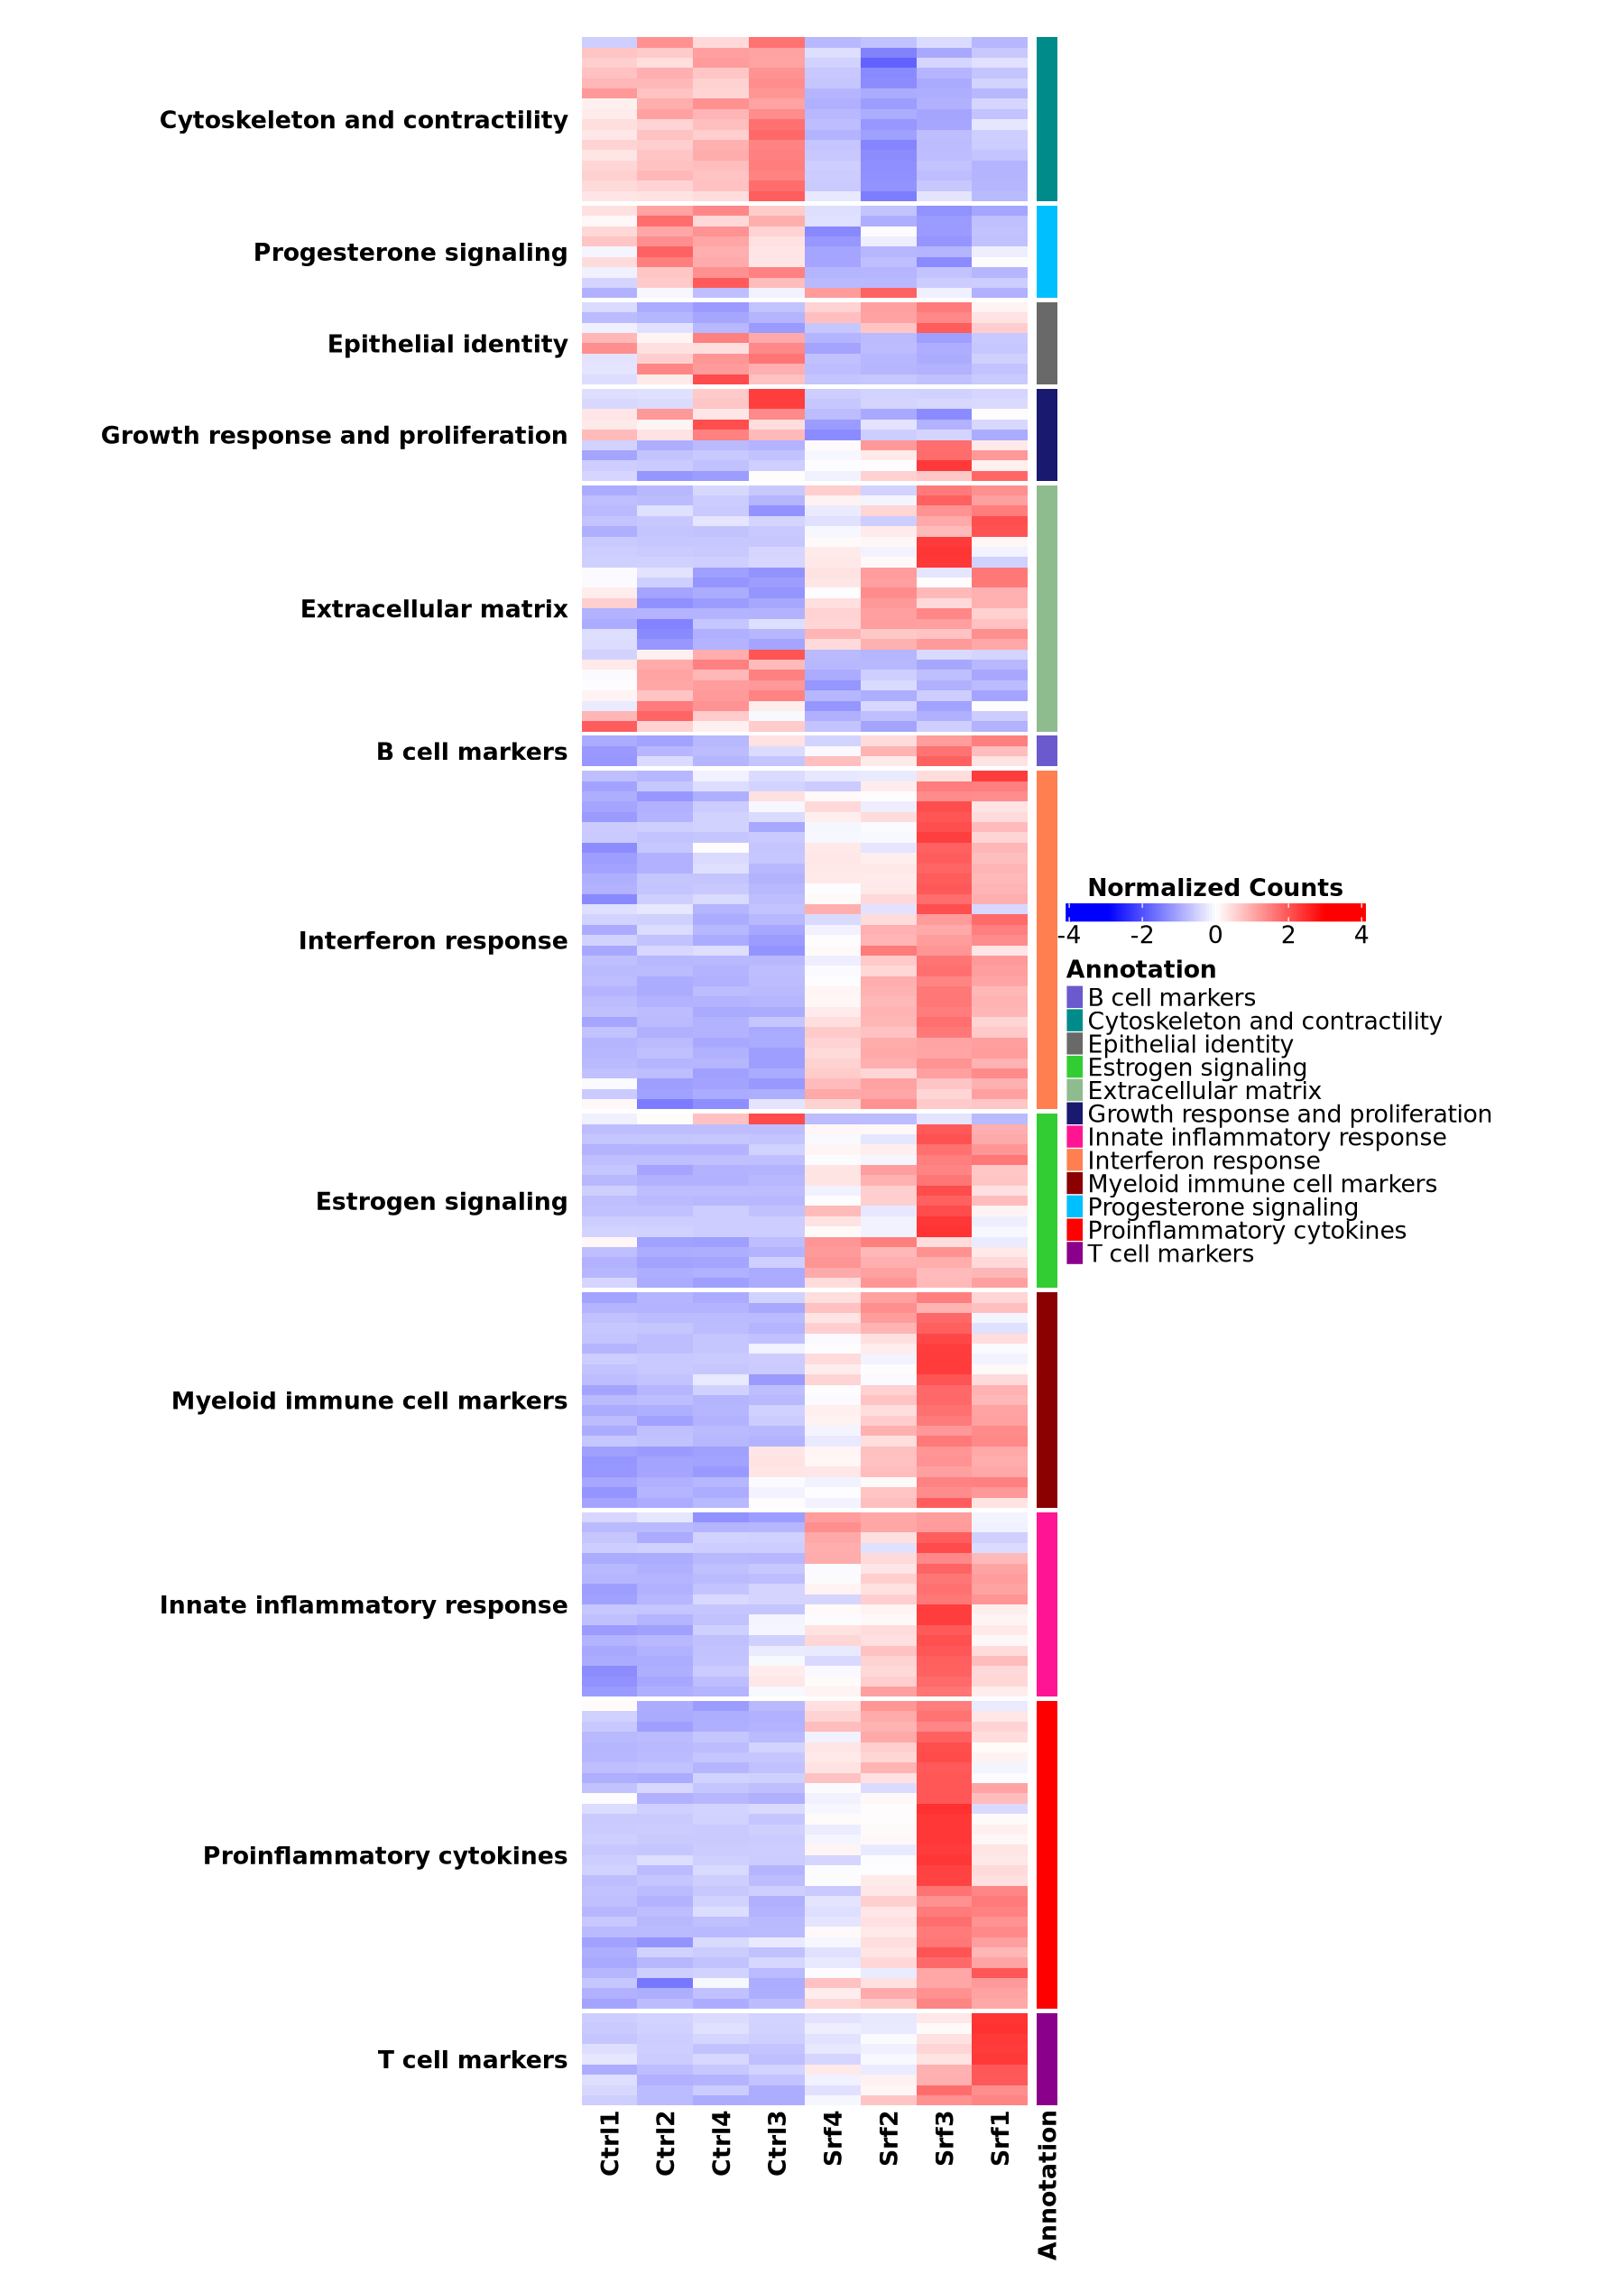

In [108]:
# draw again, now with right side annotation of specific genes
# See https://jokergoo.github.io/ComplexHeatmap-reference/book/heatmap-annotations.html#mark-annotation
# Also got some help from chatGPT to modify the code

saved <- options(repr.plot.width = 15, repr.plot.height = 21) # Make the plots bigger from here on out, save old options

set.seed(123)

# Generate heatmap colors
myBreaks <- seq(-3, 3, length.out = 100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

RowAnn <- data.frame(df$Annotation)
  colnames(RowAnn) <- c("Annotation")
  colours <- list("Annotation"=c("Proinflammatory cytokines"="red","Interferon response"="coral", "Innate inflammatory response"="deeppink", "Myeloid immune cell markers"="darkred", "T cell markers"="darkmagenta", "B cell markers"="slateblue", "Estrogen signaling"="limegreen", "Progesterone signaling"="deepskyblue", "Cytoskeleton and contractility"="darkcyan", "Extracellular matrix"="darkseagreen", "Growth response and proliferation"="midnightblue", "Epithelial identity"="dimgrey"))
  RowAnn <- HeatmapAnnotation(df=RowAnn, 
                              col=colours,
                              annotation_name_gp = gpar(fontsize = 16, fontface = "bold"),
                              which="row",
                              annotation_legend_param = list(
                                                title_gp = gpar(fontsize = 16, fontface = "bold"), 
                                                labels_gp = gpar(fontsize = 16)))

# Set heatmap parameters
hmap <- Heatmap(
  heat,
  name = "Normalized Counts",
  col = colorRamp2(myBreaks, myCol),
  heatmap_width = unit(20, "cm"),
  heatmap_height = unit(50, "cm"),
  column_names_gp = gpar(fontsize = 16, fontface = "bold"),
  heatmap_legend_param = list(
    color_bar = "continuous",
    legend_direction = "horizontal",
    legend_width = unit(7, "cm"),
    title_position = "topcenter",
    title_gp = gpar(fontsize = 16, fontface = "bold"),
    labels_gp = gpar(fontsize = 16)
  ),
  
    # Keep column order instead of clustering
  column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
  
    # Split heatmap rows by annotation
  split = df$Annotation,
  
    # Row annotation configurations
  cluster_rows = TRUE,
  show_row_dend = FALSE,
  row_title_side = "left",
  row_title_gp = gpar(fontsize = 16, fontface = "bold"),
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 5.5),
  row_names_rot = 0,
  row_title_rot = 0,
  # Column annotation configurations
  cluster_columns = FALSE,
  show_column_dend = FALSE,
  column_title = "",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = 15, fontface = "bold"),
  column_title_rot = 0,
  show_column_names = TRUE,
  # Dendrogram configurations: rows
  clustering_distance_rows = "euclidean",
  clustering_method_rows = "ward.D2",
  row_dend_width = unit(10, "mm")
)

# Draw heatmap with row annotations
draw(hmap + RowAnn, heatmap_legend_side = "right", annotation_legend_side="right")

options(saved) # restore old settings


Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


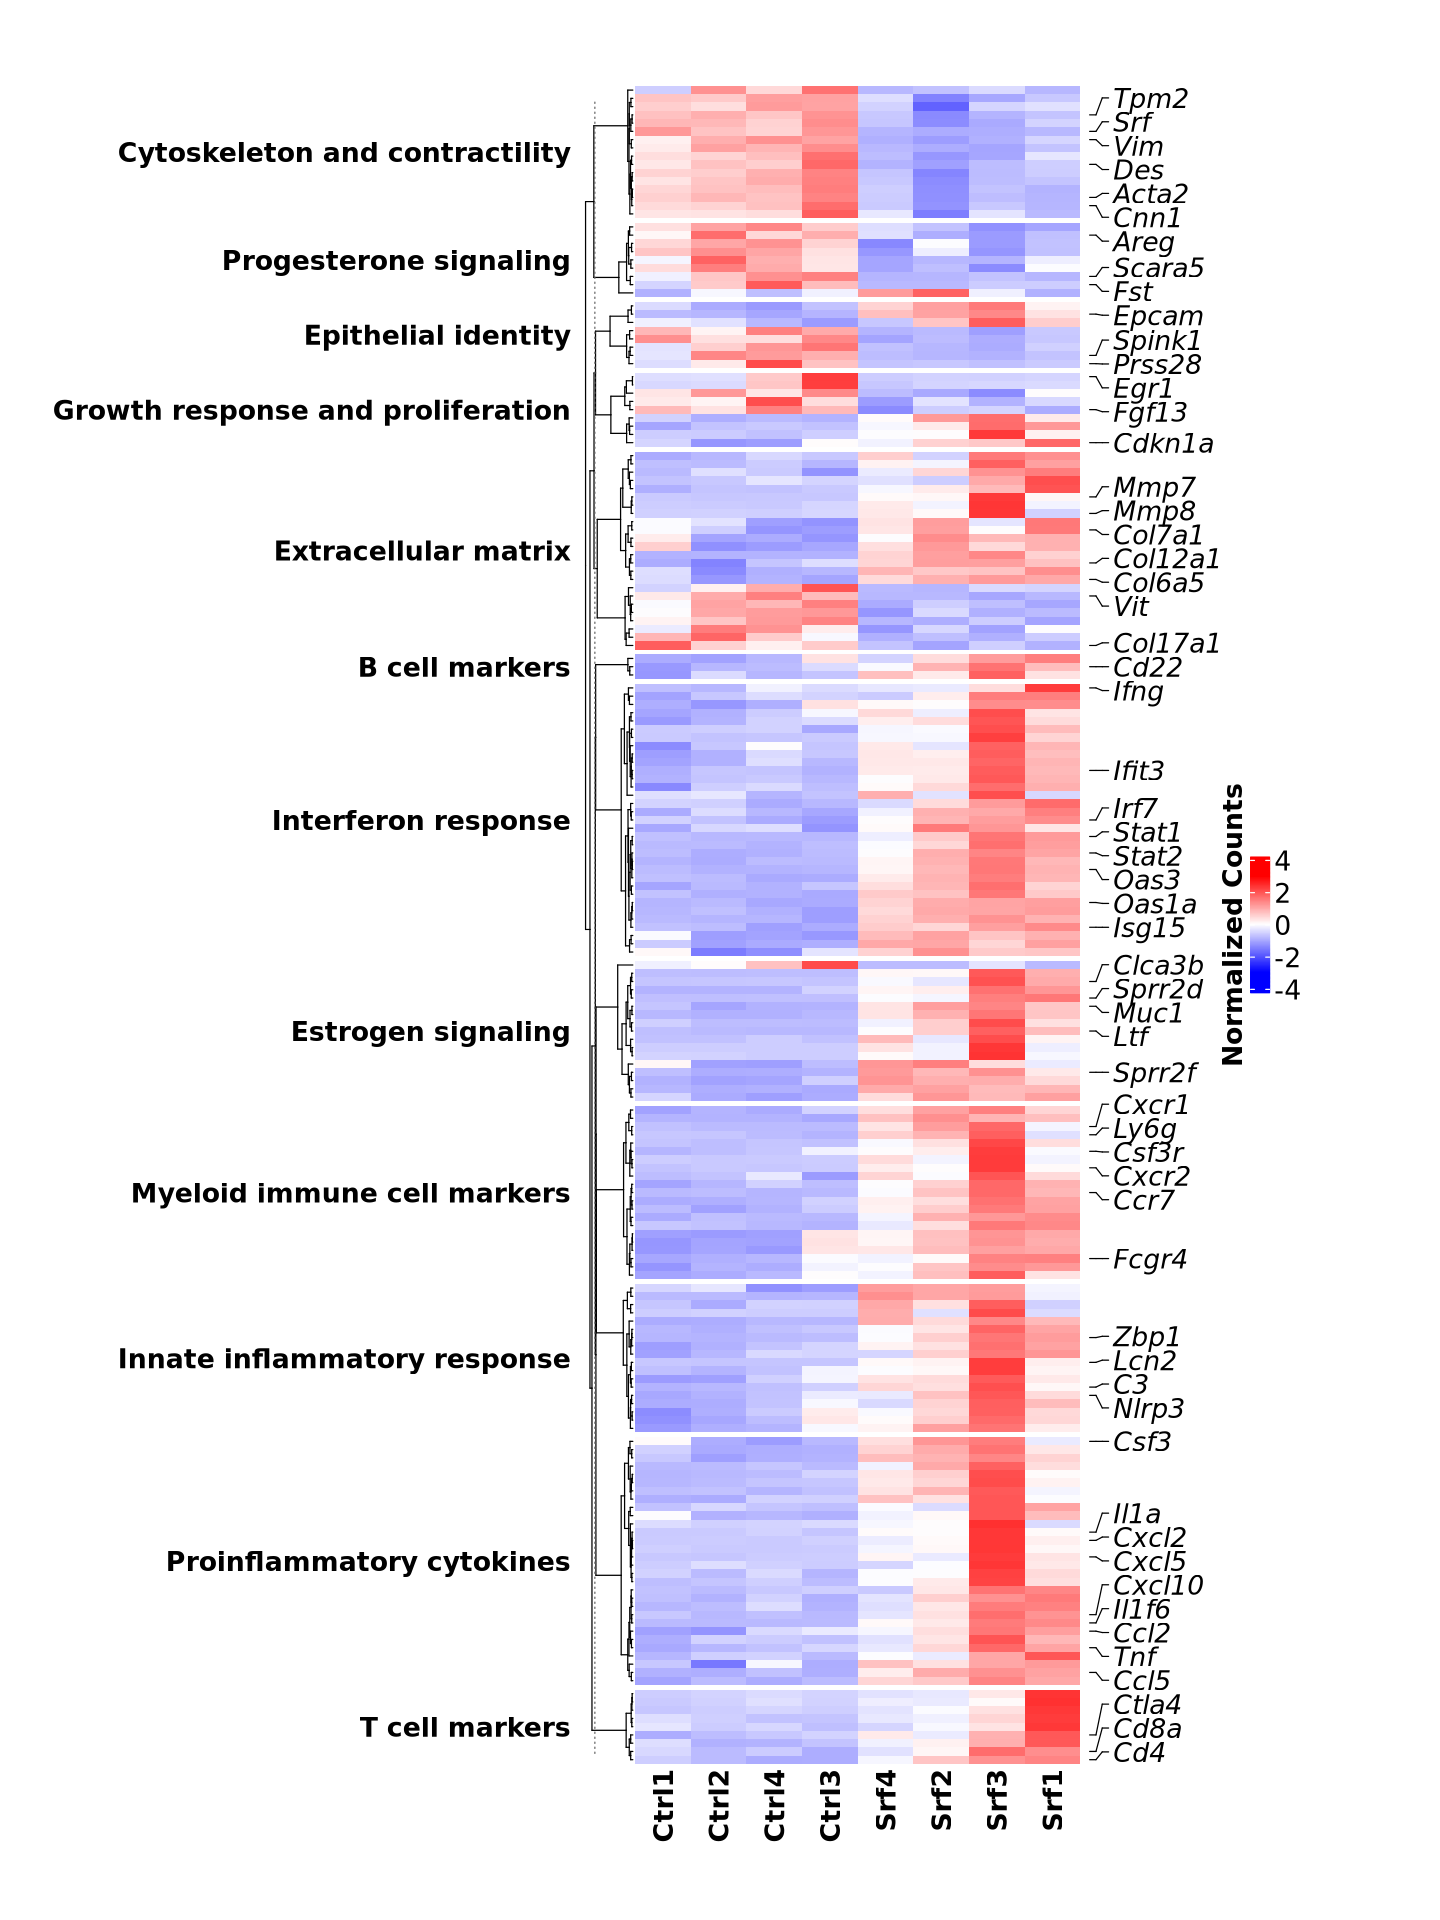

In [110]:
# draw again, now with right side annotation of specific genes, move legend, modify gene selections
# See https://jokergoo.github.io/ComplexHeatmap-reference/book/heatmap-annotations.html#mark-annotation
# Also got some help from chatGPT to modify the code

saved <- options(repr.plot.width = 12, repr.plot.height = 16) # Make the plots bigger from here on out, save old options

set.seed(123)

# Generate heatmap colors
myBreaks <- seq(-3, 3, length.out = 100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

# Define rows to mark
rows_to_mark <- c("Il1f6", "Cxcl2", "Cxcl5", "Il1a", "Ccl5", "Ccl2", "Tnf", "Csf3", "Cxcl10",  # List genes to mark (from row names list); here proinflammatory cytokines
                  "Oas3", "Ifng", "Isg15", "Ifit3", "Oas1a", "Stat1", "Stat2", "Irf7", # interferon response
                  "Lcn2", "C3", "Nlrp3", "Zbp1", # innate inflammatory response
                  "Cxcr1", "Ly6g", "Cxcr2", "Ccr7", "Csf3r", "Fcgr4", # myeloid immune cell markers
                  "Ctla4", "Cd8a", "Cd4", # T cell markers
                  "Cd22", # B cell markers
                  "Sprr2d", "Ltf", "Clca3b", "Sprr2f", "Muc1", # estrogen signaling
                  "Scara5", "Fst", "Areg", # progesterone signaling
                  "Srf", "Acta2", "Cnn1", "Tpm2", "Des", "Vim", # cytoskeleton
                  "Mmp7", "Mmp8", "Col6a5", "Col12a1", "Col7a1", "Col17a1", "Vit", # extracellular matrix
                  "Egr1", "Fgf13", "Cdkn1a", #growth response
                  "Epcam", "Prss28", "Spink1" # epithelial identity
                  )       
mark_indices <- match(rows_to_mark, rownames(heat))  # Get row indices

# Add row annotations using anno_mark
RowAnn <- rowAnnotation(
  mark = anno_mark(
    at = mark_indices,                 # Row indices to mark
    labels = rows_to_mark,             # Labels for the marked rows
    labels_gp = gpar(fontsize = 16, fontface = "italic"),   # Font size for labels
    link_gp = gpar(lwd = 1, col = "black") # Line properties
  )
)

# Set heatmap parameters
hmap <- Heatmap(
  heat,
  name = "Normalized Counts",
  col = colorRamp2(myBreaks, myCol),
  heatmap_width = unit(20, "cm"),
  heatmap_height = unit(37, "cm"),
  column_names_gp = gpar(fontsize = 16, fontface = "bold"),
  heatmap_legend_param = list(
    color_bar = "continuous",
    legend_direction = "vertical",
    legend_width = unit(7, "cm"),
    title_position = "leftcenter-rot",
    title_gp = gpar(fontsize = 16, fontface = "bold"),
    labels_gp = gpar(fontsize = 16)
  ),
  
    # Keep column order instead of clustering
  column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
  
    # Split heatmap rows by annotation
  split = df$Annotation,
  
    # Row annotation configurations
  cluster_rows = TRUE,
  show_row_dend = TRUE,
  row_title_side = "left",
  row_title_gp = gpar(fontsize = 16, fontface = "bold"),
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 5.5),
  row_names_rot = 0,
  row_title_rot = 0,
  # Column annotation configurations
  cluster_columns = FALSE,
  show_column_dend = FALSE,
  column_title = "",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = 15, fontface = "bold"),
  column_title_rot = 0,
  show_column_names = TRUE,
  # Dendrogram configurations: rows
  clustering_distance_rows = "euclidean",
  clustering_method_rows = "ward.D2",
  row_dend_width = unit(10, "mm")
)

# Draw heatmap with row annotations
draw(hmap + RowAnn, heatmap_legend_side = "right")

options(saved) # restore old settings


In [113]:
# Recategorize lymphoid immune markers

# Load and view data
df <- read.csv("250315_Heatmap.csv")
head(df)

,Annotation,Gene,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Proinflammatory cytokines,Il1f6,9.455004,5.321786,1.140681,0.000000,5062.0949,2446.12855,5457.74263,2031.94660
2,Proinflammatory cytokines,Il1f9,39.592831,4.434822,9.125446,0.000000,456.4710,445.32084,1908.38035,324.16269
3,Proinflammatory cytokines,Cxcl2,2.954689,9.756608,26.235658,1.280278,348.1694,290.60844,1291.95661,175.52224
4,Proinflammatory cytokines,Cxcl5,65.003155,24.835001,161.976669,134.429198,1622.9188,728.61180,4857.26897,1288.74434
5,Proinflammatory cytokines,Il1a,76.821911,77.165897,35.361104,133.148920,536.6944,501.76996,2118.54614,528.14799
6,Proinflammatory cytokines,Il24,1.181876,8.869643,0.000000,2.560556,56.9586,10.45354,85.37985,22.13794


In [114]:
# center and scale the rlog counts table (i.e. produce Z-score expression values across the samples, for each gene)
# note: t() will transpose the matrix, and we are specifying that we are only taking the data starting in the 3rd column
# so, here, we are transposing the matrix, center and scaling with scale(), then transposing back
# the reason for this is that scale() by default wants to scale each column vector (samples here), but we want to scale gene-wise

heat <- t(scale(t(df[,3:ncol(df)])))
rownames(heat) <- df$Gene # assign row names as gene names
head(heat) # check our work

,Ctrl1,Ctrl2,Ctrl3,Ctrl4,Srf1,Srf2,Srf3,Srf4
Il1f6,-0.8084016,-0.8101910,-0.8120011,-0.8124950,1.37904526,0.24651109,1.550334,0.06719869
Il1f9,-0.5589277,-0.6136892,-0.6063832,-0.6205968,0.09039428,0.07302700,2.351862,-0.11568678
Cxcl2,-0.6086525,-0.5930507,-0.5552524,-0.6124931,0.18317423,0.05114528,2.347960,-0.21283047
Cxcl5,-0.6413187,-0.6659588,-0.5818326,-0.5987309,0.31434729,-0.23424388,2.298382,0.10935597
Il1a,-0.6149226,-0.6144239,-0.6750336,-0.5332582,0.05181296,0.00117860,2.345225,0.03942218
Il24,-0.7129975,-0.4667646,-0.7508520,-0.6688395,1.07348495,-0.41603368,1.983794,-0.04179200


In [115]:
# Export normalized counts file if desired

write.csv(heat,file="heat_scaled.norm.counts.csv") # keeps the rownames

In [116]:
# If you want to adjust the sample order but keep clustering turned off, change column order in the matrix
new_order <- c(1, 2, 4, 3, 8, 6, 7, 5)
heat <- heat[, new_order]
head(heat) # check our work

,Ctrl1,Ctrl2,Ctrl4,Ctrl3,Srf4,Srf2,Srf3,Srf1
Il1f6,-0.8084016,-0.8101910,-0.8124950,-0.8120011,0.06719869,0.24651109,1.550334,1.37904526
Il1f9,-0.5589277,-0.6136892,-0.6205968,-0.6063832,-0.11568678,0.07302700,2.351862,0.09039428
Cxcl2,-0.6086525,-0.5930507,-0.6124931,-0.5552524,-0.21283047,0.05114528,2.347960,0.18317423
Cxcl5,-0.6413187,-0.6659588,-0.5987309,-0.5818326,0.10935597,-0.23424388,2.298382,0.31434729
Il1a,-0.6149226,-0.6144239,-0.5332582,-0.6750336,0.03942218,0.00117860,2.345225,0.05181296
Il24,-0.7129975,-0.4667646,-0.6688395,-0.7508520,-0.04179200,-0.41603368,1.983794,1.07348495


Warning message in order(as.numeric(gsub("column", "", colnames(heat)))):
“NAs introduced by coercion”


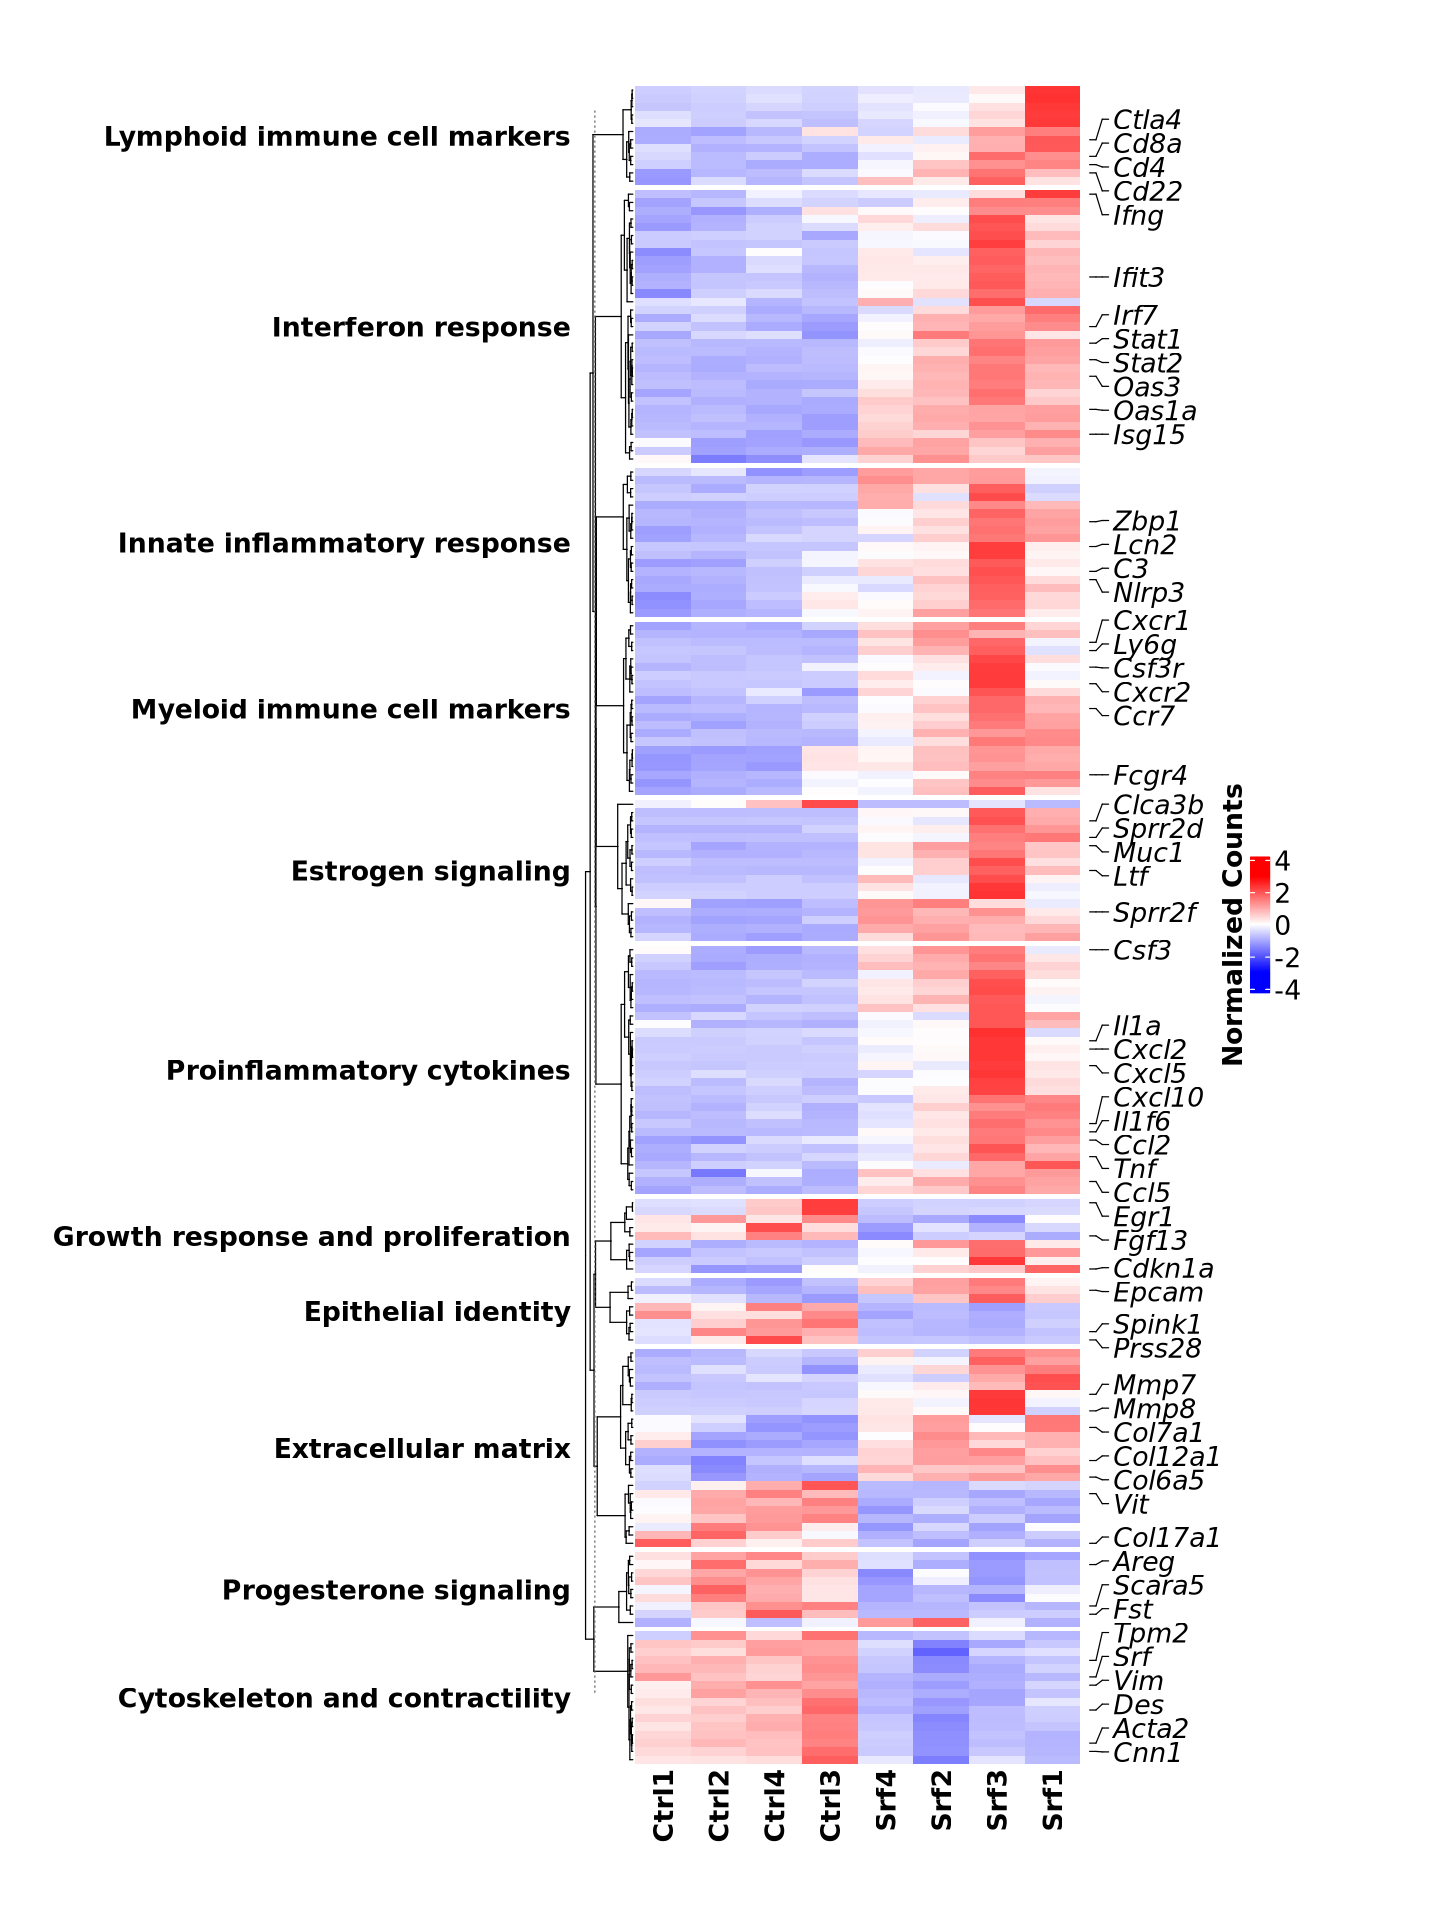

In [117]:
# draw again, now with right side annotation of specific genes, move legend, modify gene selections
# See https://jokergoo.github.io/ComplexHeatmap-reference/book/heatmap-annotations.html#mark-annotation
# Also got some help from chatGPT to modify the code

saved <- options(repr.plot.width = 12, repr.plot.height = 16) # Make the plots bigger from here on out, save old options

set.seed(123)

# Generate heatmap colors
myBreaks <- seq(-3, 3, length.out = 100)
myCol <- colorRampPalette(c("blue", "white", "red"))(100)

# Define rows to mark
rows_to_mark <- c("Il1f6", "Cxcl2", "Cxcl5", "Il1a", "Ccl5", "Ccl2", "Tnf", "Csf3", "Cxcl10",  # List genes to mark (from row names list); here proinflammatory cytokines
                  "Oas3", "Ifng", "Isg15", "Ifit3", "Oas1a", "Stat1", "Stat2", "Irf7", # interferon response
                  "Lcn2", "C3", "Nlrp3", "Zbp1", # innate inflammatory response
                  "Cxcr1", "Ly6g", "Cxcr2", "Ccr7", "Csf3r", "Fcgr4", # myeloid immune cell markers
                  "Ctla4", "Cd8a", "Cd4", # T cell markers
                  "Cd22", # B cell markers
                  "Sprr2d", "Ltf", "Clca3b", "Sprr2f", "Muc1", # estrogen signaling
                  "Scara5", "Fst", "Areg", # progesterone signaling
                  "Srf", "Acta2", "Cnn1", "Tpm2", "Des", "Vim", # cytoskeleton
                  "Mmp7", "Mmp8", "Col6a5", "Col12a1", "Col7a1", "Col17a1", "Vit", # extracellular matrix
                  "Egr1", "Fgf13", "Cdkn1a", #growth response
                  "Epcam", "Prss28", "Spink1" # epithelial identity
                  )       
mark_indices <- match(rows_to_mark, rownames(heat))  # Get row indices

# Add row annotations using anno_mark
RowAnn <- rowAnnotation(
  mark = anno_mark(
    at = mark_indices,                 # Row indices to mark
    labels = rows_to_mark,             # Labels for the marked rows
    labels_gp = gpar(fontsize = 16, fontface = "italic"),   # Font size for labels
    link_gp = gpar(lwd = 1, col = "black") # Line properties
  )
)

# Set heatmap parameters
hmap <- Heatmap(
  heat,
  name = "Normalized Counts",
  col = colorRamp2(myBreaks, myCol),
  heatmap_width = unit(20, "cm"),
  heatmap_height = unit(37, "cm"),
  column_names_gp = gpar(fontsize = 16, fontface = "bold"),
  heatmap_legend_param = list(
    color_bar = "continuous",
    legend_direction = "vertical",
    legend_width = unit(7, "cm"),
    title_position = "leftcenter-rot",
    title_gp = gpar(fontsize = 16, fontface = "bold"),
    labels_gp = gpar(fontsize = 16)
  ),
  
    # Keep column order instead of clustering
  column_order = order(as.numeric(gsub("column", "", colnames(heat)))),
  
    # Split heatmap rows by annotation
  split = df$Annotation,
  
    # Row annotation configurations
  cluster_rows = TRUE,
  show_row_dend = TRUE,
  row_title_side = "left",
  row_title_gp = gpar(fontsize = 16, fontface = "bold"),
  show_row_names = TRUE,
  row_names_side = "right",
  row_names_gp = gpar(fontsize = 5.5),
  row_names_rot = 0,
  row_title_rot = 0,
  # Column annotation configurations
  cluster_columns = FALSE,
  show_column_dend = FALSE,
  column_title = "",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = 15, fontface = "bold"),
  column_title_rot = 0,
  show_column_names = TRUE,
  # Dendrogram configurations: rows
  clustering_distance_rows = "euclidean",
  clustering_method_rows = "ward.D2",
  row_dend_width = unit(10, "mm")
)

# Draw heatmap with row annotations
draw(hmap + RowAnn, heatmap_legend_side = "right")

options(saved) # restore old settings
